# Open Food Facts

This notebook analyzes the Open Food Facts dataset loaded from Kaggle.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("openfoodfacts/world-food-facts")

print("Path to dataset files:", path)

100%|██████████| 109M/109M [00:00<00:00, 153MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/openfoodfacts/world-food-facts/versions/5


In [3]:
import os

files = os.listdir(path)

print("Files in the dataset:")

for file in files:
    print(file)

Files in the dataset:
en.openfoodfacts.org.products.tsv


The code above lists the files present in the downloaded dataset directory, which is specified by the `path` variable.

In [4]:
import pandas as pd
import os

file_path = os.path.join(path, "en.openfoodfacts.org.products.tsv")

# Load only the first 1,000 rows
sample = pd.read_csv(
    file_path,
    sep="\t",
    nrows=1000,
    low_memory=False
)

print("Sample shape:", sample.shape)

Sample shape: (1000, 163)


In [5]:
sample.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,fruits-vegetables-nuts_100g,fruits-vegetables-nuts-estimate_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,3087,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4530,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,14.0,14.0,NaN,NaN
2,4559,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Peanuts,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,16087,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489055731,2017-03-09T10:35:31Z,1489055731,2017-03-09T10:35:31Z,Organic Salted Nut Mix,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,NaN,NaN
4,16094,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489055653,2017-03-09T10:34:13Z,1489055653,2017-03-09T10:34:13Z,Organic Polenta,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Number of columns:", len(sample.columns))

for column in sample.columns:
    print(column)

Number of columns: 163
code
url
creator
created_t
created_datetime
last_modified_t
last_modified_datetime
product_name
generic_name
quantity
packaging
packaging_tags
brands
brands_tags
categories
categories_tags
categories_en
origins
origins_tags
manufacturing_places
manufacturing_places_tags
labels
labels_tags
labels_en
emb_codes
emb_codes_tags
first_packaging_code_geo
cities
cities_tags
purchase_places
stores
countries
countries_tags
countries_en
ingredients_text
allergens
allergens_en
traces
traces_tags
traces_en
serving_size
no_nutriments
additives_n
additives
additives_tags
additives_en
ingredients_from_palm_oil_n
ingredients_from_palm_oil
ingredients_from_palm_oil_tags
ingredients_that_may_be_from_palm_oil_n
ingredients_that_may_be_from_palm_oil
ingredients_that_may_be_from_palm_oil_tags
nutrition_grade_uk
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
states
states_tags
states_en
main_category
main_category_en
image_url
image_small_url
energy_100g
energy-from-fat_100g
fat_100g
s

## Selecting Relevant Features

The original Open Food Facts dataset contains 163 columns, many of which are not directly relevant to the research question.

For this project, I selected an initial subset of features that describe product identity, package information, geographic availability, and key nutritional characteristics. Nutritional values reported per 100 grams are especially useful because they provide a standardized basis for comparing different foods.

Before using these features, the next step is to evaluate how complete they are. Since Open Food Facts is collaboratively collected, some products may have missing nutritional information. Measuring missing values will help determine which features are reliable enough to include in the meal-planning model.

In [7]:
selected_columns = [
    "code",
    "product_name",
    "brands",
    "quantity",
    "categories_en",
    "countries_en",
    "serving_size",
    "energy_100g",
    "proteins_100g",
    "carbohydrates_100g",
    "fat_100g",
    "saturated-fat_100g",
    "fiber_100g",
    "sugars_100g",
    "sodium_100g",
    "calcium_100g",
    "iron_100g",
    "potassium_100g"
]

sample_selected = sample[selected_columns]

sample_selected.head()

,code,product_name,brands,quantity,categories_en,countries_en,serving_size,energy_100g,proteins_100g,carbohydrates_100g,fat_100g,saturated-fat_100g,fiber_100g,sugars_100g,sodium_100g,calcium_100g,iron_100g,potassium_100g
0,3087,Farine de blé noir,Ferme t'y R'nao,1kg,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4530,Banana Chips Sweetened (Whole),NaN,NaN,NaN,United States,28 g (1 ONZ),2243.0,3.57,64.29,28.57,28.57,3.6,14.29,0.000,0.000,0.00129,NaN
2,4559,Peanuts,Torn & Glasser,NaN,NaN,United States,28 g (0.25 cup),1941.0,17.86,60.71,17.86,0.00,7.1,17.86,0.250,0.071,0.00129,NaN
3,16087,Organic Salted Nut Mix,Grizzlies,NaN,NaN,United States,28 g (0.25 cup),2540.0,17.86,17.86,57.14,5.36,7.1,3.57,0.482,0.143,0.00514,NaN
4,16094,Organic Polenta,Bob's Red Mill,NaN,NaN,United States,35 g (0.25 cup),1552.0,8.57,77.14,1.43,NaN,5.7,NaN,NaN,NaN,NaN,NaN


## Assessing Missing Values

A column existing in the dataset does not necessarily mean that every product contains a value for it. Missing data can significantly affect later analysis and optimization.

I will calculate the percentage of missing values for each selected feature. This will help identify which nutritional variables contain enough information to be useful and which may need to be excluded or handled differently.

In [8]:
missing_percentage = (
    sample_selected.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

,0
potassium_100g,94.5
categories_en,85.9
quantity,84.3
calcium_100g,51.8
iron_100g,47.5
saturated-fat_100g,39.0
fiber_100g,36.1
sugars_100g,30.8
sodium_100g,26.1
serving_size,22.8


## Preliminary Findings

The initial missing-value analysis suggests that the Open Food Facts dataset contains sufficient information for the core nutritional requirements of this project.

Energy, protein, carbohydrates, fat, fiber, sugar, and sodium have relatively good coverage compared with several micronutrients. Potassium, in particular, is missing from most of the sampled records, while calcium and iron also contain substantial missing data.

Product quantity and category information are also frequently missing, which may create challenges when the nutrition data is later combined with grocery pricing data.

These findings are preliminary because this analysis uses only the first 1,000 records rather than a random sample of the complete dataset. The next step is therefore to process the full dataset efficiently and determine how many usable U.S. food products are available.

## Processing the Full Dataset

The initial exploration used only the first 1,000 records. To obtain more reliable results, I will now process the complete Open Food Facts dataset.

Because the dataset is large, loading all 163 columns into memory at once would be inefficient. Instead, I will read the dataset in chunks of 50,000 rows, retain only the 18 features relevant to this project, and filter for products associated with the United States.

This approach reduces memory usage while allowing the analysis to use the complete dataset.

In [9]:
us_chunks = []

chunk_size = 50000

for chunk in pd.read_csv(
    file_path,
    sep="\t",
    usecols=selected_columns,
    chunksize=chunk_size,
    low_memory=False
):
    # Keep products whose country information mentions the United States
    us_chunk = chunk[
        chunk["countries_en"]
        .fillna("")
        .str.contains("United States", case=False)
    ]

    us_chunks.append(us_chunk)

# Combine all filtered chunks
us_foods = pd.concat(us_chunks, ignore_index=True)

print("Number of U.S. products:", len(us_foods))
print("Number of columns:", len(us_foods.columns))

Number of U.S. products: 173708
Number of columns: 18


## Data Quality of U.S. Food Products

After processing the complete dataset and filtering for products associated with the United States, 173,708 products remain across the 18 selected features.

The earlier missing-value analysis was based only on the first 1,000 records of the global dataset. To obtain a more representative understanding of data quality for this project, I will now recalculate missing-value percentages using the complete U.S. subset.

This analysis will determine which nutritional features contain sufficient information to be used in the meal-planning and optimization stages.

In [10]:
us_missing = (
    us_foods.isnull().mean() * 100
).sort_values(ascending=False)

us_missing

,0
quantity,98.587860
categories_en,98.236696
potassium_100g,86.048426
calcium_100g,20.780275
iron_100g,20.100398
fiber_100g,19.281783
saturated-fat_100g,16.038409
sugars_100g,7.568448
proteins_100g,1.440924
sodium_100g,1.412140


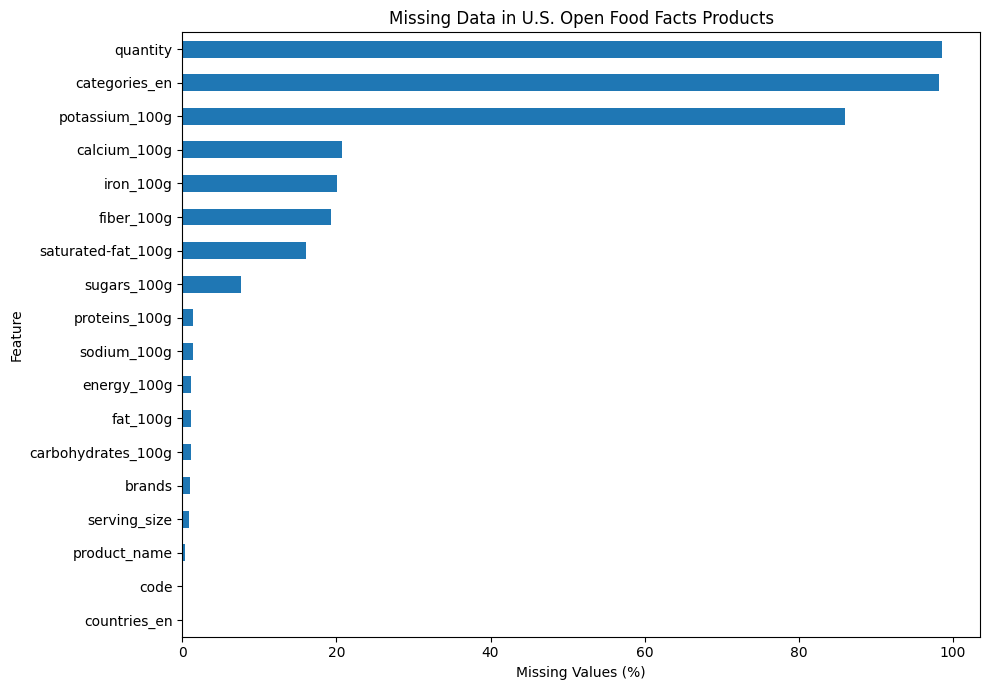

In [11]:
import matplotlib.pyplot as plt

us_missing.sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Data in U.S. Open Food Facts Products")
plt.tight_layout()
plt.show()

In [12]:
missing_report = pd.DataFrame({
    "Missing Count": us_foods.isnull().sum(),
    "Missing Percentage": (us_foods.isnull().mean() * 100).round(2),
    "Available Percentage": (100 - us_foods.isnull().mean() * 100).round(2)
})

missing_report.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage,Available Percentage
quantity,171255,98.59,1.41
categories_en,170645,98.24,1.76
potassium_100g,149473,86.05,13.95
calcium_100g,36097,20.78,79.22
iron_100g,34916,20.10,79.90
fiber_100g,33494,19.28,80.72
saturated-fat_100g,27860,16.04,83.96
sugars_100g,13147,7.57,92.43
proteins_100g,2503,1.44,98.56
sodium_100g,2453,1.41,98.59


## Feature Selection Findings

Analysis of all 173,708 U.S.-associated products showed that the core macronutrient features have excellent coverage. Energy, protein, carbohydrates, fat, and sodium are available for more than 98% of products, while fiber is available for approximately 81%.

These features will form the nutritional foundation of the meal-planning analysis.

Calcium and iron are each available for approximately 80% of products and may be retained as secondary nutritional indicators. Potassium, however, is available for only about 14% of products and will therefore not be used as a mandatory nutritional constraint.

Product quantity and category information are particularly sparse, with less than 2% availability. These fields cannot reliably support the optimization process and may need to be supplemented by the grocery pricing dataset.

Based on these findings, the next stage will focus on constructing a clean dataset containing products with sufficient information for the core nutritional variables.

## Validating Nutritional Values

Having complete data does not necessarily mean that the data is correct. Open Food Facts is a collaboratively maintained real-world dataset, so nutritional values may contain errors, unusual entries, or extreme outliers.

Before removing any records, I will examine the distributions of the core nutritional features using summary statistics and percentiles.

This will help identify potentially impossible or suspicious values, such as negative nutrient quantities or nutrient values exceeding 100 grams per 100 grams of food.

In [13]:
nutrition_columns = [
    "energy_100g",
    "proteins_100g",
    "carbohydrates_100g",
    "fat_100g",
    "fiber_100g",
    "sugars_100g",
    "sodium_100g"
]

In [14]:
nutrition_summary = us_foods[nutrition_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

nutrition_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
energy_100g,171682.0,1133.000441,1007.721774,0.00,0.0,8.0,356.000,1151.000,1674.000,2389.000,3347.00,231199.00
proteins_100g,171205.0,6.807388,8.657946,-800.00,0.0,0.0,0.000,4.000,10.000,23.926,35.56,430.00
carbohydrates_100g,171835.0,33.759916,30.518573,0.00,0.0,0.0,6.670,23.330,60.710,85.000,100.00,2916.67
fat_100g,171713.0,12.404653,17.593570,0.00,0.0,0.0,0.000,4.230,20.000,46.670,93.33,100.00
fiber_100g,140214.0,2.948501,15.098702,-6.70,0.0,0.0,0.000,1.500,3.600,10.700,21.20,5380.00
sugars_100g,160561.0,17.184045,23.663492,-17.86,0.0,0.0,1.670,6.670,26.190,65.850,90.00,3520.00
sodium_100g,171255.0,0.964595,61.663470,0.00,0.0,0.0,0.024,0.243,0.579,1.762,12.80,25320.00


In [15]:
gram_based_columns = [
    "proteins_100g",
    "carbohydrates_100g",
    "fat_100g",
    "fiber_100g",
    "sugars_100g"
]

for column in gram_based_columns:
    negative = (us_foods[column] < 0).sum()
    over_100 = (us_foods[column] > 100).sum()

    print(
        f"{column}: "
        f"{negative} negative values, "
        f"{over_100} values over 100g"
    )

proteins_100g: 3 negative values, 1 values over 100g
carbohydrates_100g: 0 negative values, 6 values over 100g
fat_100g: 0 negative values, 0 values over 100g
fiber_100g: 1 negative values, 3 values over 100g
sugars_100g: 6 negative values, 4 values over 100g


### Initial Observations

The summary statistics reveal several extreme and physically implausible nutritional values. For example, the dataset contains negative protein and fiber values, as well as protein, carbohydrate, fiber, and sugar quantities exceeding 100 grams per 100 grams of product.

The difference between the 99th percentile and maximum values suggests that these extreme observations represent a relatively small number of problematic records rather than the typical food product.

Rather than removing values solely because they are statistically unusual, I will use physically meaningful validation rules wherever possible. For nutrients measured in grams per 100 grams of product, values below 0 or above 100 grams will be treated as invalid.

### Validating Energy and Sodium

The gram-based macronutrients contained only a very small number of physically impossible values. Energy and sodium require separate validation because their reasonable ranges differ from those of the other nutritional features.

Rather than choosing arbitrary cleaning thresholds, I will inspect the products with the most extreme energy and sodium values to determine whether they represent legitimate foods, unit errors, or erroneous records.

In [16]:
us_foods[
    ["product_name", "brands", "energy_100g"]
].sort_values(
    "energy_100g",
    ascending=False
).head(15)

,product_name,brands,energy_100g
173055,"Nusco, Chocolate Spread, Chocolate",Brinkers,231199.0
114382,"Sophia, Italian Drink, Squeezed Lime",Sophia Foods Inc.,94140.0
148334,Salsa Hot Sauce,Mayan Foods S.A. De C.V.,26861.0
45968,Instant Aka Miso Soup,Kikkoman,14644.0
111137,"Flave!, Assorted Fish",Flave!,14347.0
34422,Lemon Cake,Coffee Baking Co,13213.0
78152,"Powder Spice, Classic",Tapatio,11954.0
64803,"Crema Salvadorena, Soft Blend Dairy Spread",Dona Kenia,10966.0
19448,Bread Mix,La Fe,10757.0
170925,"Cretamel, Crunchy Sesame Sticks With Cretan Honey",Cretamel Sa,9623.0


In [17]:
us_foods[
    ["product_name", "brands", "sodium_100g"]
].sort_values(
    "sodium_100g",
    ascending=False
).head(15)

,product_name,brands,sodium_100g
140563,Prickly Syrup,K. Benson Company,25320.000
129976,Chiles Habaneros Rojos,Marin,1400.000
134442,Sauce & Marinade,Got Jerk!,1200.000
102304,Bastoncini Whole Wheat,Clemente Bakery,965.517
50347,"Crispy Fried Onions, White Cheddar",French's,857.143
22892,Original Barbecue Sauce,Billy Sims Barbecue,800.000
56883,String Cheese Snacks,Sargento,708.333
155218,"Sausage Patties, Veggie Sausage Patties",Heritage Health Food,657.143
92184,Swiss Recipe Smoked Almonds & Sea Salt In Dark...,Wegmans,519.048
103553,"Small Potato Dumplings, Potato Gnocchetti",Racconto,448.485


## Cleaning Invalid Nutritional Values

Inspection of the extreme values revealed a small number of physically impossible nutritional records. Examples included negative nutrient quantities, more than 100 grams of a nutrient per 100 grams of product, and energy values far beyond what 100 grams of food could physically provide.

Rather than removing observations simply because they are statistical outliers, physically meaningful validation rules were applied.

For nutrients measured in grams per 100 grams of product, valid values were restricted to the range 0–100 grams. Energy was restricted to 0–4,000 kJ per 100 grams, allowing for highly energy-dense foods while excluding clearly impossible entries.

These rules are intentionally conservative so that unusual but plausible foods are retained while clearly erroneous records are removed.

In [18]:
clean_foods = us_foods.copy()

initial_count = len(clean_foods)

# Nutrients measured in grams per 100g
gram_columns = [
    "proteins_100g",
    "carbohydrates_100g",
    "fat_100g",
    "fiber_100g",
    "sugars_100g",
    "sodium_100g"
]

# Remove physically impossible nutrient values
for column in gram_columns:
    clean_foods = clean_foods[
        clean_foods[column].isna() |
        clean_foods[column].between(0, 100)
    ]

# Remove physically impossible energy values
clean_foods = clean_foods[
    clean_foods["energy_100g"].isna() |
    clean_foods["energy_100g"].between(0, 4000)
]

final_count = len(clean_foods)
removed_count = initial_count - final_count

print("Products before validation:", initial_count)
print("Products after validation:", final_count)
print("Invalid products removed:", removed_count)
print(
    "Percentage removed:",
    round((removed_count / initial_count) * 100, 3),
    "%"
)

Products before validation: 173708
Products after validation: 173599
Invalid products removed: 109
Percentage removed: 0.063 %


### Validation Results

Of the 173,708 U.S.-associated products, only 109 records (0.063%) contained nutritional values that violated the physical validation rules.

After removing these records, 173,599 products remained.

This indicates that the extreme values identified during exploratory analysis were isolated data-quality problems rather than widespread corruption of the dataset. The vast majority of products passed the physical plausibility checks and were retained for further analysis.

# Part 2: Grocery Price Data

The Open Food Facts dataset provides detailed nutritional information but does not contain reliable grocery prices. Since the goal of this project is to construct a nutritious meal plan under a $50 weekly budget, a second dataset is required to provide product prices and package sizes.

The next stage explores a Walmart grocery product dataset to determine whether its products can be combined with the nutrition information from Open Food Facts.

In [19]:
import kagglehub

walmart_path = kagglehub.dataset_download(
    "polartech/walmart-grocery-product-dataset"
)

print("Walmart dataset path:", walmart_path)

100%|██████████| 26.5M/26.5M [00:00<00:00, 99.4MB/s]

Extracting files...


Walmart dataset path: /root/.cache/kagglehub/datasets/polartech/walmart-grocery-product-dataset/versions/1


In [20]:
import os

walmart_files = os.listdir(walmart_path)

print("Files in Walmart dataset:")

for file in walmart_files:
    print(file)

Files in Walmart dataset:
WMT_Grocery_202209.csv


## Inspecting the Walmart Grocery Dataset

The Walmart dataset contains grocery product information that may provide the pricing and package-size data missing from Open Food Facts.

Before attempting to combine the two datasets, I will inspect the Walmart file structure, preview several products, and identify the columns related to product names, brands, prices, package sizes, and categories.

In [21]:
walmart_file = os.path.join(
    walmart_path,
    "WMT_Grocery_202209.csv"
)

walmart_sample = pd.read_csv(
    walmart_file,
    nrows=1000,
    low_memory=False
)

print("Sample shape:", walmart_sample.shape)

Sample shape: (1000, 15)


In [22]:
walmart_sample.head()

,SHIPPING_LOCATION,DEPARTMENT,CATEGORY,SUBCATEGORY,BREADCRUMBS,SKU,PRODUCT_URL,PRODUCT_NAME,BRAND,PRICE_RETAIL,PRICE_CURRENT,PRODUCT_SIZE,PROMOTION,RunDate,tid
0,79936,Deli,"Hummus, Dips, & Salsa",NaN,"Deli/Hummus, Dips, & Salsa",110895339,https://www.walmart.com/ip/Marketside-Roasted-...,"Marketside Roasted Red Pepper Hummus, 10 Oz",Marketside,2.67,2.67,10,NaN,2022-09-11 21:20:04,16163804
1,79936,Deli,"Hummus, Dips, & Salsa",NaN,"Deli/Hummus, Dips, & Salsa",105455228,https://www.walmart.com/ip/Marketside-Roasted-...,"Marketside Roasted Garlic Hummus, 10 Oz",Marketside,2.67,2.67,10,NaN,2022-09-11 21:20:04,16163805
2,79936,Deli,"Hummus, Dips, & Salsa",NaN,"Deli/Hummus, Dips, & Salsa",128642379,https://www.walmart.com/ip/Marketside-Classic-...,"Marketside Classic Hummus, 10 Oz",Marketside,2.67,2.67,10,NaN,2022-09-11 21:20:04,16163806
3,79936,Deli,"Hummus, Dips, & Salsa",NaN,"Deli/Hummus, Dips, & Salsa",366126367,https://www.walmart.com/ip/Marketside-Everythi...,"Marketside Everything Hummus, 10 oz",Marketside,2.67,2.67,10,NaN,2022-09-11 21:20:04,16163807
4,79936,Deli,"Hummus, Dips, & Salsa",NaN,"Deli/Hummus, Dips, & Salsa",160090316,https://www.walmart.com/ip/Price-s-Jalapeno-Di...,"Price's Jalapeno Dip, 12 Oz.",Price's,3.12,3.12,12,NaN,2022-09-11 21:20:04,16163808


In [23]:
print("Number of columns:", len(walmart_sample.columns))

for column in walmart_sample.columns:
    print(column)

Number of columns: 15
SHIPPING_LOCATION
DEPARTMENT
CATEGORY
SUBCATEGORY
BREADCRUMBS
SKU
PRODUCT_URL
PRODUCT_NAME
BRAND
PRICE_RETAIL
PRICE_CURRENT
PRODUCT_SIZE
PROMOTION
RunDate
tid


## Evaluating Grocery Price Data Quality

The initial Walmart records contain the key variables required for the economic component of the project, including product names, brands, current prices, package sizes, categories, and shipping locations.

However, several questions must be answered before the dataset can be combined with Open Food Facts. Products may appear multiple times across shipping locations, package-size units may be embedded in product names rather than explicitly stored, and the Walmart SKU may not correspond to the barcode identifier used by Open Food Facts.

The next step is therefore to examine the size, completeness, and duplication structure of the Walmart dataset before attempting product matching.

In [24]:
walmart = pd.read_csv(
    walmart_file,
    low_memory=False
)

print("Rows:", len(walmart))
print("Columns:", len(walmart.columns))

Rows: 568534
Columns: 15


In [25]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568534 entries, 0 to 568533
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SHIPPING_LOCATION  568534 non-null  int64  
 1   DEPARTMENT         568534 non-null  object 
 2   CATEGORY           568534 non-null  object 
 3   SUBCATEGORY        361324 non-null  object 
 4   BREADCRUMBS        568534 non-null  object 
 5   SKU                568534 non-null  int64  
 6   PRODUCT_URL        568534 non-null  object 
 7   PRODUCT_NAME       568534 non-null  object 
 8   BRAND              568507 non-null  object 
 9   PRICE_RETAIL       568534 non-null  float64
 10  PRICE_CURRENT      568534 non-null  float64
 11  PRODUCT_SIZE       505709 non-null  object 
 12  PROMOTION          0 non-null       float64
 13  RunDate            568534 non-null  object 
 14  tid                568534 non-null  int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 65

In [26]:
walmart.isnull().mean().mul(100).round(2).sort_values(ascending=False)

,0
PROMOTION,100.00
SUBCATEGORY,36.45
PRODUCT_SIZE,11.05
CATEGORY,0.00
BREADCRUMBS,0.00
DEPARTMENT,0.00
SHIPPING_LOCATION,0.00
PRODUCT_URL,0.00
SKU,0.00
PRODUCT_NAME,0.00


In [27]:
print("Total rows:", len(walmart))
print("Unique SKUs:", walmart["SKU"].nunique())
print("Unique product names:", walmart["PRODUCT_NAME"].nunique())
print("Shipping locations:", walmart["SHIPPING_LOCATION"].nunique())

Total rows: 568534
Unique SKUs: 30827
Unique product names: 30688
Shipping locations: 26


In [28]:
walmart[
    ["PRICE_CURRENT", "PRICE_RETAIL", "PRODUCT_SIZE"]
].describe()

,PRICE_CURRENT,PRICE_RETAIL
count,568534.000000,568534.000000
mean,5.079274,5.105377
std,4.727971,4.824906
min,0.160000,0.160000
25%,2.480000,2.480000
50%,3.880000,3.880000
75%,5.980000,5.980000
max,246.870000,246.870000


In [29]:
sku_consistency = walmart.groupby("SKU").agg(
    product_names=("PRODUCT_NAME", "nunique"),
    brands=("BRAND", "nunique"),
    sizes=("PRODUCT_SIZE", "nunique"),
    observations=("SKU", "size")
)

sku_consistency.describe()

,product_names,brands,sizes,observations
count,30827.000000,30827.000000,30827.000000,30827.000000
mean,1.001298,0.999935,0.863075,18.442729
std,0.036889,0.008055,0.343963,20.560524
min,1.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,4.000000
50%,1.000000,1.000000,1.000000,12.000000
75%,1.000000,1.000000,1.000000,25.000000
max,3.000000,1.000000,2.000000,361.000000


In [30]:
print(
    "SKUs with multiple product names:",
    (sku_consistency["product_names"] > 1).sum()
)

print(
    "SKUs with multiple brands:",
    (sku_consistency["brands"] > 1).sum()
)

print(
    "SKUs with multiple sizes:",
    (sku_consistency["sizes"] > 1).sum()
)

SKUs with multiple product names: 39
SKUs with multiple brands: 0
SKUs with multiple sizes: 2


In [31]:
price_by_sku = walmart.groupby("SKU")["PRICE_CURRENT"].agg(
    ["min", "median", "max", "count"]
)

price_by_sku["price_range"] = (
    price_by_sku["max"] - price_by_sku["min"]
)

price_by_sku.describe()

,min,median,max,count,price_range
count,30827.000000,30827.000000,30827.000000,30827.000000,30827.000000
mean,5.374903,5.497680,5.774426,18.442729,0.399523
std,6.030029,6.176122,6.509181,20.560524,1.201479
min,0.160000,0.200000,0.240000,1.000000,0.000000
25%,2.480000,2.480000,2.580000,4.000000,0.000000
50%,3.860000,3.940000,3.980000,12.000000,0.000000
75%,6.120000,6.265000,6.580000,25.000000,0.320000
max,246.870000,246.870000,246.870000,361.000000,53.010000


### Initial Walmart Data Findings

The Walmart dataset contains 568,534 observations representing 30,827 unique SKUs across 26 shipping locations. This indicates that many products are observed repeatedly across different geographic locations rather than representing distinct grocery items.

The variables most important to this project are highly complete. Product names, prices, categories, and SKUs have no missing values, while brand information is almost completely available. Product size is missing for approximately 11% of observations.

Current grocery prices have a median of $3.88, although prices range from $0.16 to $246.87. These extreme values will be investigated before optimization.

Because the same SKU may appear across multiple locations, the next step is to determine whether SKUs consistently represent the same product and how much prices vary geographically. A representative price can then be calculated for each unique grocery product.

### Geographic Price Variation

Prices were compared across repeated observations of each Walmart SKU to determine whether geographic variation would significantly affect the analysis.

The median price range across products was $0.00, while the 75th percentile was only $0.32. This suggests that most products exhibited little or no price variation across the observed locations. A small number of products showed substantially larger differences, with the maximum observed price range reaching $53.01.

To reduce the influence of unusual geographic prices or individual observations, the median current price across all available observations will be used as the representative price for each Walmart SKU.

### SKU Consistency Findings

Walmart SKUs were found to be highly consistent product identifiers. Of the 30,827 unique SKUs, only 39 were associated with multiple product names, none were associated with multiple brands, and only two contained multiple recorded package sizes.

Based on this consistency, SKU will be used to aggregate repeated geographic observations into individual grocery products.

In [32]:
walmart_products = (
    walmart.groupby("SKU")
    .agg(
        product_name=("PRODUCT_NAME", "first"),
        brand=("BRAND", "first"),
        category=("CATEGORY", "first"),
        subcategory=("SUBCATEGORY", "first"),
        product_size=("PRODUCT_SIZE", "first"),
        median_price=("PRICE_CURRENT", "median"),
        observations=("SKU", "size")
    )
    .reset_index()
)

print("Original Walmart observations:", len(walmart))
print("Unique Walmart products:", len(walmart_products))

walmart_products.head()

Original Walmart observations: 568534
Unique Walmart products: 30827


,SKU,product_name,brand,category,subcategory,product_size,median_price,observations
0,879555,Brew Rite Paper Coffee Filter (200 Pack),Brew Rite,Coffee Accessories,Coffee Filters,None,1.98,23
1,882653,Brew Rite Basket Coffee Filter 200 Pack,Brew Rite,Coffee Accessories,Coffee Filters,None,1.98,19
2,1172289,"Marketside Detroit Style Pepperoni Pizza, Medi...",Marketside,Fresh Pizza,Prepared meals & sides,26.17,8.50,30
3,2304246,BUNN 8-12 Cup Premium Home Flat-Bottom Coffee ...,BUNN,Coffee Accessories,Coffee Filters,None,1.96,18
4,7696441,Great Value Buffalo Style Seasoned Boneless Fu...,Great Value,Frozen Meals & Snacks,Shop all,24,8.22,21


## Identifying Edible Grocery Products

Although the Walmart dataset is focused on groceries, it also contains non-food products such as coffee filters and other household or grocery accessories.

Since the objective is to construct a meal plan, only edible food and beverage products should be considered. Before applying a filter, I will examine the available departments and categories to understand how Walmart organizes its products and develop a transparent filtering strategy.

In [33]:
print("Departments:")
print()

for department in sorted(walmart_products["category"].dropna().unique()):
    print(department)

Departments:

Bacon, Hot Dogs, Sausage
Baking Nuts & Seeds
Baking Soda & Starch
Beef Jerky
Beer
Better for you
Beverage Deals
Biscuits, Cookies, Doughs
Breakfast Beverages
Breakfast Breads
Butter & Margarine
Cakes & Cupcakes
Canned & Powdered Milks
Canned goods
Canned vegetables
Cereal & Granola
Cheese
Chips
Chocolate
Coffee Accessories
Coffee Additives
Coffee By Type
Condiments
Cookies & Brownies
Cooking oils & vinegars
Crackers
Cream & Creamers
Cut Fruits & Vegetables
Dairy & Eggs
Deli Meat & Cheese
Donuts, Muffins & Pastries
Drink Mixes
Easy to make
Eggs
Emergency & Institutional food
Energy Drinks
Flours & Meals
Fresh Bakery Breads
Fresh Flowers
Fresh Food
Fresh Herbs
Fresh Pasta
Fresh Pizza
Fresh Soups & Salads
Frozen Breakfast
Frozen Desserts
Frozen Meals & Snacks
Frozen Meat & Seafood
Frozen Pizza, Pasta, & Breads
Frozen Potatoes
Frozen Produce
Fruit Snacks
Game Time Faves
Granola Bars
Great Value Beverages
Grilling
Gum
Gummy & chewy candy
Halloween candy
Hard candy & lollipops


In [34]:
walmart_products = (
    walmart.groupby("SKU")
    .agg(
        product_name=("PRODUCT_NAME", "first"),
        brand=("BRAND", "first"),
        department=("DEPARTMENT", "first"),
        category=("CATEGORY", "first"),
        subcategory=("SUBCATEGORY", "first"),
        product_size=("PRODUCT_SIZE", "first"),
        median_price=("PRICE_CURRENT", "median"),
        observations=("SKU", "size")
    )
    .reset_index()
)

In [35]:
print("Unique departments:", walmart_products["department"].nunique())

print(
    walmart_products["department"]
    .value_counts()
)

Unique departments: 14
department
Pantry                7730
Frozen                3251
Beverages             2692
Snacks                2523
Dairy & Eggs          2430
Alcohol               2161
Deli                  1936
Breakfast & Cereal    1785
Candy                 1775
Meat & Seafood        1504
Baking                1423
Bakery & Bread        1168
Coffee                 245
Fresh Produce          204
Name: count, dtype: int64


In [36]:
print("Unique categories:", walmart_products["category"].nunique())

print(
    walmart_products["category"]
    .value_counts()
    .head(50)
)

Unique categories: 109
category
Condiments                       1941
Canned goods                     1379
Fresh Food                       1314
Herbs, spices & seasonings       1209
Frozen Desserts                  1178
Breakfast Beverages              1009
Wine                              940
Frozen Meals & Snacks             880
International foods               855
Bacon, Hot Dogs, Sausage          808
Chips                             793
Cheese                            761
Pasta & pizza                     756
Juices                            701
Spirits                           684
Chocolate                         648
Soup                              586
Yogurt                            559
Healthy Snacks                    557
Beer                              537
Milk                              514
Gummy & chewy candy               483
Easy to make                      482
Frozen Pizza, Pasta, & Breads     433
Crackers                          410
Rice, grains & dri

## Filtering for Meal-Relevant Grocery Products

The Walmart dataset contains 14 departments, most of which represent edible grocery products. However, the dataset also includes alcohol and a small number of non-food grocery accessories.

For the initial product-matching experiment, alcohol products will be excluded because they are not relevant to the nutritional meal-planning objective. Obvious non-food categories such as coffee accessories will also be removed.

This is an initial filtering step rather than a final food-classification system. Additional irrelevant products can be identified after the nutrition and pricing datasets are successfully matched.

In [37]:
walmart_foods = walmart_products[
    (walmart_products["department"] != "Alcohol") &
    (walmart_products["category"] != "Coffee Accessories")
].copy()

print("Walmart products before filtering:", len(walmart_products))
print("Meal-relevant products after filtering:", len(walmart_foods))
print("Products removed:", len(walmart_products) - len(walmart_foods))

Walmart products before filtering: 30827
Meal-relevant products after filtering: 28454
Products removed: 2373


In [38]:
test_products = walmart_foods[
    walmart_foods["department"].isin([
        "Dairy & Eggs",
        "Breakfast & Cereal",
        "Pantry",
        "Meat & Seafood",
        "Fresh Produce"
    ])
].sample(20, random_state=42)

test_products[
    ["SKU", "product_name", "brand", "department", "median_price"]
]

,SKU,product_name,brand,department,median_price
21285,332671185,"McCafe Baked Apple Pie Coffee, Keurig Single S...",McCafé,Breakfast & Cereal,14.92
25835,654265544,"Blue Diamond Wasabi & Soy Sauce, 1.5oz-10 count",Blue Diamond,Pantry,9.98
9078,23591411,"Thai Kitchen Pad Thai Rice Noodle Cart, 9.77 oz",Thai Kitchen,Pantry,4.38
6983,15754582,"Heinz Tomato Ketchup Value Size, 64 oz Bottle",Heinz,Meat & Seafood,5.98
15284,113739204,"G Hughes Gluten-Free, Sugar-Free Balsamic Vina...",G Hughes,Pantry,3.28
7841,20553436,"Grace Coconut Water With Pulp, 10.5 fl oz",La Fe,Pantry,1.68
4224,10534249,"Heiner's Old-Fashioned Enriched Bread, 20 oz",Heiner's,Breakfast & Cereal,2.37
10942,37341968,Betty Crocker Homestyle Creamy Butter Potatoes...,Betty Crocker,Pantry,1.08
13119,47183746,Crescent Halal Bonless Skinless Chicken Thighs...,Crescent,Meat & Seafood,10.71
12138,44390993,"The Greek Gods Honey Greek Yogurt, 32 Oz",The Greek Gods,Dairy & Eggs,5.18


In [39]:
import re
import pandas as pd

def normalize_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove punctuation
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [40]:
walmart_foods["name_normalized"] = (
    walmart_foods["product_name"].apply(normalize_text)
)

walmart_foods["brand_normalized"] = (
    walmart_foods["brand"].apply(normalize_text)
)

clean_foods["name_normalized"] = (
    clean_foods["product_name"].apply(normalize_text)
)

clean_foods["brand_normalized"] = (
    clean_foods["brands"].apply(normalize_text)
)

First experiment:

In [41]:
exact_matches = walmart_foods.merge(
    clean_foods,
    left_on=["name_normalized", "brand_normalized"],
    right_on=["name_normalized", "brand_normalized"],
    how="inner",
    suffixes=("_walmart", "_off")
)

print("Exact matches found:", len(exact_matches))

print(
    "Unique Walmart products matched:",
    exact_matches["SKU"].nunique()
)

print(
    "Percentage of Walmart foods exactly matched:",
    round(
        exact_matches["SKU"].nunique()
        / walmart_foods["SKU"].nunique()
        * 100,
        2
    ),
    "%"
)

Exact matches found: 1
Unique Walmart products matched: 1
Percentage of Walmart foods exactly matched: 0.0 %


### Initial Product-Matching Result

An initial exact-match attempt using normalized product names and brands produced only one matching Walmart product.

This extremely low match rate suggests that the two datasets use substantially different product-name conventions. Walmart product names frequently include brand names, package quantities, units, and other descriptive information that may not appear in Open Food Facts.

Rather than concluding that the datasets are incompatible, the next experiment will apply stronger text normalization before considering fuzzy matching.

In [42]:
def clean_product_name(name, brand=""):
    name = normalize_text(name)
    brand = normalize_text(brand)

    # Remove brand from product name
    if brand:
        name = name.replace(brand, " ")

    # Remove common package measurements
    name = re.sub(
        r"\b\d+(\.\d+)?\s*(oz|ounce|ounces|lb|lbs|pound|pounds|"
        r"fl oz|g|kg|ml|l|ct|count|pack)\b",
        " ",
        name
    )

    # Remove standalone numbers
    name = re.sub(r"\b\d+(\.\d+)?\b", " ", name)

    # Clean whitespace again
    name = re.sub(r"\s+", " ", name).strip()

    return name

In [43]:
walmart_foods["match_name"] = walmart_foods.apply(
    lambda row: clean_product_name(
        row["product_name"],
        row["brand"]
    ),
    axis=1
)

clean_foods["match_name"] = clean_foods.apply(
    lambda row: clean_product_name(
        row["product_name"],
        row["brands"]
    ),
    axis=1
)

In [44]:
walmart_foods[
    ["product_name", "brand", "match_name"]
].sample(20, random_state=42)

,product_name,brand,match_name
22074,Farmland Skinless Maple Breakfast Sausage Link...,Farmland,skinless maple breakfast sausage links
22341,Diamond Bakery Creems Pineapple,Diamond Bakery,creems pineapple
11272,"Airheads Candy Variety Gravity Feed Box, Indiv...",AirHeads,candy variety gravity feed box individually wr...
29467,Freshness Guaranteed Fully Cooked Traditional ...,Freshness Guaranteed,fully cooked traditional pulled rotisserie chi...
9843,Fever-Tree Refreshingly Light Indian Tonic Wat...,Fever-Tree,refreshingly light indian tonic water 4pk bottles
26644,"Marketside Butcher Lamb Shoulder Chop, 0.5-1.0...",Marketside,butcher lamb shoulder chop fresh
22280,"Hershey, Miniatures Chocolate Assortment Candy...",Hershey's,hershey miniatures chocolate assortment candy ...
15082,"Great Value Organic Ground Cardamom, 1.8 oz",Great Value,organic ground cardamom
27313,"Humm Kombucha Strawberry Lemonade, (4 Pack of 1)",Humm Kombucha,strawberry lemonade of
22983,Country Hearth English Muffin Bread,Country Hearth,english muffin bread


In [45]:
better_matches = walmart_foods.merge(
    clean_foods,
    left_on=["match_name", "brand_normalized"],
    right_on=["match_name", "brand_normalized"],
    how="inner",
    suffixes=("_walmart", "_off")
)

matched_skus = better_matches["SKU"].nunique()

print("Unique Walmart products matched:", matched_skus)

print(
    "Match percentage:",
    round(
        matched_skus /
        walmart_foods["SKU"].nunique() * 100,
        2
    ),
    "%"
)

Unique Walmart products matched: 1131
Match percentage: 3.97 %


# Deep Learning for Product Matching

Exact text matching successfully identified some products shared between Walmart and Open Food Facts, but differences in naming conventions prevented many potentially equivalent products from matching.

For example, two datasets may describe the same product using different word orders, abbreviations, package information, or marketing terminology.

To address this problem, I will experiment with semantic product matching using a pretrained Sentence Transformer model. Instead of comparing product names only as strings, the model converts product descriptions into numerical embeddings that represent their semantic meaning.

Cosine similarity can then be used to measure how closely two product descriptions are related.

To reduce false matches, products will first be restricted to candidates from the same normalized brand. Semantic similarity will then be used to rank products within that candidate set.

In [46]:
!pip install -q sentence-transformers

In [47]:
from sentence_transformers import SentenceTransformer

In [48]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [49]:
example_products = [
    "Great Value Old Fashioned Oats 42 oz",
    "Old Fashioned Oats",
    "Chocolate Ice Cream"
]

example_embeddings = model.encode(example_products)

print("Number of products:", len(example_embeddings))
print("Embedding dimensions:", len(example_embeddings[0]))

Number of products: 3
Embedding dimensions: 384


In [50]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(example_embeddings)

print(
    "Oats vs Oats:",
    round(similarities[0][1], 3)
)

print(
    "Oats vs Chocolate Ice Cream:",
    round(similarities[0][2], 3)
)

Oats vs Oats: 0.773
Oats vs Chocolate Ice Cream: 0.322


### Semantic Similarity Sanity Check

As an initial test, the Sentence Transformer compared three simple product descriptions.

"Great Value Old Fashioned Oats 42 oz" and "Old Fashioned Oats" produced a cosine similarity of 0.773, while the unrelated comparison between oats and chocolate ice cream produced a much lower similarity of 0.322.

This demonstrates that the pretrained embedding model captures semantic similarity beyond exact string matching. However, the result also shows that a valid match does not necessarily produce a similarity score above 0.90. Therefore, matching thresholds should be determined empirically using real product pairs rather than chosen arbitrarily.

In [51]:
walmart_foods["semantic_text"] = (
    walmart_foods["brand"].fillna("").astype(str)
    + " "
    + walmart_foods["product_name"].fillna("").astype(str)
).str.strip()

clean_foods["semantic_text"] = (
    clean_foods["brands"].fillna("").astype(str)
    + " "
    + clean_foods["product_name"].fillna("").astype(str)
).str.strip()

In [52]:
walmart_brands = set(
    walmart_foods.loc[
        walmart_foods["brand_normalized"] != "",
        "brand_normalized"
    ]
)

off_brands = set(
    clean_foods.loc[
        clean_foods["brand_normalized"] != "",
        "brand_normalized"
    ]
)

shared_brands = walmart_brands.intersection(off_brands)

print("Walmart brands:", len(walmart_brands))
print("Open Food Facts brands:", len(off_brands))
print("Shared normalized brands:", len(shared_brands))

Walmart brands: 3660
Open Food Facts brands: 26946
Shared normalized brands: 1821


### Brand Overlap Between Datasets

Before performing semantic product matching, I compared normalized brand names between the Walmart and Open Food Facts datasets.

Walmart contained 3,660 unique normalized brands, while Open Food Facts contained 26,946. A total of 1,821 brands appeared in both datasets, meaning approximately 49.8% of Walmart brands have a corresponding brand in Open Food Facts.

This substantial overlap makes brand-restricted semantic matching feasible. Instead of comparing each Walmart product against the entire Open Food Facts database, candidate products can first be restricted to the same brand and then ranked using deep-learning-based semantic similarity.

In [53]:
eligible_walmart = walmart_foods[
    walmart_foods["brand_normalized"].isin(shared_brands)
].copy()

print("Walmart products with a shared brand:", len(eligible_walmart))

test_walmart = eligible_walmart.sample(
    n=100,
    random_state=42
)

print("Products selected for experiment:", len(test_walmart))

Walmart products with a shared brand: 20376
Products selected for experiment: 100


In [54]:
semantic_results = []

for _, walmart_row in test_walmart.iterrows():

    brand = walmart_row["brand_normalized"]

    # Only compare against Open Food Facts products
    # belonging to the same brand
    candidates = clean_foods[
        clean_foods["brand_normalized"] == brand
    ].copy()

    if candidates.empty:
        continue

    # Convert Walmart product description to an embedding
    walmart_embedding = model.encode(
        [walmart_row["semantic_text"]],
        normalize_embeddings=True
    )

    # Convert candidate OFF descriptions to embeddings
    candidate_embeddings = model.encode(
        candidates["semantic_text"].tolist(),
        normalize_embeddings=True
    )

    # Compare semantic similarity
    scores = cosine_similarity(
        walmart_embedding,
        candidate_embeddings
    )[0]

    best_position = scores.argmax()
    best_score = scores[best_position]

    best_candidate = candidates.iloc[best_position]

    semantic_results.append({
        "SKU": walmart_row["SKU"],
        "walmart_product": walmart_row["product_name"],
        "walmart_brand": walmart_row["brand"],
        "walmart_price": walmart_row["median_price"],

        "off_product": best_candidate["product_name"],
        "off_brand": best_candidate["brands"],

        "similarity": best_score,

        "energy_100g": best_candidate["energy_100g"],
        "protein_100g": best_candidate["proteins_100g"],
        "carbs_100g": best_candidate["carbohydrates_100g"],
        "fat_100g": best_candidate["fat_100g"],
        "fiber_100g": best_candidate["fiber_100g"],
        "sodium_100g": best_candidate["sodium_100g"]
    })

semantic_matches = pd.DataFrame(semantic_results)

print("Semantic matches generated:", len(semantic_matches))

Semantic matches generated: 100


In [55]:
semantic_matches[
    [
        "walmart_product",
        "off_product",
        "similarity"
    ]
].sort_values(
    "similarity",
    ascending=False
).head(30)

,walmart_product,off_product,similarity
98,"Le Sueur Very Young Small Sweet Peas, 8.5 oz",Very Young Small Sweet Peas,0.936657
78,LAFFY TAFFY Stretchy & Tangy Banana Candy 1.5 ...,"Stretchy & Tangy Candy, Banana",0.920397
36,"Red Baron Deep Dish Singles Pepperoni Pizza, 1...",Singles Deep Dish Pepperoni Pizzas,0.912240
10,"Great Value Colby Cheese, 16 oz",Colby Cheese,0.906252
4,"Barilla Protein+ Elbows Pasta, 14.5 Oz","Protein Plus, Multigrain Pasta, Elbows",0.890626
47,"McCormick Black Pepper - Pure Ground, 6 oz",Pure Ground Black Pepper,0.889415
9,"Joan of Arc Spicy Chili Beans, 30 oz, Can","Chili Beans, Spicy",0.880364
2,"DiGiorno Four Cheese, Rising Crust Pizza, 28.2...",four cheese pizza,0.879037
39,"Great Value Raspberry Fruit Spread, 17.25 oz","Fruit Spread, Raspberry",0.873355
40,"Celestial Seasonings Sleepytime Herbal Tea, 40...",Herbal Tea,0.872862


In [56]:
semantic_matches["similarity"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

,similarity
count,100.000000
mean,0.736778
std,0.113780
min,0.446872
10%,0.572410
25%,0.653493
50%,0.741768
75%,0.833813
90%,0.872808
95%,0.889475


In [57]:
for threshold in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]:
    count = (semantic_matches["similarity"] >= threshold).sum()

    print(
        f"Similarity >= {threshold:.2f}: "
        f"{count} / {len(semantic_matches)}"
    )

Similarity >= 0.50: 97 / 100
Similarity >= 0.60: 85 / 100
Similarity >= 0.70: 65 / 100
Similarity >= 0.75: 49 / 100
Similarity >= 0.80: 33 / 100
Similarity >= 0.85: 22 / 100
Similarity >= 0.90: 4 / 100


In [58]:
semantic_matches[
    [
        "walmart_product",
        "off_product",
        "similarity"
    ]
].sort_values(
    "similarity",
    ascending=True
).head(30)

,walmart_product,off_product,similarity
62,"Price's Jalapeno Dip, 12 Oz.",Lite Pimiento Real Cheese Sandwich Spread,0.446872
7,"Prego Garden Harvest Mushroom & Green Pepper, ...",Homestyle Alfredo Sauce,0.480425
32,Iberia Ib Con. Coconut Milk 11.6oz,100% Extra Virgin Olive Oil,0.498297
71,"Lay's Baked Barbecue Potato Crisps, 6.25 oz Bag",Chips,0.503559
52,"Enlightened Mini Keto Chocolate Cheesecakes, 2...","Low Fat Ice Cream Bars, Peanut Butter",0.522836
12,"Progresso Vegetable Classics Soup, Vegetable B...",hearty chicken & rotini,0.525601
64,"Nathan's Auntie Anne's Famous Pretzel Dogs, 20 Oz",Beef Franks,0.553942
35,Bolthouse Farms Peach Parfait Breakfast Smooth...,vanilla chai tea,0.566375
75,"KeVita Pineapple Peach Master Brew Kombucha, 1...",Tea And Honey Iced Green Tea Mango Pineapple ...,0.567683
76,Oscar Mayer Natural Meat & Cheese Snack Plate ...,Maple Bacon,0.570637


## Evaluating Semantic Matching Accuracy

The lowest-scoring semantic matches demonstrate an important limitation of nearest-neighbor matching: the model always returns the most similar available candidate, even when no true matching product exists in Open Food Facts.

Furthermore, similarity score alone does not perfectly indicate product identity. Some apparently correct matches receive moderate similarity scores, while products with similar categories but different flavors or formulations can receive relatively high scores.

To evaluate the matching system objectively, the 100-product test sample will be manually labeled. Each proposed match will be classified as either a valid product match or an invalid/uncertain match. These labels will provide a small ground-truth evaluation set for comparing matching strategies and selecting an appropriate confidence rule.

In [59]:
review_matches = semantic_matches[
    [
        "walmart_product",
        "off_product",
        "similarity"
    ]
].sort_values(
    "similarity",
    ascending=False
).copy()

review_matches["correct_match"] = ""

review_matches

,walmart_product,off_product,similarity,correct_match
98,"Le Sueur Very Young Small Sweet Peas, 8.5 oz",Very Young Small Sweet Peas,0.936657,
78,LAFFY TAFFY Stretchy & Tangy Banana Candy 1.5 ...,"Stretchy & Tangy Candy, Banana",0.920397,
36,"Red Baron Deep Dish Singles Pepperoni Pizza, 1...",Singles Deep Dish Pepperoni Pizzas,0.912240,
10,"Great Value Colby Cheese, 16 oz",Colby Cheese,0.906252,
4,"Barilla Protein+ Elbows Pasta, 14.5 Oz","Protein Plus, Multigrain Pasta, Elbows",0.890626,
...,...,...,...,...
52,"Enlightened Mini Keto Chocolate Cheesecakes, 2...","Low Fat Ice Cream Bars, Peanut Butter",0.522836,
71,"Lay's Baked Barbecue Potato Crisps, 6.25 oz Bag",Chips,0.503559,
32,Iberia Ib Con. Coconut Milk 11.6oz,100% Extra Virgin Olive Oil,0.498297,
7,"Prego Garden Harvest Mushroom & Green Pepper, ...",Homestyle Alfredo Sauce,0.480425,


In [60]:
!pip install -q rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 19.1 MB/s eta 0:00:00


In [61]:
from rapidfuzz.fuzz import token_set_ratio

def lexical_similarity(row):
    return token_set_ratio(
        normalize_text(row["walmart_product"]),
        normalize_text(row["off_product"])
    ) / 100

semantic_matches["lexical_similarity"] = semantic_matches.apply(
    lexical_similarity,
    axis=1
)

In [62]:
comparison = semantic_matches[
    [
        "walmart_product",
        "off_product",
        "similarity",
        "lexical_similarity"
    ]
].sort_values(
    "similarity",
    ascending=False
)

comparison.head(30)

,walmart_product,off_product,similarity,lexical_similarity
98,"Le Sueur Very Young Small Sweet Peas, 8.5 oz",Very Young Small Sweet Peas,0.936657,1.000000
78,LAFFY TAFFY Stretchy & Tangy Banana Candy 1.5 ...,"Stretchy & Tangy Candy, Banana",0.920397,1.000000
36,"Red Baron Deep Dish Singles Pepperoni Pizza, 1...",Singles Deep Dish Pepperoni Pizzas,0.912240,0.885246
10,"Great Value Colby Cheese, 16 oz",Colby Cheese,0.906252,1.000000
4,"Barilla Protein+ Elbows Pasta, 14.5 Oz","Protein Plus, Multigrain Pasta, Elbows",0.890626,0.714286
47,"McCormick Black Pepper - Pure Ground, 6 oz",Pure Ground Black Pepper,0.889415,1.000000
9,"Joan of Arc Spicy Chili Beans, 30 oz, Can","Chili Beans, Spicy",0.880364,1.000000
2,"DiGiorno Four Cheese, Rising Crust Pizza, 28.2...",four cheese pizza,0.879037,1.000000
39,"Great Value Raspberry Fruit Spread, 17.25 oz","Fruit Spread, Raspberry",0.873355,1.000000
40,"Celestial Seasonings Sleepytime Herbal Tea, 40...",Herbal Tea,0.872862,1.000000


In [63]:
semantic_matches["similarity"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

,similarity
count,100.000000
mean,0.736778
std,0.113780
min,0.446872
10%,0.572410
25%,0.653493
50%,0.741768
75%,0.833813
90%,0.872808
95%,0.889475


## Creating a Human-Labeled Evaluation Set

Similarity scores alone cannot establish whether two records represent the same grocery product. To objectively evaluate the matching system, I will manually review the 100-product test sample.

Each proposed match will receive a binary label:

- **1 — Match:** the records clearly represent the same product.
- **0 — No Match:** the products differ or there is insufficient evidence to confidently treat them as identical.

When uncertain, the conservative choice will be 0 because transferring incorrect nutritional information is more harmful to the meal-planning analysis than failing to match a product.

These manually reviewed examples will serve as a small ground-truth dataset for evaluating the semantic and lexical matching methods.

In [64]:
review_df = semantic_matches[
    [
        "walmart_product",
        "off_product",
        "similarity",
        "lexical_similarity"
    ]
].sort_values(
    "similarity",
    ascending=False
).reset_index(drop=True)

review_df["correct_match"] = pd.NA

print("Products ready for review:", len(review_df))

Products ready for review: 100


In [65]:
review_df.iloc[0:20]

,walmart_product,off_product,similarity,lexical_similarity,correct_match
0,"Le Sueur Very Young Small Sweet Peas, 8.5 oz",Very Young Small Sweet Peas,0.936657,1.000000,<NA>
1,LAFFY TAFFY Stretchy & Tangy Banana Candy 1.5 ...,"Stretchy & Tangy Candy, Banana",0.920397,1.000000,<NA>
2,"Red Baron Deep Dish Singles Pepperoni Pizza, 1...",Singles Deep Dish Pepperoni Pizzas,0.912240,0.885246,<NA>
3,"Great Value Colby Cheese, 16 oz",Colby Cheese,0.906252,1.000000,<NA>
4,"Barilla Protein+ Elbows Pasta, 14.5 Oz","Protein Plus, Multigrain Pasta, Elbows",0.890626,0.714286,<NA>
5,"McCormick Black Pepper - Pure Ground, 6 oz",Pure Ground Black Pepper,0.889415,1.000000,<NA>
6,"Joan of Arc Spicy Chili Beans, 30 oz, Can","Chili Beans, Spicy",0.880364,1.000000,<NA>
7,"DiGiorno Four Cheese, Rising Crust Pizza, 28.2...",four cheese pizza,0.879037,1.000000,<NA>
8,"Great Value Raspberry Fruit Spread, 17.25 oz","Fruit Spread, Raspberry",0.873355,1.000000,<NA>
9,"Celestial Seasonings Sleepytime Herbal Tea, 40...",Herbal Tea,0.872862,1.000000,<NA>


In [67]:
labels_0_20 = [
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    0, 1, 1, 1, 1,
    1, 1, 1, 1, 1
]

In [68]:
review_df.loc[0:19, "correct_match"] = labels_0_20

In [69]:
review_df.iloc[20:40]

,walmart_product,off_product,similarity,lexical_similarity,correct_match
20,"Great Value Savory Steak Sauce, 10 Oz",Steak Sauce,0.854891,1.000000,<NA>
21,"Chobani Low Fat Cookie Dough Greek Yogurt, 4.5 Oz",Low Fat Greek Yogurt,0.850894,1.000000,<NA>
22,Kool-Aid Jammers Tropical Punch Artificially F...,"Jammers Drink, Tropical Punch",0.841526,1.000000,<NA>
23,Good Seasons Zesty Italian Dressing & Recipe S...,Italian Salad Dressing & Recipe Mix,0.838295,0.900000,<NA>
24,"YoCrunch Low Fat Vanilla with Snickers Yogurt,...","Snickers, Lowfat Yogurt, Vanilla",0.834973,0.867925,<NA>
25,"Silk Vanilla Almond Milk, Half Gallon","Almondmilk, Vanilla",0.833426,0.666667,<NA>
26,"Herr's Salt & Vinegar Potato Chips, 8.5 oz",Lightly Salted Potato Chips,0.827698,0.615385,<NA>
27,"Great Value Original Applesauce, 24 oz Jar",Original Applesauce,0.825497,1.000000,<NA>
28,"Tony Chacheres, Seasoning, Cajun, No Salt, 5 oz",Salt Free Seasoning,0.824236,0.848485,<NA>
29,"SWEDISH FISH Assorted Mini Soft & Chewy Candy,...",Soft & Chewy Candy,0.823509,1.000000,<NA>


In [71]:
labels_20_40 = [
    1,  # 20 Great Value steak sauce
    0,  # 21 Chobani Cookie Dough -> generic Low Fat Greek Yogurt
    1,  # 22 Kool-Aid Tropical Punch
    1,  # 23 Good Seasons Italian dressing mix
    1,  # 24 YoCrunch Snickers vanilla yogurt
    1,  # 25 Silk Vanilla Almond Milk
    0,  # 26 Salt & Vinegar chips -> Lightly Salted chips
    1,  # 27 Great Value Original Applesauce
    1,  # 28 Tony Chachere's no-salt Cajun seasoning
    1,  # 29 Swedish Fish soft & chewy candy
    1,  # 30 Badia seasoned salt
    1,  # 31 Hidden Valley Original Ranch
    0,  # 32 Sunflower-oil sardines -> olive-oil sardines
    1,  # 33 Tai Pei Pork Egg Rolls
    0,  # 34 Chocolate Fudge cake -> German Chocolate cake
    1,  # 35 S. Rosen's Brioche Buns
    1,  # 36 Naked Mighty Mango
    0,  # 37 Classic spaghetti -> Thin spaghetti
    0,  # 38 Honey Butter biscuit mix -> Cheddar Bay mix
    0   # 39 Macadamia nuts -> Mixed nuts
]

review_df.loc[20:39, "correct_match"] = labels_20_40

In [72]:
review_df.iloc[0:40]

,walmart_product,off_product,similarity,lexical_similarity,correct_match
0,"Le Sueur Very Young Small Sweet Peas, 8.5 oz",Very Young Small Sweet Peas,0.936657,1.000000,1
1,LAFFY TAFFY Stretchy & Tangy Banana Candy 1.5 ...,"Stretchy & Tangy Candy, Banana",0.920397,1.000000,1
2,"Red Baron Deep Dish Singles Pepperoni Pizza, 1...",Singles Deep Dish Pepperoni Pizzas,0.912240,0.885246,1
3,"Great Value Colby Cheese, 16 oz",Colby Cheese,0.906252,1.000000,1
4,"Barilla Protein+ Elbows Pasta, 14.5 Oz","Protein Plus, Multigrain Pasta, Elbows",0.890626,0.714286,1
5,"McCormick Black Pepper - Pure Ground, 6 oz",Pure Ground Black Pepper,0.889415,1.000000,1
6,"Joan of Arc Spicy Chili Beans, 30 oz, Can","Chili Beans, Spicy",0.880364,1.000000,1
7,"DiGiorno Four Cheese, Rising Crust Pizza, 28.2...",four cheese pizza,0.879037,1.000000,1
8,"Great Value Raspberry Fruit Spread, 17.25 oz","Fruit Spread, Raspberry",0.873355,1.000000,1
9,"Celestial Seasonings Sleepytime Herbal Tea, 40...",Herbal Tea,0.872862,1.000000,1


In [73]:
print(
    "Correct matches among first 40:",
    review_df.loc[0:39, "correct_match"].sum()
)

print(
    "Incorrect/uncertain among first 40:",
    40 - review_df.loc[0:39, "correct_match"].sum()
)

Correct matches among first 40: 32
Incorrect/uncertain among first 40: 8


## Selecting an Automated Matching Rule

Manually reviewing every product pair would defeat the purpose of building an automated matching system. Instead, the 40 manually reviewed product pairs will be used as a small validation set.

The objective is not to maximize the number of matched products. Incorrect matches would transfer the wrong nutritional information to Walmart products and could corrupt the final meal-plan optimization.

Therefore, the matching system will prioritize precision over coverage. Different combinations of semantic and lexical similarity thresholds will be evaluated against the manually reviewed examples to identify a conservative automated acceptance rule.

In [74]:
validation = review_df.iloc[:40].copy()

validation["correct_match"] = (
    validation["correct_match"].astype(int)
)

results = []

semantic_thresholds = [0.75, 0.80, 0.82, 0.84, 0.85, 0.86, 0.88]
lexical_thresholds = [0.60, 0.70, 0.80, 0.90]

for sem_threshold in semantic_thresholds:
    for lex_threshold in lexical_thresholds:

        accepted = validation[
            (validation["similarity"] >= sem_threshold) &
            (validation["lexical_similarity"] >= lex_threshold)
        ]

        if len(accepted) == 0:
            continue

        correct = accepted["correct_match"].sum()
        precision = correct / len(accepted)

        results.append({
            "semantic_threshold": sem_threshold,
            "lexical_threshold": lex_threshold,
            "accepted": len(accepted),
            "correct": correct,
            "precision": round(precision, 3)
        })

threshold_results = pd.DataFrame(results)

threshold_results.sort_values(
    ["precision", "accepted"],
    ascending=[False, False]
).head(20)

,semantic_threshold,lexical_threshold,accepted,correct,precision
24,0.88,0.6,7,7,1.000
25,0.88,0.7,7,7,1.000
26,0.88,0.8,6,6,1.000
27,0.88,0.9,5,5,1.000
20,0.86,0.6,17,16,0.941
21,0.86,0.7,17,16,0.941
22,0.86,0.8,16,15,0.938
5,0.80,0.7,28,26,0.929
23,0.86,0.9,14,13,0.929
6,0.80,0.8,27,25,0.926


### Automated Matching Rule

The manually reviewed validation sample was used to compare combinations of semantic and lexical similarity thresholds.

A highly restrictive semantic threshold of 0.88 achieved 100% precision, but this result was based on only seven accepted examples and discarded most potential matches.

A more balanced rule requiring a semantic similarity of at least 0.80 and a lexical similarity of at least 0.70 accepted 28 of the 40 reviewed candidates, of which 26 were judged correct. This corresponds to an estimated precision of approximately 92.9% on the small validation sample.

Because the final meal-planning problem requires a sufficiently diverse set of foods while incorrect nutrition matches remain undesirable, this rule was selected as the initial automated matching criterion. The reported precision should be interpreted as a validation estimate rather than the true accuracy of the complete matched dataset.

## Scaling Semantic Matching

The initial semantic-matching experiment repeatedly generated embeddings for Open Food Facts products whenever they were compared with a Walmart product. This is inefficient when many Walmart products belong to the same brands.

To scale the process, embeddings for eligible Open Food Facts products will be generated once and reused. Walmart products will continue to be compared only against Open Food Facts products belonging to the same normalized brand.

This significantly reduces unnecessary computation while preserving the brand-restricted matching strategy.

In [75]:
# Keep only OFF products belonging to brands shared with Walmart
off_candidates = clean_foods[
    clean_foods["brand_normalized"].isin(shared_brands)
].copy()

off_candidates = off_candidates.reset_index(drop=True)

print("Open Food Facts candidate products:", len(off_candidates))

Open Food Facts candidate products: 25128


In [76]:
off_embeddings = model.encode(
    off_candidates["semantic_text"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embeddings created:", len(off_embeddings))

Batches:   0%|          | 0/99 [00:00<?, ?it/s]

Embeddings created: 25128


In [77]:
import numpy as np

brand_to_indices = {}

for brand, group in off_candidates.groupby("brand_normalized"):
    brand_to_indices[brand] = group.index.to_numpy()

print("Brand candidate groups:", len(brand_to_indices))

Brand candidate groups: 1821


In [78]:
eligible_walmart = eligible_walmart.reset_index(drop=True)

walmart_embeddings = model.encode(
    eligible_walmart["semantic_text"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Walmart embeddings created:", len(walmart_embeddings))

Batches:   0%|          | 0/80 [00:00<?, ?it/s]

Walmart embeddings created: 20376


In [79]:
full_semantic_results = []

for i, walmart_row in eligible_walmart.iterrows():

    brand = walmart_row["brand_normalized"]

    candidate_indices = brand_to_indices.get(brand)

    if candidate_indices is None or len(candidate_indices) == 0:
        continue

    candidate_embeddings = off_embeddings[candidate_indices]

    # Embeddings are normalized, so dot product = cosine similarity
    scores = candidate_embeddings @ walmart_embeddings[i]

    best_local_position = np.argmax(scores)
    best_score = scores[best_local_position]

    best_off_index = candidate_indices[best_local_position]
    best_candidate = off_candidates.iloc[best_off_index]

    lexical_score = token_set_ratio(
        normalize_text(walmart_row["product_name"]),
        normalize_text(best_candidate["product_name"])
    ) / 100

    full_semantic_results.append({
        "SKU": walmart_row["SKU"],
        "walmart_product": walmart_row["product_name"],
        "brand": walmart_row["brand"],
        "category": walmart_row["category"],
        "product_size": walmart_row["product_size"],
        "median_price": walmart_row["median_price"],

        "off_product": best_candidate["product_name"],

        "semantic_similarity": float(best_score),
        "lexical_similarity": lexical_score,

        "energy_100g": best_candidate["energy_100g"],
        "proteins_100g": best_candidate["proteins_100g"],
        "carbohydrates_100g": best_candidate["carbohydrates_100g"],
        "fat_100g": best_candidate["fat_100g"],
        "fiber_100g": best_candidate["fiber_100g"],
        "sugars_100g": best_candidate["sugars_100g"],
        "sodium_100g": best_candidate["sodium_100g"]
    })

full_matches = pd.DataFrame(full_semantic_results)

print("Candidate matches generated:", len(full_matches))

Candidate matches generated: 20376


In [80]:
high_confidence_matches = full_matches[
    (full_matches["semantic_similarity"] >= 0.80) &
    (full_matches["lexical_similarity"] >= 0.70)
].copy()

print("Candidate matches:", len(full_matches))
print("High-confidence matches:", len(high_confidence_matches))

print(
    "Percentage retained:",
    round(
        len(high_confidence_matches) /
        len(full_matches) * 100,
        2
    ),
    "%"
)

Candidate matches: 20376
High-confidence matches: 6894
Percentage retained: 33.83 %


### Final Semantic Matching Results

The full semantic-matching pipeline generated 20,376 Walmart-to-Open-Food-Facts candidate matches from products whose brands appeared in both datasets.

Applying the selected hybrid acceptance rule — semantic similarity of at least 0.80 and lexical similarity of at least 0.70 — retained 6,894 high-confidence matches, representing 33.83% of the candidate products.

Although this filtering removes a large portion of possible matches, the objective is to prioritize reliability over maximum coverage. The remaining dataset still contains thousands of products, which is sufficient for constructing and optimizing a weekly college meal plan.

# Standardizing Product Package Sizes

To compare foods economically, product price alone is insufficient. A $4 package containing 2 pounds of food provides a very different value than a $4 package containing 6 ounces.

The Walmart dataset contains product-size information, but the values may use different units and formats. The next step is to inspect these values and determine which package sizes can be standardized into a common unit, primarily grams.

Standardized package weights will allow nutritional values reported per 100 grams to be converted into nutrition per purchased package and ultimately nutrition per dollar.

In [81]:
print(
    high_confidence_matches["product_size"]
    .value_counts(dropna=False)
    .head(50)
)

product_size
16       605
None     584
8        343
12       335
32       240
15       218
24       208
10       198
6        170
4        153
48       147
5        141
20       136
14       129
64       110
7        106
18        93
3         75
5.3       71
15.5      65
2         64
1         64
14.5      64
28        63
3.5       52
9         51
7.5       50
13        47
8.5       47
30        45
40        45
21        44
16.9      43
4.5       39
10.5      38
17        37
15.25     37
11        36
27        35
29        33
128       31
22        31
1.5       29
25        28
2.5       26
5.5       25
26        25
6.5       24
46        24
96        22
Name: count, dtype: int64


In [82]:
print(
    "Missing product size:",
    high_confidence_matches["product_size"].isna().sum()
)

print(
    "Unique product-size values:",
    high_confidence_matches["product_size"].nunique()
)

Missing product size: 584
Unique product-size values: 544


In [83]:
high_confidence_matches[
    ["walmart_product", "product_size", "median_price"]
].sample(30, random_state=42)

,walmart_product,product_size,median_price
2585,"Farmland Hickory Smoked Sliced Ham, 16 oz",16,5.20
16961,Fresh Cravings Restaurant Style Mild Crave Sal...,32,4.75
3501,"Great Value Jumbo Buttermilk Biscuits, 16 oz, ...",16,1.48
6489,"Chobani 2% Greek Yogurt, Pineapple on the Bott...",5.3,1.22
18818,"Snyder's of Hanover Pretzel Pieces, Honey Must...",13,4.98
6379,Pure Leaf Lemon Real Brewed Iced Tea 18.5 oz B...,18.5,2.03
4337,"Monster Energy Green, Original, Energy Drink, ...",16,2.28
12925,"Hatfield, Boneless Ham Steak Classic, 8 oz.",8,2.80
8118,"Philadelphia Blueberry Cream Cheese Spread, 7....",7.5,4.24
7428,"Monte Bene Pasta Sauce Spicy Marinara, 24 Fl Oz",24,3.98


## Extracting Package Weight

The Walmart `PRODUCT_SIZE` field primarily contains numerical quantities but does not consistently specify the measurement unit. The unit often appears within the product name itself.

For example, a product may have a `PRODUCT_SIZE` value of 16 while its name indicates that the package contains 16 ounces.

Because Open Food Facts reports nutrition per 100 grams, package sizes must be converted to grams before nutrition-per-dollar calculations can be performed.

This analysis will initially retain products whose package size can be identified using mass-based units such as ounces, pounds, grams, and kilograms. Volume-based units and count-based packages will be excluded from the initial optimization because converting them to grams would require additional assumptions about product density or individual item weight.

In [84]:
import re
import numpy as np

def extract_weight_from_name(name):
    if pd.isna(name):
        return pd.Series([np.nan, None])

    text = str(name).lower()

    # Match quantity followed by a weight unit
    pattern = r'(\d+(?:\.\d+)?)\s*(oz|ounces?|lbs?|pounds?|kg|kilograms?|g|grams?)\b'

    matches = re.findall(pattern, text)

    if not matches:
        return pd.Series([np.nan, None])

    # Usually the final weight expression is the package size
    quantity, unit = matches[-1]

    return pd.Series([float(quantity), unit])


high_confidence_matches[
    ["parsed_quantity", "parsed_unit"]
] = high_confidence_matches["walmart_product"].apply(
    extract_weight_from_name
)

In [85]:
print(
    "Products with a detected weight:",
    high_confidence_matches["parsed_quantity"].notna().sum()
)

print(
    "Products without a detected weight:",
    high_confidence_matches["parsed_quantity"].isna().sum()
)

print(
    "Weight extraction rate:",
    round(
        high_confidence_matches["parsed_quantity"].notna().mean() * 100,
        2
    ),
    "%"
)

Products with a detected weight: 5333
Products without a detected weight: 1561
Weight extraction rate: 77.36 %


In [86]:
high_confidence_matches[
    [
        "walmart_product",
        "product_size",
        "parsed_quantity",
        "parsed_unit"
    ]
].sample(30, random_state=42)

,walmart_product,product_size,parsed_quantity,parsed_unit
2585,"Farmland Hickory Smoked Sliced Ham, 16 oz",16,16.0,oz
16961,Fresh Cravings Restaurant Style Mild Crave Sal...,32,32.0,oz
3501,"Great Value Jumbo Buttermilk Biscuits, 16 oz, ...",16,16.0,oz
6489,"Chobani 2% Greek Yogurt, Pineapple on the Bott...",5.3,5.3,oz
18818,"Snyder's of Hanover Pretzel Pieces, Honey Must...",13,13.0,oz
6379,Pure Leaf Lemon Real Brewed Iced Tea 18.5 oz B...,18.5,18.5,oz
4337,"Monster Energy Green, Original, Energy Drink, ...",16,NaN,NaN
12925,"Hatfield, Boneless Ham Steak Classic, 8 oz.",8,8.0,oz
8118,"Philadelphia Blueberry Cream Cheese Spread, 7....",7.5,7.5,oz
7428,"Monte Bene Pasta Sauce Spicy Marinara, 24 Fl Oz",24,NaN,NaN


In [87]:
print(
    "Products with a detected weight:",
    high_confidence_matches["parsed_quantity"].notna().sum()
)

print(
    "Products without a detected weight:",
    high_confidence_matches["parsed_quantity"].isna().sum()
)

print(
    "Weight extraction rate:",
    round(
        high_confidence_matches["parsed_quantity"].notna().mean() * 100,
        2
    ),
    "%"
)

Products with a detected weight: 5333
Products without a detected weight: 1561
Weight extraction rate: 77.36 %


## Standardizing Package Weight to Grams

The package-weight extraction successfully distinguishes mass-based quantities such as ounces from volume-based quantities such as fluid ounces.

To make Walmart package sizes compatible with the nutritional information in Open Food Facts, all recognized weight measurements will now be converted to grams.

Products whose package size cannot be reliably expressed as a mass will remain excluded from the initial economic analysis rather than relying on assumptions about density or individual item weight.

In [88]:
def convert_to_grams(quantity, unit):
    if pd.isna(quantity) or pd.isna(unit):
        return np.nan

    unit = str(unit).lower()

    if unit in ["oz", "ounce", "ounces"]:
        return quantity * 28.3495

    elif unit in ["lb", "lbs", "pound", "pounds"]:
        return quantity * 453.592

    elif unit in ["kg", "kilogram", "kilograms"]:
        return quantity * 1000

    elif unit in ["g", "gram", "grams"]:
        return quantity

    return np.nan


high_confidence_matches["package_grams"] = (
    high_confidence_matches.apply(
        lambda row: convert_to_grams(
            row["parsed_quantity"],
            row["parsed_unit"]
        ),
        axis=1
    )
)

In [89]:
high_confidence_matches[
    [
        "walmart_product",
        "median_price",
        "parsed_quantity",
        "parsed_unit",
        "package_grams"
    ]
].dropna(
    subset=["package_grams"]
).sample(
    20,
    random_state=42
)

,walmart_product,median_price,parsed_quantity,parsed_unit,package_grams
3162,"Great Value Fat Free Refried Beans, 16 Oz",0.82,16.00,oz,453.592000
14171,Duncan Hines Dolly Parton's Favorite Coconut F...,1.24,15.25,oz,432.329875
9133,"Goya Goya Kidney Beans, 15.5 oz",1.48,15.50,oz,439.417250
2062,"Chappell Hill Smoked Jalapeno Sausage, 14 oz.",4.44,14.00,oz,396.893000
424,Entenmann's Little Bites Fudge Brownie Mini Mu...,3.94,9.75,oz,276.407625
20317,Califia Farms Pumpkin Spice Almond Milk Coffee...,4.54,25.40,oz,720.077300
15102,Ducktrap Cold Smoked Everything Atlantic Salmo...,8.94,4.00,oz,113.398000
6932,"Great Value Sugar-Free Drink Mix, Berry Pomegr...",2.16,0.42,oz,11.906790
10429,"Blue Diamond Almonds, Smokehouse, 25 Oz",10.98,25.00,oz,708.737500
2775,"C&H Premium Pure Cane Granulated Sugar, 1 lb Box",1.58,1.00,lb,453.592000


In [90]:
high_confidence_matches["package_grams"].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
)

,package_grams
count,5333.000000
mean,512.311701
std,755.846410
min,1.984465
1%,17.009700
5%,49.895120
50%,396.893000
95%,1360.776000
99%,2721.552000
max,22679.600000


### Investigating Extreme Package Sizes

After converting recognized package weights to grams, 5,333 matched products contained usable mass-based package information.

The median package weighs approximately 397 grams, while 99% of products weigh less than approximately 2.72 kilograms. However, the maximum package weight is approximately 22.68 kilograms.

Large packages are not necessarily data errors because bulk products such as rice or flour may legitimately be sold in very large quantities. Therefore, extreme package sizes will be inspected before deciding whether they should be excluded from a meal plan intended for an individual college student.

In [91]:
high_confidence_matches[
    [
        "walmart_product",
        "median_price",
        "parsed_quantity",
        "parsed_unit",
        "package_grams"
    ]
].dropna(
    subset=["package_grams"]
).sort_values(
    "package_grams",
    ascending=False
).head(20)

,walmart_product,median_price,parsed_quantity,parsed_unit,package_grams
15784,Diamond G Calrose Rice 50 Lb,37.98,50.0,lb,22679.600
4515,"Great Value All Purpose Flour, 400 oz",8.32,400.0,oz,11339.800
2567,"Great Value Pure Granulated Sugar, 25 Lb",13.98,25.0,lb,11339.800
12076,"Domino Premium Pure Cane Granulated Sugar, 25 lb",18.42,25.0,lb,11339.800
3814,"Maseca Gluten Free Instant Corn Masa Flour, 35...",17.98,352.0,oz,9979.024
2039,"Great Value Flour Tortilla Mix, 320 oz",15.86,320.0,oz,9071.840
2009,"Great Value Long Grain Enriched Rice, 320 oz",9.78,320.0,oz,9071.840
6214,"Iberia Enriched Extra Long Grain Rice, 20 lb",13.98,20.0,lb,9071.840
12807,"Rico Enriched Parboiled Long Grain Rice, 20 lbs",10.08,20.0,lbs,9071.840
8325,"Great Value Basmati Rice, 20 lb",17.48,20.0,lb,9071.840


# Nutritional Value per Dollar

After product matching and package-weight standardization, 5,333 grocery products contain sufficient information to connect Walmart prices and package quantities with Open Food Facts nutritional data.

Large package sizes were inspected and found to represent legitimate bulk products such as rice, flour, beans, and sugar rather than parsing errors. These products will therefore be retained.

However, purchasing a package does not imply that the entire package must be consumed within one week. The final optimization model will distinguish between grocery quantities purchased and food quantities consumed.

Before constructing the meal plan, the next stage evaluates the economic nutritional value of each product by calculating metrics such as calories, protein, and fiber available per dollar spent.

In [92]:
value_foods = high_confidence_matches.dropna(
    subset=[
        "package_grams",
        "median_price",
        "energy_100g",
        "proteins_100g",
        "fiber_100g"
    ]
).copy()

print("Products available for value analysis:", len(value_foods))

Products available for value analysis: 4290


In [93]:
value_foods["calories_100g"] = (
    value_foods["energy_100g"] / 4.184
)

In [94]:
value_foods["package_100g_units"] = (
    value_foods["package_grams"] / 100
)

In [95]:
value_foods["package_calories"] = (
    value_foods["calories_100g"] *
    value_foods["package_100g_units"]
)

value_foods["package_protein"] = (
    value_foods["proteins_100g"] *
    value_foods["package_100g_units"]
)

value_foods["package_fiber"] = (
    value_foods["fiber_100g"] *
    value_foods["package_100g_units"]
)

In [96]:
value_foods["calories_per_dollar"] = (
    value_foods["package_calories"] /
    value_foods["median_price"]
)

value_foods["protein_per_dollar"] = (
    value_foods["package_protein"] /
    value_foods["median_price"]
)

value_foods["fiber_per_dollar"] = (
    value_foods["package_fiber"] /
    value_foods["median_price"]
)

In [97]:
value_foods[
    [
        "walmart_product",
        "median_price",
        "package_grams",
        "protein_per_dollar"
    ]
].sort_values(
    "protein_per_dollar",
    ascending=False
).head(20)

,walmart_product,median_price,package_grams,protein_per_dollar
2634,"La Preferida Black Beans, 32 oz",1.320,907.18400,162.743312
4515,"Great Value All Purpose Flour, 400 oz",8.320,11339.80000,136.295673
13847,Great Value Green Split Peas 1 lb,0.935,453.59200,124.725672
11560,"Great Value All-Purpose Flour, 10LB Bag",3.640,4535.92000,124.613187
2631,"La Preferida Pinto Beans, 32 oz",1.640,907.18400,107.534494
6163,"Iberia Black Beans, 64 oz",4.000,1814.36800,107.410586
13098,"Great Value All-Purpose Unbleached Flour, 5LB Bag",2.120,2267.96000,106.979245
2568,"Great Value All-Purpose Flour, 5LB Bag",2.120,2267.96000,106.979245
3166,"Great Value Canned Black Eyed Peas, 15.5 oz Can",0.960,439.41725,104.636233
18409,"Perdue Chicken Drumsticks, 10 lb",8.840,4535.92000,100.775417


In [98]:
value_foods[
    [
        "walmart_product",
        "median_price",
        "package_grams",
        "calories_per_dollar"
    ]
].sort_values(
    "calories_per_dollar",
    ascending=False
).head(20)

,walmart_product,median_price,package_grams,calories_per_dollar
2405,Sun-Bird Fried Rice Seasoning Mix .74oz,1.08,2097.8630,7284.246528
2718,"Great Value Grape Drink Mix, .77 oz, 10 Count",1.94,2182.9115,5120.468126
2406,"Sun-Bird Stir Fry Seasoning Mix, .75 oz",1.08,2126.2125,4921.788194
4515,"Great Value All Purpose Flour, 400 oz",8.32,11339.8000,4537.759861
11560,"Great Value All-Purpose Flour, 10LB Bag",3.64,4535.9200,4148.809016
14110,"Great Value Mango Lemonade, 96 oz",1.78,2721.5520,3668.923626
3185,Kikkoman Chinese Style Egg Flour Mix Hot & Sou...,2.32,2494.7560,3580.136056
2568,"Great Value All-Purpose Flour, 5LB Bag",2.12,2267.9600,3561.713401
13098,"Great Value All-Purpose Unbleached Flour, 5LB Bag",2.12,2267.9600,3561.713401
3119,"Rico Long Grain Rice, 20 lbs",8.98,9071.8400,3435.834763


In [99]:
value_foods[
    [
        "walmart_product",
        "median_price",
        "package_grams",
        "fiber_per_dollar"
    ]
].sort_values(
    "fiber_per_dollar",
    ascending=False
).head(20)

,walmart_product,median_price,package_grams,fiber_per_dollar
2634,"La Preferida Black Beans, 32 oz",1.320,907.1840,271.467939
2631,"La Preferida Pinto Beans, 32 oz",1.640,907.1840,215.179620
6163,"Iberia Black Beans, 64 oz",4.000,1814.3680,179.168840
17964,Great Value Small Red Beans 1lb,1.225,453.5920,169.217587
8479,GOYA Black Beans 46 Oz,3.120,1304.0770,165.099492
1810,"Great Value Small Red Beans, 16 oz",1.280,453.5920,161.946519
2849,"La Preferida Pinto Beans, 4.0 LB",4.480,1814.3680,157.542221
8451,"La Perferida Black Beans, 50 oz",3.680,1417.4750,152.147452
1750,"La Preferida La Preferida Pinto Beans, 50 oz",3.680,1417.4750,149.836352
6402,"Iberia Black Beans, 12 oz",0.920,340.1940,146.061554


### Initial Protein-Per-Dollar Findings

The first economic nutrition ranking identified beans, split peas, flour, and inexpensive chicken cuts among the strongest sources of protein per dollar.

However, these results also highlight two limitations of simple nutrient-per-dollar rankings. First, semantic product matching may associate nutritionally different variants of similar foods, such as dry and prepared beans. Second, a food can provide inexpensive protein without necessarily being a practical primary protein source; flour, for example, may rank highly because it is inexpensive and sold in bulk.

Therefore, nutrient-per-dollar rankings will be treated as exploratory indicators rather than direct meal recommendations. Suspicious high-ranking products will be validated, and the final meal planner will combine multiple nutritional requirements with realistic consumption constraints.

In [100]:
value_foods.loc[
    value_foods["walmart_product"]
    .str.contains("La Preferida Black Beans, 32 oz", case=False, na=False),
    [
        "walmart_product",
        "off_product",
        "median_price",
        "package_grams",
        "semantic_similarity",
        "lexical_similarity",
        "energy_100g",
        "proteins_100g",
        "fiber_100g",
        "carbohydrates_100g",
        "fat_100g",
        "protein_per_dollar"
    ]
]

,walmart_product,off_product,median_price,package_grams,semantic_similarity,lexical_similarity,energy_100g,proteins_100g,fiber_100g,carbohydrates_100g,fat_100g,protein_per_dollar
2634,"La Preferida Black Beans, 32 oz",Black Beans,1.32,907.184,0.879665,1.0,770.0,23.68,39.5,60.53,0.0,162.743312


# Methodology Pivot: Using Standardized USDA Food Data

The initial approach attempted to combine Walmart grocery prices with Open Food Facts nutrition information using product-name matching.

Exact matching was initially unsuccessful, so a pretrained Sentence Transformer was used to generate semantic embeddings for product descriptions. Combined with brand filtering and lexical similarity, this approach produced 6,894 high-confidence candidate matches.

However, validation revealed an important limitation. Semantic similarity between product names does not guarantee nutritional equivalence. For example, a Walmart black-bean product was matched with an Open Food Facts black-bean record with high semantic and lexical similarity, but the nutritional profile appeared to represent a different preparation or food form.

Because incorrect nutritional values could significantly distort the final meal-plan optimization, these semantic matches will not be used as the primary nutrition source.

The project will therefore pivot to USDA standardized food datasets, where food prices and nutritional information can be connected using standardized food identifiers rather than inferred product-name similarity.

The semantic-matching experiment remains part of the analysis because it demonstrates both the usefulness and limitations of deep-learning-based entity resolution on messy real-world data.

In [101]:
import os

print(os.listdir("/content"))

['.config', 'pp_national_average_prices_csv.csv', 'sample_data']


## Inspecting USDA National Average Prices

The USDA Purchase to Plate National Average Prices dataset provides standardized food price estimates that can be linked to USDA dietary and nutrition data using food identifiers.

Before performing any merge, I will inspect the structure of the price dataset, identify the food-code field, examine the available price variables, and check how many food records are included.

In [103]:
pp_file = "/content/pp_national_average_prices_csv.csv"

pp_prices = pd.read_csv(
    pp_file,
    encoding="cp1252"
)

print("Rows:", len(pp_prices))
print("Columns:", len(pp_prices.columns))

Rows: 15012
Columns: 8


In [104]:
print(pp_prices.columns.tolist())

['year', 'food_code', 'mod_code', 'food_description', 'method', 'method_description', 'nhanes', 'price_100gm']


In [105]:
pp_prices.head(10)

,year,food_code,mod_code,food_description,method,method_description,nhanes,price_100gm
0,2011/2012,11100000.0,0.0,"Milk, NFS",4,FNDDS recipe with modified SR codes,NaN,0.091897
1,2011/2012,11111000.0,0.0,"Milk, cow's, fluid, whole (Includes 3.5% or 3....",1,Links to FNDDS,NaN,0.094505
2,2011/2012,11112110.0,0.0,"Milk, cow's, fluid, 2% fat (Includes Hi-Protei...",1,Links to FNDDS,NaN,0.088018
3,2011/2012,11112210.0,0.0,"Milk, cow's, fluid, 1% fat (Includes Lucerne P...",1,Links to FNDDS,NaN,0.089206
4,2011/2012,11113000.0,0.0,"Milk, cow's, fluid, skim or nonfat, 0.5% or le...",1,Links to FNDDS,NaN,0.088424
5,2011/2012,11114300.0,0.0,"Milk, cow's, fluid, lactose reduced, 1% fat (I...",1,Links to FNDDS,NaN,0.190547
6,2011/2012,11114320.0,0.0,"Milk, cow's, fluid, lactose reduced, nonfat (I...",2,Links to altEC,NaN,0.191187
7,2011/2012,11114330.0,0.0,"Milk, cow's, fluid, lactose reduced, 2% fat (I...",1,Links to FNDDS,NaN,0.191187
8,2011/2012,11114350.0,0.0,"Milk, cow's, fluid, lactose reduced, whole (In...",1,Links to FNDDS,NaN,0.190805
9,2011/2012,11115000.0,0.0,"Buttermilk, fluid, nonfat (Includes Kefir milk...",1,Links to FNDDS,NaN,0.302781


In [106]:
pp_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15012 entries, 0 to 15011
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                15012 non-null  object 
 1   food_code           15012 non-null  float64
 2   mod_code            3541 non-null   float64
 3   food_description    15012 non-null  object 
 4   method              15012 non-null  int64  
 5   method_description  15012 non-null  object 
 6   nhanes              11471 non-null  object 
 7   price_100gm         14746 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 938.4+ KB


## Exploring USDA Price Coverage

The USDA price dataset contains standardized food identifiers and prices expressed per 100 grams of edible food. This eliminates the need to infer package weights or match products using text descriptions.

Because the dataset contains observations from multiple survey periods, I will first examine the available years and determine how many foods are represented in each period.

For the final meal-plan analysis, the most recent available price period will be preferred so that the analysis uses the newest prices provided by this dataset.

In [107]:
print(pp_prices["year"].value_counts().sort_index())

year
2011/2012    3541
2013/2014    3805
2015/2016    3231
2017/2018    4435
Name: count, dtype: int64


In [108]:
print("Unique food codes:", pp_prices["food_code"].nunique())

print(
    "Foods with price information:",
    pp_prices.loc[
        pp_prices["price_100gm"].notna(),
        "food_code"
    ].nunique()
)

Unique food codes: 6412
Foods with price information: 6371


In [109]:
print(pp_prices["year"].unique())

['2011/2012' '2013/2014' '2015/2016' '2017/2018']


In [110]:
pp_prices["food_code"] = (
    pp_prices["food_code"]
    .astype("Int64")
)

In [111]:
pp_prices[
    ["year", "food_code", "food_description", "price_100gm"]
].head()

,year,food_code,food_description,price_100gm
0,2011/2012,11100000,"Milk, NFS",0.091897
1,2011/2012,11111000,"Milk, cow's, fluid, whole (Includes 3.5% or 3....",0.094505
2,2011/2012,11112110,"Milk, cow's, fluid, 2% fat (Includes Hi-Protei...",0.088018
3,2011/2012,11112210,"Milk, cow's, fluid, 1% fat (Includes Lucerne P...",0.089206
4,2011/2012,11113000,"Milk, cow's, fluid, skim or nonfat, 0.5% or le...",0.088424


In [112]:
print(pp_prices["year"].value_counts().sort_index())

year
2011/2012    3541
2013/2014    3805
2015/2016    3231
2017/2018    4435
Name: count, dtype: int64


In [113]:
print("Unique food codes:", pp_prices["food_code"].nunique())

print(
    "Foods with price information:",
    pp_prices.loc[
        pp_prices["price_100gm"].notna(),
        "food_code"
    ].nunique()
)

print("Available years:", pp_prices["year"].unique())

Unique food codes: 6412
Foods with price information: 6371
Available years: ['2011/2012' '2013/2014' '2015/2016' '2017/2018']


## Selecting the Latest USDA Price Cycle

The Purchase to Plate dataset contains four survey cycles ranging from 2011–2012 through 2017–2018.

To keep food definitions and nutritional information consistent, the final analysis will use the most recent available price cycle, 2017–2018, and pair it with nutrition data from the corresponding USDA FNDDS 2017–2018 release.

This avoids combining food codes or definitions from different survey periods.

In [114]:
prices_2018 = pp_prices[
    pp_prices["year"] == "2017/2018"
].copy()

print("2017/2018 price records:", len(prices_2018))
print("Missing prices:", prices_2018["price_100gm"].isna().sum())

prices_2018[
    ["food_code", "food_description", "price_100gm"]
].head(10)

2017/2018 price records: 4435
Missing prices: 0


,food_code,food_description,price_100gm
10577,11100000,"Milk, NFS",0.100484
10578,11111000,"Milk, whole (Includes 3.5% or 3.8% fat milk; l...",0.098280
10579,11112110,"Milk, reduced fat (2%) (Includes Hi-Protein mi...",0.092085
10580,11112210,"Milk, low fat (1%)",0.090914
10581,11113000,"Milk, fat free (skim) (Includes nonfat milk; 0...",0.092441
10582,11114300,"Milk, lactose free, low fat (1%) (Includes Lac...",0.202032
10583,11114330,"Milk, lactose free, reduced fat (2%) (Includes...",0.203736
10584,11114350,"Milk, lactose free, whole (Includes Lactaid wh...",0.201889
10585,11115000,"Buttermilk, fat free (skim) (Includes nonfat b...",0.210548
10586,11115100,"Buttermilk, low fat (1%) (Includes buttermilk,...",0.173914


In [116]:
import os

print(os.listdir("/content"))

['.config', '2017-2018 FNDDS At A Glance - FNDDS Nutrient Values.xlsx', 'pp_national_average_prices_csv.csv', '2021-2023 FNDDS At A Glance - FNDDS Nutrient Values.xlsx', 'sample_data']


## Inspecting USDA FNDDS 2017–2018 Nutrition Data

The corresponding USDA FNDDS 2017–2018 nutrient workbook has now been added to the notebook.

Before merging it with the PP-NAP price data, I will inspect the workbook structure to identify the sheet containing food codes and nutrient values. Matching the same survey cycle helps ensure that food identifiers and definitions are consistent across the price and nutrition datasets.

In [117]:
fndds_file = "/content/2017-2018 FNDDS At A Glance - FNDDS Nutrient Values.xlsx"

xls = pd.ExcelFile(fndds_file)

print("Sheets:")
for sheet in xls.sheet_names:
    print(sheet)

Sheets:
FNDDS Nutrient Values
Variable Descriptions


## Inspecting the FNDDS Nutrient Table

The FNDDS workbook contains a nutrient-value sheet and a variable-description sheet.

The next step is to inspect the nutrient table structure and identify the exact column names for food code, food description, energy, protein, fiber, sodium, and other nutrients relevant to the meal-planning model.

In [118]:
nutrients = pd.read_excel(
    fndds_file,
    sheet_name="FNDDS Nutrient Values"
)

print("Rows:", len(nutrients))
print("Columns:", len(nutrients.columns))

print(nutrients.columns.tolist())

Rows: 7084
Columns: 69
['FNDDS Nutrient Values\n2017-2018 Food and Nutrient Database for Dietary Studies - At A Glance                                ', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', '

## Locating the Actual Header Row

The first attempt to load the FNDDS nutrient sheet treated a title row as the table header, producing generic column names such as `Unnamed: 1`.

This indicates that the workbook contains descriptive rows above the actual data table.

The next step is to preview the first several rows without assigning headers so the true header row can be identified before reloading the nutrient data correctly.

In [119]:
preview = pd.read_excel(
    fndds_file,
    sheet_name="FNDDS Nutrient Values",
    header=None,
    nrows=15
)

preview

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,FNDDS Nutrient Values\n2017-2018 Food and Nutr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Food code,Main food description,WWEIA Category number,WWEIA Category description,Energy (kcal),Protein (g),Carbohydrate (g),"Sugars, total\n(g)","Fiber, total dietary (g)",Total Fat (g),...,20:1\n(g),22:1\n(g),18:2\n(g),18:3\n(g),18:4\n(g),20:4\n(g),20:5 n-3\n(g),22:5 n-3\n(g),22:6 n-3\n(g),Water\n(g)
2,11000000,"Milk, human",9602,Human milk,70,1.03,6.89,6.89,0,4.38,...,0.04,0,0.374,0.052,0,0.026,0,0,0,87.5
3,11100000,"Milk, NFS",1004,"Milk, reduced fat",51,3.34,4.87,4.89,0,1.99,...,0.002,0,0.069,0.007,0,0.003,0,0.001,0,89.04
4,11111000,"Milk, whole",1002,"Milk, whole",60,3.28,4.67,4.81,0,3.2,...,0.004,0,0.115,0.012,0,0.004,0.001,0.002,0,88.1
5,11111100,"Milk, low sodium, whole",1002,"Milk, whole",61,3.1,4.46,4.46,0,3.46,...,0,0,0.078,0.05,0,0,0,0,0,88.2
6,11111150,"Milk, calcium fortified, whole",1002,"Milk, whole",60,3.28,4.67,4.81,0,3.2,...,0.004,0,0.115,0.012,0,0.004,0.001,0.002,0,88.1
7,11111160,"Milk, calcium fortified, low fat (1%)",1006,"Milk, lowfat",43,3.38,5.19,4.96,0,0.95,...,0.001,0,0.033,0.004,0,0.001,0,0,0,89.7
8,11111170,"Milk, calcium fortified, fat free (skim)",1008,"Milk, nonfat",35,3.4,4.85,4.85,0,0.18,...,0,0,0.005,0.002,0,0,0,0,0,90.8
9,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",50,3.35,4.91,4.89,0,1.9,...,0.002,0,0.061,0.007,0,0.003,0,0.001,0,89.1


In [120]:
nutrients = pd.read_excel(
    fndds_file,
    sheet_name="FNDDS Nutrient Values",
    header=1
)

print("Rows:", len(nutrients))
print("Columns:", len(nutrients.columns))
print(nutrients.columns.tolist()[:20])

Rows: 7083
Columns: 69
['Food code', 'Main food description', 'WWEIA Category number', 'WWEIA Category description', 'Energy (kcal)', 'Protein (g)', 'Carbohydrate (g)', 'Sugars, total\n(g)', 'Fiber, total dietary (g)', 'Total Fat (g)', 'Fatty acids, total saturated (g)', 'Fatty acids, total monounsaturated (g)', 'Fatty acids, total polyunsaturated (g)', 'Cholesterol (mg)', 'Retinol (mcg)', 'Vitamin A, RAE (mcg_RAE)', 'Carotene, alpha (mcg)', 'Carotene, beta (mcg)', 'Cryptoxanthin, beta (mcg)', 'Lycopene (mcg)']


In [121]:
nutrients.head()

,Food code,Main food description,WWEIA Category number,WWEIA Category description,Energy (kcal),Protein (g),Carbohydrate (g),"Sugars, total\n(g)","Fiber, total dietary (g)",Total Fat (g),...,20:1\n(g),22:1\n(g),18:2\n(g),18:3\n(g),18:4\n(g),20:4\n(g),20:5 n-3\n(g),22:5 n-3\n(g),22:6 n-3\n(g),Water\n(g)
0,11000000,"Milk, human",9602,Human milk,70,1.03,6.89,6.89,0.0,4.38,...,0.040,0.0,0.374,0.052,0.0,0.026,0.000,0.000,0.0,87.50
1,11100000,"Milk, NFS",1004,"Milk, reduced fat",51,3.34,4.87,4.89,0.0,1.99,...,0.002,0.0,0.069,0.007,0.0,0.003,0.000,0.001,0.0,89.04
2,11111000,"Milk, whole",1002,"Milk, whole",60,3.28,4.67,4.81,0.0,3.20,...,0.004,0.0,0.115,0.012,0.0,0.004,0.001,0.002,0.0,88.10
3,11111100,"Milk, low sodium, whole",1002,"Milk, whole",61,3.10,4.46,4.46,0.0,3.46,...,0.000,0.0,0.078,0.050,0.0,0.000,0.000,0.000,0.0,88.20
4,11111150,"Milk, calcium fortified, whole",1002,"Milk, whole",60,3.28,4.67,4.81,0.0,3.20,...,0.004,0.0,0.115,0.012,0.0,0.004,0.001,0.002,0.0,88.10


In [122]:
nutrients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7083 entries, 0 to 7082
Data columns (total 69 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Food code                               7083 non-null   int64  
 1   Main food description                   7083 non-null   object 
 2   WWEIA Category number                   7083 non-null   int64  
 3   WWEIA Category description              7083 non-null   object 
 4   Energy (kcal)                           7083 non-null   int64  
 5   Protein (g)                             7083 non-null   float64
 6   Carbohydrate (g)                        7083 non-null   float64
 7   Sugars, total
(g)                       7083 non-null   float64
 8   Fiber, total dietary (g)                7083 non-null   float64
 9   Total Fat (g)                           7083 non-null   float64
 10  Fatty acids, total saturated (g)        7083 non-null   floa

# Merging USDA Price and Nutrition Data

The 2017–2018 FNDDS nutrient table contains 7,083 foods with complete nutritional information, including energy, protein, carbohydrates, fiber, fat, sodium, potassium, calcium, iron, and many other nutrients.

Because both the USDA PP-NAP price dataset and the FNDDS nutrition dataset use standardized food codes from the same 2017–2018 cycle, the datasets can now be merged directly using the food-code identifier.

This exact identifier-based merge avoids the product-name ambiguity encountered in the earlier Walmart and Open Food Facts approach.

In [123]:
meal_data = prices_2018.merge(
    nutrients,
    left_on="food_code",
    right_on="Food code",
    how="inner"
)

print("Price records:", len(prices_2018))
print("Nutrition records:", len(nutrients))
print("Successfully merged foods:", len(meal_data))

Price records: 4435
Nutrition records: 7083
Successfully merged foods: 4435


In [124]:
meal_data[
    [
        "food_code",
        "food_description",
        "price_100gm",
        "Energy (kcal)",
        "Protein (g)",
        "Carbohydrate (g)",
        "Fiber, total dietary (g)",
        "Total Fat (g)",
        "Sodium (mg)"
    ]
].head(10)

,food_code,food_description,price_100gm,Energy (kcal),Protein (g),Carbohydrate (g),"Fiber, total dietary (g)",Total Fat (g),Sodium (mg)
0,11100000,"Milk, NFS",0.100484,51,3.34,4.87,0.0,1.99,39
1,11111000,"Milk, whole (Includes 3.5% or 3.8% fat milk; l...",0.098280,60,3.28,4.67,0.0,3.20,38
2,11112110,"Milk, reduced fat (2%) (Includes Hi-Protein mi...",0.092085,50,3.35,4.91,0.0,1.90,39
3,11112210,"Milk, low fat (1%)",0.090914,43,3.38,5.19,0.0,0.95,39
4,11113000,"Milk, fat free (skim) (Includes nonfat milk; 0...",0.092441,34,3.43,4.89,0.0,0.08,41
5,11114300,"Milk, lactose free, low fat (1%) (Includes Lac...",0.202032,43,3.38,5.19,0.0,0.95,39
6,11114330,"Milk, lactose free, reduced fat (2%) (Includes...",0.203736,50,3.35,4.91,0.0,1.90,39
7,11114350,"Milk, lactose free, whole (Includes Lactaid wh...",0.201889,60,3.28,4.67,0.0,3.20,38
8,11115000,"Buttermilk, fat free (skim) (Includes nonfat b...",0.210548,40,3.31,4.79,0.0,1.07,148
9,11115100,"Buttermilk, low fat (1%) (Includes buttermilk,...",0.173914,40,3.31,4.79,0.0,1.07,148


In [125]:
merge_rate = len(meal_data) / len(prices_2018) * 100

print(
    "Price records matched with nutrition:",
    round(merge_rate, 2),
    "%"
)

Price records matched with nutrition: 100.0 %


### Merge Results

All 4,435 food records in the 2017–2018 PP-NAP price dataset were successfully matched with their corresponding FNDDS nutrition records using the standardized USDA food code.

This produced a 100% merge rate and provides a substantially more reliable foundation than product-name matching. Each food now has directly aligned price and nutritional information from the same USDA survey cycle.

The resulting dataset contains standardized price per 100 grams alongside calories, protein, carbohydrates, fiber, fat, sodium, vitamins, and minerals per 100 grams of food.

In [126]:
analysis_data = meal_data[
    [
        "food_code",
        "food_description",
        "WWEIA Category description",
        "price_100gm",
        "Energy (kcal)",
        "Protein (g)",
        "Carbohydrate (g)",
        "Fiber, total dietary (g)",
        "Sugars, total\n(g)",
        "Total Fat (g)",
        "Fatty acids, total saturated (g)",
        "Sodium (mg)",
        "Potassium (mg)",
        "Calcium (mg)",
        "Iron\n(mg)",
        "Vitamin C (mg)",
        "Vitamin D (D2 + D3) (mcg)"
    ]
].copy()

analysis_data = analysis_data.rename(columns={
    "WWEIA Category description": "category",
    "Energy (kcal)": "calories",
    "Protein (g)": "protein_g",
    "Carbohydrate (g)": "carbs_g",
    "Fiber, total dietary (g)": "fiber_g",
    "Sugars, total\n(g)": "sugar_g",
    "Total Fat (g)": "fat_g",
    "Fatty acids, total saturated (g)": "sat_fat_g",
    "Sodium (mg)": "sodium_mg",
    "Potassium (mg)": "potassium_mg",
    "Calcium (mg)": "calcium_mg",
    "Iron\n(mg)": "iron_mg",
    "Vitamin C (mg)": "vitamin_c_mg",
    "Vitamin D (D2 + D3) (mcg)": "vitamin_d_mcg"
})

analysis_data.head()

,food_code,food_description,category,price_100gm,calories,protein_g,carbs_g,fiber_g,sugar_g,fat_g,sat_fat_g,sodium_mg,potassium_mg,calcium_mg,iron_mg,vitamin_c_mg,vitamin_d_mcg
0,11100000,"Milk, NFS","Milk, reduced fat",0.100484,51,3.34,4.87,0.0,4.89,1.99,1.164,39,157,126,0.0,0.1,1.1
1,11111000,"Milk, whole (Includes 3.5% or 3.8% fat milk; l...","Milk, whole",0.098280,60,3.28,4.67,0.0,4.81,3.20,1.860,38,150,123,0.0,0.0,1.1
2,11112110,"Milk, reduced fat (2%) (Includes Hi-Protein mi...","Milk, reduced fat",0.092085,50,3.35,4.91,0.0,4.89,1.90,1.110,39,159,126,0.0,0.2,1.1
3,11112210,"Milk, low fat (1%)","Milk, lowfat",0.090914,43,3.38,5.19,0.0,4.96,0.95,0.568,39,159,126,0.0,0.0,1.1
4,11113000,"Milk, fat free (skim) (Includes nonfat milk; 0...","Milk, nonfat",0.092441,34,3.43,4.89,0.0,5.05,0.08,0.049,41,167,132,0.0,0.0,1.1


In [127]:
analysis_data["calories_per_dollar"] = (
    analysis_data["calories"] /
    analysis_data["price_100gm"]
)

analysis_data["protein_per_dollar"] = (
    analysis_data["protein_g"] /
    analysis_data["price_100gm"]
)

analysis_data["fiber_per_dollar"] = (
    analysis_data["fiber_g"] /
    analysis_data["price_100gm"]
)

In [128]:
analysis_data[
    [
        "food_description",
        "category",
        "price_100gm",
        "protein_g",
        "protein_per_dollar"
    ]
].sort_values(
    "protein_per_dollar",
    ascending=False
).head(20)

,food_description,category,price_100gm,protein_g,protein_per_dollar
210,"Milk, dry, not reconstituted, NS as to fat con...",Not included in a food category,0.178710,36.16,202.338985
14,"Milk, dry, reconstituted, whole","Milk, whole",0.043593,4.01,91.987246
632,"Chicken leg, drumstick and thigh, stewed, skin...","Chicken, whole pieces",0.296840,24.10,81.188519
630,"Chicken leg, drumstick and thigh, NS as to coo...","Chicken, whole pieces",0.296117,23.77,80.272325
633,"Chicken leg, drumstick and thigh, grilled with...","Chicken, whole pieces",0.296117,22.65,76.490036
636,"Chicken leg, drumstick and thigh, sauteed, ski...","Chicken, whole pieces",0.296117,22.65,76.490036
16,"Milk, dry, reconstituted, fat free (skim) (Inc...","Milk, nonfat",0.043593,3.20,73.406281
13,"Milk, dry, reconstituted, NS as to fat content","Milk, nonfat",0.043593,3.20,73.406281
15,"Milk, dry, reconstituted, low fat (1%)","Milk, lowfat",0.043593,3.17,72.718097
637,"Chicken leg, drumstick and thigh, sauteed, ski...","Chicken, whole pieces",0.337573,23.87,70.710631


### Protein per Dollar

The first nutrition-per-dollar analysis identified several highly economical protein sources. Chicken legs and drumsticks, peanuts, textured vegetable protein, and some grain products ranked particularly well.

However, the highest-ranked foods also demonstrate why a meal plan cannot be constructed by simply maximizing a single metric. The USDA database contains multiple preparation variants of similar foods as well as foods that may be nutritionally economical but impractical as primary meal ingredients.

Therefore, protein per dollar will be treated as one component of the final optimization rather than the sole criterion.

In [129]:
analysis_data[
    [
        "food_description",
        "category",
        "price_100gm",
        "calories",
        "calories_per_dollar"
    ]
].sort_values(
    "calories_per_dollar",
    ascending=False
).head(20)

,food_description,category,price_100gm,calories,calories_per_dollar
4006,Corn oil (Includes Mazola Corn Oil; Mazola oil...,Salad dressings and vegetable oils,0.246574,900,3650.019872
4056,"Sugar, white, granulated or lump (Includes sug...",Sugars and honey,0.133442,385,2885.148604
4055,"Sugar, NFS",Sugars and honey,0.156937,385,2453.213710
4004,"Vegetable oil, NFS (Includes oil, NFS; oil ble...",Salad dressings and vegetable oils,0.418343,886,2117.879348
210,"Milk, dry, not reconstituted, NS as to fat con...",Not included in a food category,0.178710,362,2025.628113
2549,"Millet, no added fat (Includes all liquids)","Pasta, noodles, cooked grains",0.061534,118,1917.639029
4071,Blueberry syrup (Includes all other fruit flav...,"Jams, syrups, toppings",0.188500,341,1809.018568
2535,"Grits, regular or quick, made with water, no a...",Grits and other cooked cereals,0.032458,58,1786.924641
2532,"Grits, NS as to regular, quick, or instant, no...",Grits and other cooked cereals,0.032458,58,1786.924641
3982,"Margarine, stick (Includes pat)",Margarine,0.409871,717,1749.330887


In [130]:
analysis_data[
    [
        "food_description",
        "category",
        "price_100gm",
        "fiber_g",
        "fiber_per_dollar"
    ]
].sort_values(
    "fiber_per_dollar",
    ascending=False
).head(20)

,food_description,category,price_100gm,fiber_g,fiber_per_dollar
2727,"Wheat bran, unprocessed (Includes miller's bran)",Not included in a food category,0.574934,42.8,74.443327
1742,"Peruvian beans, from dried (Includes Peruano; ...","Beans, peas, legumes",0.172938,9.7,56.089466
1769,"Split peas, from dried, fat added (Includes NS...","Beans, peas, legumes",0.140336,7.7,54.868316
2651,Cereal (General Mills Fiber One),"Ready-to-eat cereal, lower sugar (=<21.2g/100g)",0.879744,46.2,52.515277
1772,"Lentils, from dried, fat added (Includes NS as...","Beans, peas, legumes",0.188086,7.3,38.812033
1713,"Beans, NFS","Beans, peas, legumes",0.219299,8.3,37.847870
1738,"Kidney beans, from dried, fat added (Includes ...","Beans, peas, legumes",0.183994,6.9,37.501223
2628,Cereal (Kellogg's All-Bran),"Ready-to-eat cereal, lower sugar (=<21.2g/100g)",0.785878,29.3,37.283141
2511,Cake or pancake made with rice flour and/or dr...,Rice mixed dishes,0.156059,5.8,37.165431
1730,"Pinto beans, from dried, fat added (Includes c...","Beans, peas, legumes",0.237387,8.4,35.385257


# Preparing the College Meal-Plan Optimization

The final objective is to determine whether a nutritionally adequate weekly diet can be constructed for a college student with a grocery budget of no more than $50.

For this experiment, a standardized 2,000-calorie-per-day reference scenario will be used. Nutritional requirements will be represented as mathematical constraints, while food cost will be minimized.

The optimization will first produce a purely mathematical low-cost diet. Additional constraints for food variety and practical meal preparation will then be introduced to determine whether the solution can be transformed into a realistic college meal plan.

In [131]:
optimizer_data = analysis_data[
    (analysis_data["price_100gm"] > 0) &
    (analysis_data["calories"] > 0)
].copy()

print("Foods available to optimizer:", len(optimizer_data))

Foods available to optimizer: 4412


In [132]:
print("Number of food categories:", optimizer_data["category"].nunique())

optimizer_data["category"].value_counts().head(30)

Number of food categories: 163


,count
category,
Meat mixed dishes,173
Fish,139
"Chicken, whole pieces",131
Soups,128
Other vegetables and combinations,108
Poultry mixed dishes,104
Eggs and omelets,102
"Pasta mixed dishes, excludes macaroni and cheese",101
Cakes and pies,93


In [133]:
!pip install -q pulp

In [134]:
import pulp

print("PuLP version:", pulp.__version__)

PuLP version: 3.3.2


## Nutritional Constraints for the College-Student Scenario

For this experiment, the meal planner models a college-age adult using the FDA's standardized 2,000-calorie-per-day nutrition reference.

This does not imply that every college student requires exactly 2,000 calories. Individual energy requirements vary according to factors such as age, sex, body size, and physical activity. The 2,000-calorie reference provides a consistent baseline for evaluating whether an economical diet can satisfy a broad set of nutritional requirements.

The optimization will target approximately 1,900–2,100 calories per day while requiring sufficient protein, dietary fiber, calcium, iron, potassium, vitamin C, and vitamin D. Sodium and saturated fat will be constrained using recommended upper limits.

All daily nutrient requirements are converted into seven-day totals because the optimization operates on a weekly meal plan.

In [135]:
weekly_targets = {
    "calories_min": 1900 * 7,
    "calories_max": 2100 * 7,

    "protein_min": 50 * 7,
    "fiber_min": 28 * 7,

    "calcium_min": 1300 * 7,
    "iron_min": 18 * 7,
    "potassium_min": 4700 * 7,
    "vitamin_c_min": 90 * 7,
    "vitamin_d_min": 20 * 7,

    "sodium_max": 2300 * 7,
    "sat_fat_max": 20 * 7,

    "budget_max": 50
}

weekly_targets

{'calories_min': 13300,
 'calories_max': 14700,
 'protein_min': 350,
 'fiber_min': 196,
 'calcium_min': 9100,
 'iron_min': 126,
 'potassium_min': 32900,
 'vitamin_c_min': 630,
 'vitamin_d_min': 140,
 'sodium_max': 16100,
 'sat_fat_max': 140,
 'budget_max': 50}

# Experiment 1: The Mathematically Cheapest Diet

The first optimization experiment asks a deliberately simple question:

**What is the minimum-cost combination of foods that satisfies all of the weekly nutritional constraints?**

Each decision variable represents the number of 100-gram portions of a food consumed during the week.

At this stage, no restrictions are placed on food variety, realistic serving sizes, or meal structure. This allows us to observe the solution produced by pure mathematical optimization before introducing practical college meal-prep constraints.

The objective is to minimize total weekly food cost while satisfying calorie, protein, fiber, calcium, iron, potassium, vitamin C, and vitamin D requirements and remaining below the sodium, saturated-fat, and $50 budget limits.

In [136]:
model1 = pulp.LpProblem(
    "Cheapest_Nutritious_College_Diet",
    pulp.LpMinimize
)

# One variable for every USDA food.
# x[i] = number of 100g portions consumed during the week.
x = {
    i: pulp.LpVariable(
        f"food_{i}",
        lowBound=0,
        cat="Continuous"
    )
    for i in optimizer_data.index
}

In [137]:
model1 += pulp.lpSum(
    optimizer_data.loc[i, "price_100gm"] * x[i]
    for i in optimizer_data.index
), "Total_Weekly_Cost"

In [138]:
# Calories
model1 += pulp.lpSum(
    optimizer_data.loc[i, "calories"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["calories_min"]

model1 += pulp.lpSum(
    optimizer_data.loc[i, "calories"] * x[i]
    for i in optimizer_data.index
) <= weekly_targets["calories_max"]


# Protein
model1 += pulp.lpSum(
    optimizer_data.loc[i, "protein_g"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["protein_min"]


# Fiber
model1 += pulp.lpSum(
    optimizer_data.loc[i, "fiber_g"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["fiber_min"]


# Calcium
model1 += pulp.lpSum(
    optimizer_data.loc[i, "calcium_mg"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["calcium_min"]


# Iron
model1 += pulp.lpSum(
    optimizer_data.loc[i, "iron_mg"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["iron_min"]


# Potassium
model1 += pulp.lpSum(
    optimizer_data.loc[i, "potassium_mg"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["potassium_min"]


# Vitamin C
model1 += pulp.lpSum(
    optimizer_data.loc[i, "vitamin_c_mg"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["vitamin_c_min"]


# Vitamin D
model1 += pulp.lpSum(
    optimizer_data.loc[i, "vitamin_d_mcg"] * x[i]
    for i in optimizer_data.index
) >= weekly_targets["vitamin_d_min"]


# Sodium
model1 += pulp.lpSum(
    optimizer_data.loc[i, "sodium_mg"] * x[i]
    for i in optimizer_data.index
) <= weekly_targets["sodium_max"]


# Saturated fat
model1 += pulp.lpSum(
    optimizer_data.loc[i, "sat_fat_g"] * x[i]
    for i in optimizer_data.index
) <= weekly_targets["sat_fat_max"]


# Maximum grocery budget
model1 += pulp.lpSum(
    optimizer_data.loc[i, "price_100gm"] * x[i]
    for i in optimizer_data.index
) <= weekly_targets["budget_max"]

In [139]:
model1.solve(
    pulp.PULP_CBC_CMD(msg=False)
)

print("Optimization status:", pulp.LpStatus[model1.status])
print(
    "Minimum weekly cost: $",
    round(pulp.value(model1.objective), 2)
)

Optimization status: Optimal
Minimum weekly cost: $ 8.24


In [140]:
solution1 = []

for i in optimizer_data.index:
    portions = x[i].value()

    if portions is not None and portions > 0.001:
        row = optimizer_data.loc[i]

        solution1.append({
            "food": row["food_description"],
            "category": row["category"],
            "hundred_g_portions": portions,
            "weekly_grams": portions * 100,
            "weekly_cost": portions * row["price_100gm"]
        })

solution1 = pd.DataFrame(solution1)

solution1 = solution1.sort_values(
    "weekly_cost",
    ascending=False
)

solution1

,food,category,hundred_g_portions,weekly_grams,weekly_cost
1,"Split peas, from dried, fat added (Includes NS...","Beans, peas, legumes",22.018154,2201.81540,3.089940
0,"Milk, dry, not reconstituted, NS as to fat con...",Not included in a food category,13.676807,1367.68070,2.444182
2,Cereal (Kellogg's All-Bran Complete Wheat Flakes),"Ready-to-eat cereal, lower sugar (=<21.2g/100g)",1.529492,152.94920,1.290651
3,Corn oil (Includes Mazola Corn Oil; Mazola oil...,Salad dressings and vegetable oils,4.240319,424.03188,1.045552
4,"Fruit flavored drink, with high vitamin C, pow...",Fruit drinks,8.671541,867.15409,0.369538


## Experiment 1 Results: When Mathematics Designs the Diet

The unconstrained optimization produced a surprising result: according to the historical USDA price data, all specified weekly nutritional requirements could theoretically be satisfied for only $8.24.

The solution consisted primarily of split peas, dry milk powder, bran cereal, corn oil, and a vitamin-C-fortified powdered drink.

Although mathematically optimal, this is clearly not a realistic college meal plan. The optimizer concentrated on a small number of foods that provide particular nutrients extremely cheaply and had no understanding of meals, taste, variety, reasonable serving sizes, or how people actually eat.

This result demonstrates an important distinction between **nutritional feasibility** and **practical meal planning**.

The next stage will verify that the mathematical solution satisfies the intended nutritional constraints before introducing realistic meal-preparation requirements.

In [141]:
totals1 = {
    "calories": 0,
    "protein_g": 0,
    "fiber_g": 0,
    "calcium_mg": 0,
    "iron_mg": 0,
    "potassium_mg": 0,
    "vitamin_c_mg": 0,
    "vitamin_d_mcg": 0,
    "sodium_mg": 0,
    "sat_fat_g": 0,
    "cost": 0
}

for i in optimizer_data.index:
    portions = x[i].value()

    if portions is not None and portions > 0:
        row = optimizer_data.loc[i]

        totals1["calories"] += portions * row["calories"]
        totals1["protein_g"] += portions * row["protein_g"]
        totals1["fiber_g"] += portions * row["fiber_g"]
        totals1["calcium_mg"] += portions * row["calcium_mg"]
        totals1["iron_mg"] += portions * row["iron_mg"]
        totals1["potassium_mg"] += portions * row["potassium_mg"]
        totals1["vitamin_c_mg"] += portions * row["vitamin_c_mg"]
        totals1["vitamin_d_mcg"] += portions * row["vitamin_d_mcg"]
        totals1["sodium_mg"] += portions * row["sodium_mg"]
        totals1["sat_fat_g"] += portions * row["sat_fat_g"]
        totals1["cost"] += portions * row["price_100gm"]

totals1

{'calories': np.float64(13299.9998329),
 'protein_g': np.float64(680.7948530199999),
 'fiber_g': np.float64(195.9999974),
 'calcium_mg': np.float64(17910.5088477),
 'iron_mg': np.float64(125.99999778),
 'potassium_mg': np.float64(32899.999176),
 'vitamin_c_mg': np.float64(629.99999116),
 'vitamin_d_mcg': np.float64(155.79809899999998),
 'sodium_mg': np.float64(13258.582277500002),
 'sat_fat_g': np.float64(83.03723607539999),
 'cost': np.float64(8.2398630397147)}

In [142]:
daily1 = {
    "Calories": totals1["calories"] / 7,
    "Protein (g)": totals1["protein_g"] / 7,
    "Fiber (g)": totals1["fiber_g"] / 7,
    "Calcium (mg)": totals1["calcium_mg"] / 7,
    "Iron (mg)": totals1["iron_mg"] / 7,
    "Potassium (mg)": totals1["potassium_mg"] / 7,
    "Vitamin C (mg)": totals1["vitamin_c_mg"] / 7,
    "Vitamin D (mcg)": totals1["vitamin_d_mcg"] / 7,
    "Sodium (mg)": totals1["sodium_mg"] / 7,
    "Saturated Fat (g)": totals1["sat_fat_g"] / 7
}

pd.DataFrame(
    daily1.items(),
    columns=["Nutrient", "Daily Average"]
)

,Nutrient,Daily Average
0,Calories,1899.999976
1,Protein (g),97.256408
2,Fiber (g),28.000000
3,Calcium (mg),2558.644121
4,Iron (mg),18.000000
5,Potassium (mg),4699.999882
6,Vitamin C (mg),89.999999
7,Vitamin D (mcg),22.256871
8,Sodium (mg),1894.083183
9,Saturated Fat (g),11.862462


### Experiment 1 Nutritional Validation

The optimized $8.24 diet successfully satisfies every nutritional constraint included in the model.

Several constraints are met almost exactly at their minimum values, including approximately 1,900 calories, 28 grams of fiber, 18 milligrams of iron, 4,700 milligrams of potassium, and 90 milligrams of vitamin C per day. This behavior is expected because the optimization minimizes cost and therefore has little incentive to purchase additional food once a nutritional requirement has been satisfied.

Protein, calcium, and vitamin D exceed their minimum requirements, while sodium and saturated fat remain below their specified upper limits.

Therefore, Experiment 1 demonstrates that nutritional adequacy according to the selected mathematical constraints can theoretically be achieved at very low cost. However, the resulting diet consists of only five foods and is not representative of a realistic or desirable college meal-preparation plan.

This motivates a second optimization experiment that incorporates practicality, food variety, and meal structure while maintaining the $50 weekly budget.

In [143]:
import kagglehub

foodcom_path = kagglehub.dataset_download(
    "shuyangli94/food-com-recipes-and-user-interactions"
)

print("Path to dataset files:", foodcom_path)

100%|██████████| 267M/267M [00:01<00:00, 159MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2


In [144]:
import os

print("Files in Food.com dataset:")

for file in os.listdir(foodcom_path):
    print(file)

Files in Food.com dataset:
interactions_test.csv
PP_users.csv
interactions_train.csv
PP_recipes.csv
ingr_map.pkl
RAW_interactions.csv
interactions_validation.csv
RAW_recipes.csv


# Part 4: Modeling Food Preference Using Recipe Ratings

Nutrition and affordability alone produced a mathematically valid but unrealistic $8.24 weekly diet. To incorporate a measure of human food preference, this stage introduces the Food.com Recipes and User Interactions dataset.

Rather than assuming which foods college students enjoy, user ratings will be used as an observed preference signal. Recipes with consistently strong ratings across many users can provide evidence that particular meals and ingredient combinations are broadly appealing.

This preference data will not replace USDA nutrition or price information. Instead, it will act as a separate preference layer when constructing the practical $50 meal plan.

In [146]:
recipes_file = os.path.join(
    foodcom_path,
    "RAW_recipes.csv"
)

interactions_file = os.path.join(
    foodcom_path,
    "RAW_interactions.csv"
)

recipes_sample = pd.read_csv(
    recipes_file,
    nrows=1000
)

interactions_sample = pd.read_csv(
    interactions_file,
    nrows=1000
)

print("Recipe sample shape:", recipes_sample.shape)
print("Interaction sample shape:", interactions_sample.shape)

Recipe sample shape: (1000, 12)
Interaction sample shape: (1000, 5)


In [147]:
print("RECIPE COLUMNS:")

for column in recipes_sample.columns:
    print(column)

recipes_sample.head()

RECIPE COLUMNS:
name
id
minutes
contributor_id
submitted
tags
nutrition
n_steps
steps
description
ingredients
n_ingredients


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [148]:
print("INTERACTION COLUMNS:")

for column in interactions_sample.columns:
    print(column)

interactions_sample.head()

INTERACTION COLUMNS:
user_id
recipe_id
date
rating
review


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


## Building a Recipe Preference Dataset

The Food.com data provides two complementary sources of information. The recipe dataset describes meals and their ingredients, while the interaction dataset records ratings submitted by users.

By connecting interactions to recipes using the recipe ID, user ratings can be aggregated to estimate how broadly appealing each recipe is.

However, average rating alone can be misleading. A recipe rated 5 stars by one person should not necessarily rank above a recipe rated 4.8 stars by hundreds of users. Therefore, both rating quality and rating quantity will be considered when constructing the preference signal.

In [149]:
recipes = pd.read_csv(recipes_file)
interactions = pd.read_csv(interactions_file)

print("Recipes:", len(recipes))
print("User interactions:", len(interactions))
print("Unique users:", interactions["user_id"].nunique())
print("Recipes with interactions:", interactions["recipe_id"].nunique())

Recipes: 231637
User interactions: 1132367
Unique users: 226570
Recipes with interactions: 231637


In [150]:
interactions["rating"].value_counts().sort_index()

,count
rating,
0,60847
1,12818
2,14123
3,40855
4,187360
5,816364


In [151]:
interactions["rating"].describe()

,rating
count,1.132367e+06
mean,4.411016e+00
std,1.264752e+00
min,0.000000e+00
25%,4.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


In [152]:
recipe_ratings = (
    interactions.groupby("recipe_id")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

recipe_ratings.describe()

,recipe_id,average_rating,rating_count
count,231637.000000,231637.000000,231637.000000
mean,222014.708984,4.346246,4.888541
std,141206.635626,0.990806,17.532481
min,38.000000,0.000000,1.000000
25%,99944.000000,4.000000,1.000000
50%,207249.000000,4.714286,2.000000
75%,333816.000000,5.000000,4.000000
max,537716.000000,5.000000,1613.000000


In [153]:
recipe_preferences = recipes.merge(
    recipe_ratings,
    left_on="id",
    right_on="recipe_id",
    how="inner"
)

print("Recipes with preference information:", len(recipe_preferences))

Recipes with preference information: 231637


In [154]:
recipe_preferences[
    [
        "name",
        "minutes",
        "average_rating",
        "rating_count",
        "ingredients"
    ]
].sort_values(
    "rating_count",
    ascending=False
).head(20)

,name,minutes,average_rating,rating_count,ingredients
22168,best banana bread,65,4.185989,1613,"['butter', 'granulated sugar', 'eggs', 'banana..."
213826,to die for crock pot roast,545,4.288570,1601,"['beef roast', 'brown gravy mix', 'dried itali..."
66687,crock pot chicken with black beans cream cheese,243,4.220393,1579,"['boneless chicken breasts', 'black beans', 'c..."
62431,creamy cajun chicken pasta,25,4.541436,1448,"['boneless skinless chicken breast halves', 'l..."
22388,best ever banana cake with cream cheese frosting,75,4.329047,1322,"['bananas', 'lemon juice', 'flour', 'baking so..."
229262,yes virginia there is a great meatloaf,80,4.213793,1305,"['ground beef', 'bread', 'egg', 'vidalia onion..."
115303,jo mama s world famous spaghetti,80,4.423015,1234,"['italian sausage', 'onion', 'garlic cloves', ..."
574,whatever floats your boat brownies,35,4.525410,1220,"['butter', 'unsweetened cocoa', 'sugar', 'eggs..."
118161,kittencal s italian melt in your mouth meatballs,50,4.708124,997,"['ground beef', 'egg', 'parmesan cheese', 'bre..."
114444,japanese mum s chicken,45,4.398230,904,"['chicken drumsticks', 'water', 'balsamic vine..."


## Creating a Recipe Preference Score

Recipe popularity cannot be measured reliably using average rating alone. A recipe with a single five-star review does not provide the same evidence of broad appeal as a recipe rated highly by hundreds or thousands of users.

To account for both rating quality and rating quantity, a Bayesian weighted rating will be calculated. Recipes with few ratings will be pulled toward the overall average rating, while recipes with many ratings will rely more heavily on their observed average.

This produces a more conservative measure of broad recipe appeal that can later be incorporated into the practical college meal-plan model.

In [155]:
interactions["rating"].value_counts().sort_index()

,count
rating,
0,60847
1,12818
2,14123
3,40855
4,187360
5,816364


In [156]:
print("Global average rating:", interactions["rating"].mean())
print("Median ratings per recipe:", recipe_ratings["rating_count"].median())

Global average rating: 4.411016039852804
Median ratings per recipe: 2.0


### Handling Zero Ratings

The interaction dataset contains 60,847 records with a rating of zero, even though Food.com recipe ratings normally use a 1–5 star scale.

Because these zero values cannot be interpreted reliably as ordinary user ratings, they will be excluded when estimating recipe preference. Only ratings from 1 through 5 will contribute to the preference score.

This prevents unrated or anomalous interactions from artificially lowering the estimated popularity of recipes.

In [157]:
valid_interactions = interactions[
    interactions["rating"].between(1, 5)
].copy()

print("Original interactions:", len(interactions))
print("Valid 1-5 ratings:", len(valid_interactions))
print("Zero ratings excluded:", (interactions["rating"] == 0).sum())

print(
    "Average valid rating:",
    round(valid_interactions["rating"].mean(), 3)
)

Original interactions: 1132367
Valid 1-5 ratings: 1071520
Zero ratings excluded: 60847
Average valid rating: 4.661


In [158]:
recipe_ratings = (
    valid_interactions.groupby("recipe_id")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

print("Recipes with valid ratings:", len(recipe_ratings))
print(
    "Median valid ratings per recipe:",
    recipe_ratings["rating_count"].median()
)

Recipes with valid ratings: 226590
Median valid ratings per recipe: 2.0


In [159]:
recipe_preferences = recipes.merge(
    recipe_ratings,
    left_on="id",
    right_on="recipe_id",
    how="inner"
)

In [160]:
C = valid_interactions["rating"].mean()

m = recipe_ratings["rating_count"].quantile(0.75)

print("Global average rating:", round(C, 3))
print("75th percentile rating count:", m)

Global average rating: 4.661
75th percentile rating count: 4.0


In [161]:
recipe_preferences["preference_score"] = (
    (
        recipe_preferences["rating_count"]
        /
        (recipe_preferences["rating_count"] + m)
    )
    * recipe_preferences["average_rating"]
    +
    (
        m
        /
        (recipe_preferences["rating_count"] + m)
    )
    * C
)

In [162]:
popular_recipes = recipe_preferences[
    recipe_preferences["rating_count"] >= 20
].copy()

popular_recipes[
    [
        "name",
        "minutes",
        "average_rating",
        "rating_count",
        "preference_score",
        "ingredients"
    ]
].sort_values(
    "preference_score",
    ascending=False
).head(30)

,name,minutes,average_rating,rating_count,preference_score,ingredients
12273,bacon lattice tomato muffins rsc,60,5.000000,192,4.993092,"['reynolds wrap foil', 'bacon', 'flakey biscui..."
55870,company s coming mashed potatoes,40,5.000000,95,4.986323,['simply potatoes traditional mashed potatoes'...
131735,mexican stack up rsc,75,4.990783,217,4.984824,"['poblano pepper', 'reynolds wrap foil', 'oliv..."
183472,simply irresistible tropical potato salad sp5,13,5.000000,73,4.982416,['simply potatoes traditional mashed potatoes'...
115378,kittencal s balsamic vinaigrette,120,5.000000,69,4.981452,"['garlic clove', 'salt', 'dijon mustard', 'hon..."
206806,the best creole cajun seasoning mix,5,5.000000,67,4.980929,"['onion powder', 'garlic powder', 'dried orega..."
154308,peppered buffalo ranch shrimp pizza rsc,30,5.000000,64,4.980088,"['shrimp', 'hot sauce', 'greek yogurt', 'blue ..."
34513,caprese salad tomatoes italian marinated toma...,10,5.000000,52,4.975821,"['roma tomatoes', 'garlic clove', 'extra virgi..."
166318,ragu shuka ragu,40,5.000000,49,4.974453,"['extra virgin olive oil', 'onion', 'garlic cl..."
219601,warm roasted root vegetable and chicken salad ...,50,5.000000,46,4.972920,"['red potatoes', 'baby carrots', 'shallots', '..."


## Identifying College-Friendly Recipes

The highest preference scores include many highly rated recipes, but popularity alone does not imply suitability for a college meal plan. Some highly rated items are beverages, condiments, desserts, or recipes requiring substantial preparation time.

To create a more relevant preference signal, recipes will be filtered using practical characteristics available in the Food.com dataset.

A college-friendly candidate recipe should have sufficient user-rating evidence, a reasonable preparation time, and a manageable number of ingredients. These criteria do not measure whether every college student will enjoy a recipe; instead, they provide a reproducible approximation of meals that are popular and practical to prepare.

In [163]:
college_recipes = recipe_preferences[
    (recipe_preferences["rating_count"] >= 20) &
    (recipe_preferences["minutes"] >= 1) &
    (recipe_preferences["minutes"] <= 60) &
    (recipe_preferences["n_ingredients"] >= 3) &
    (recipe_preferences["n_ingredients"] <= 15)
].copy()

print("Recipes before college-friendly filter:", len(recipe_preferences))
print("College-friendly candidates:", len(college_recipes))

Recipes before college-friendly filter: 226590
College-friendly candidates: 5000


In [164]:
college_recipes["time_score"] = (
    1 -
    (college_recipes["minutes"] - 1) / (60 - 1)
)

In [165]:
min_pref = college_recipes["preference_score"].min()
max_pref = college_recipes["preference_score"].max()

college_recipes["preference_normalized"] = (
    (college_recipes["preference_score"] - min_pref)
    /
    (max_pref - min_pref)
)

In [166]:
college_recipes["college_score"] = (
    0.8 * college_recipes["preference_normalized"]
    +
    0.2 * college_recipes["time_score"]
)

In [167]:
college_recipes[
    [
        "name",
        "minutes",
        "n_ingredients",
        "average_rating",
        "rating_count",
        "preference_score",
        "college_score",
        "ingredients"
    ]
].sort_values(
    "college_score",
    ascending=False
).head(30)

,name,minutes,n_ingredients,average_rating,rating_count,preference_score,college_score,ingredients
107993,iced coffee mocha,1,5,5.000000,26,4.954866,0.980488,"['coffee', 'chocolate syrup', 'french vanilla ..."
206806,the best creole cajun seasoning mix,5,10,5.000000,67,4.980929,0.980232,"['onion powder', 'garlic powder', 'dried orega..."
196080,strawberries with sour cream and brown sugar,1,3,5.000000,25,4.953310,0.979694,"['strawberry', 'sour cream', 'light brown sugar']"
155046,perfectly chocolate hershey s hot cocoa,4,5,5.000000,37,4.966975,0.976499,"['sugar', 'cocoa', 'salt', 'milk', 'vanilla ex..."
65,never weep whipped cream,5,4,4.987179,78,4.971293,0.975313,"['whipping cream', 'vanilla instant pudding mi..."
216673,vegemite on toast,5,3,5.000000,39,4.968511,0.973894,"['bread', 'vegemite', 'butter']"
115422,kittencal s caesar tortellini salad,5,8,5.000000,36,4.966150,0.972688,"['cheese tortellini', 'romaine lettuce', 'caes..."
111340,jalapeno jelly cream cheese spread,5,3,5.000000,35,4.965282,0.972245,"['cream cheese', 'jalapeno jelly', 'cracker']"
98411,grow your own magic doughnuts donuts,5,4,5.000000,30,4.960176,0.969639,"['fruit loops cereal', 'water', 'candy sprinkl..."
244,pink stuff cherry pie filling pineapple d...,5,6,5.000000,26,4.954866,0.966929,"['cherry pie filling', 'sweetened condensed mi..."


In [169]:
college_recipes[
    ["name", "tags", "college_score"]
].sort_values(
    "college_score",
    ascending=False
).head(30)

,name,tags,college_score
107993,iced coffee mocha,"['15-minutes-or-less', 'time-to-make', 'course...",0.980488
206806,the best creole cajun seasoning mix,"['15-minutes-or-less', 'time-to-make', 'course...",0.980232
196080,strawberries with sour cream and brown sugar,"['15-minutes-or-less', 'time-to-make', 'course...",0.979694
155046,perfectly chocolate hershey s hot cocoa,"['15-minutes-or-less', 'time-to-make', 'course...",0.976499
65,never weep whipped cream,"['15-minutes-or-less', 'time-to-make', 'course...",0.975313
216673,vegemite on toast,"['15-minutes-or-less', 'time-to-make', 'course...",0.973894
115422,kittencal s caesar tortellini salad,"['15-minutes-or-less', 'time-to-make', 'course...",0.972688
111340,jalapeno jelly cream cheese spread,"['15-minutes-or-less', 'time-to-make', 'course...",0.972245
98411,grow your own magic doughnuts donuts,"['15-minutes-or-less', 'time-to-make', 'course...",0.969639
244,pink stuff cherry pie filling pineapple d...,"['15-minutes-or-less', 'time-to-make', 'course...",0.966929


In [170]:
from collections import Counter
import ast

tag_counter = Counter()

for tags in college_recipes["tags"]:
    if isinstance(tags, str):
        tags = ast.literal_eval(tags)

    tag_counter.update(tags)

tag_counts = pd.DataFrame(
    tag_counter.most_common(50),
    columns=["tag", "count"]
)

tag_counts

,tag,count
0,time-to-make,4997
1,preparation,4997
2,course,4790
3,dietary,4353
4,main-ingredient,3863
5,easy,3141
6,occasion,2907
7,equipment,2427
8,60-minutes-or-less,2167
9,low-in-something,2156


## Defining College-Friendly Meals

Food.com's recipe tags provide a data-driven way to distinguish complete meals from beverages, condiments, desserts, and other non-meal items.

For this project, a college-friendly meal candidate must have at least 20 valid user ratings, require no more than 60 minutes to prepare, contain between 3 and 15 ingredients, and be classified as either a main dish or lunch.

Desserts are excluded from the primary meal pool.

Additional Food.com tags such as `easy`, `inexpensive`, `beginner-cook`, `healthy`, `to-go`, and `30-minutes-or-less` will be used as indicators of college-meal practicality.

These rules do not claim to represent the preferences of every college student. Instead, they provide a transparent and reproducible approximation of meals that are popular, manageable, and practical.

In [171]:
def parse_tags(tags):
    if isinstance(tags, str):
        return set(ast.literal_eval(tags))
    return set(tags)

college_recipes["tag_set"] = college_recipes["tags"].apply(parse_tags)

In [172]:
meal_recipes = college_recipes[
    college_recipes["tag_set"].apply(
        lambda tags:
        ("main-dish" in tags or "lunch" in tags)
        and "desserts" not in tags
    )
].copy()

print("College-friendly meal candidates:", len(meal_recipes))

College-friendly meal candidates: 1917


In [173]:
practical_tags = {
    "easy",
    "inexpensive",
    "beginner-cook",
    "healthy",
    "healthy-2",
    "to-go",
    "30-minutes-or-less",
    "5-ingredients-or-less"
}

meal_recipes["practicality_score"] = (
    meal_recipes["tag_set"].apply(
        lambda tags: len(tags.intersection(practical_tags))
    )
)

In [174]:
meal_recipes[
    [
        "name",
        "minutes",
        "n_ingredients",
        "average_rating",
        "rating_count",
        "preference_score",
        "practicality_score",
        "ingredients"
    ]
].sort_values(
    ["preference_score", "practicality_score"],
    ascending=[False, False]
).head(30)

,name,minutes,n_ingredients,average_rating,rating_count,preference_score,practicality_score,ingredients
12273,bacon lattice tomato muffins rsc,60,11,5.000000,192,4.993092,0,"['reynolds wrap foil', 'bacon', 'flakey biscui..."
183472,simply irresistible tropical potato salad sp5,13,5,5.000000,73,4.982416,3,['simply potatoes traditional mashed potatoes'...
166318,ragu shuka ragu,40,12,5.000000,49,4.974453,0,"['extra virgin olive oil', 'onion', 'garlic cl..."
1047,2 handed kitchen sink tomato sandwich,15,4,4.987654,81,4.972306,4,"['tomatoes', 'bread', 'salt and pepper', 'mayo..."
56078,cooked chicken for recipes barefoot contessa...,50,4,5.000000,41,4.969911,2,"['chicken breasts', 'olive oil', 'salt', 'pepp..."
181789,shrimp nicoise quiche,50,14,5.000000,40,4.969227,2,"['9"" unbaked pie shell', 'bacon', 'red bell pe..."
29269,broiled parmesan tilapia low carb,18,11,4.985915,71,4.968613,3,"['parmesan cheese', 'butter', 'mayonnaise', 'f..."
216673,vegemite on toast,5,3,5.000000,39,4.968511,5,"['bread', 'vegemite', 'butter']"
138426,my chicken parmigiana,35,9,4.975904,83,4.961448,0,"['boneless skinless chicken breast halves', 'e..."
181267,shrimp coconut soup rsc,13,10,5.000000,29,4.958970,1,"['vegetable oil', 'medium shrimp', 'curry powd..."


In [175]:
budget_meals = meal_recipes[
    meal_recipes["tag_set"].apply(
        lambda tags: "inexpensive" in tags
    )
].copy()

print("Popular college-friendly meals tagged inexpensive:",
      len(budget_meals))

budget_meals[
    [
        "name",
        "minutes",
        "average_rating",
        "rating_count",
        "preference_score",
        "ingredients"
    ]
].sort_values(
    "preference_score",
    ascending=False
).head(30)

Popular college-friendly meals tagged inexpensive: 481


,name,minutes,average_rating,rating_count,preference_score,ingredients
183472,simply irresistible tropical potato salad sp5,13,5.000000,73,4.982416,['simply potatoes traditional mashed potatoes'...
216673,vegemite on toast,5,5.000000,39,4.968511,"['bread', 'vegemite', 'butter']"
193054,spinach and cheese stuffed chicken breast rsc,40,4.973333,75,4.957544,"['boneless skinless chicken breasts', 'olive o..."
3273,all purpose ground meat mix,25,4.977778,45,4.951959,"['ground beef', 'celery', 'garlic clove', 'oni..."
177086,sausage rolls,55,4.977273,44,4.950958,"['pre-rolled puff pastry sheets', 'ground saus..."
115690,kittencal s salisbury steak with mushrooms and...,45,4.977273,44,4.950958,"['oil', 'onions', 'white button mushrooms', 'a..."
153308,pearl s sesame noodles,35,5.000000,23,4.949852,"['spaghetti', 'sesame oil', 'low sodium soy sa..."
111361,jalapeno pepper jelly chicken,25,5.000000,22,4.947923,"['boneless chicken breasts', 'garlic salt', 'c..."
85472,fresh tomato and cucumber salad,10,5.000000,20,4.943583,"['tomatoes', 'cucumbers', 'green pepper', 'oni..."
81390,feta marinated,20,5.000000,20,4.943583,"['feta cheese', 'garlic cloves', 'peppercorn',..."


### Final Preference Model

After applying rating, preparation-time, ingredient-count, meal-type, and affordability criteria, 481 recipes remained that were explicitly tagged as inexpensive while also satisfying the college-friendly meal criteria.

The resulting recipes include recognizable meal-preparation options such as chicken dishes, chickpea curry, sesame noodles, quesadillas, tuna salad, egg salad, roasted vegetables, potatoes, hummus, and bean-based dishes.

Food.com will therefore be used as a preference and meal-compatibility layer rather than as a nutrition or pricing source. USDA data will determine which foods satisfy the nutritional and budget constraints, while Food.com recipe data will help identify appealing ways to combine those foods into meals.

In [176]:
categories = sorted(
    optimizer_data["category"]
    .dropna()
    .unique()
)

for i, category in enumerate(categories, 1):
    print(f"{i:3}. {category}")

  1. Apple juice
  2. Apples
  3. Baby food: cereals
  4. Baby food: fruit
  5. Baby food: meat and dinners
  6. Baby food: snacks and sweets
  7. Baby food: vegetable
  8. Baby food: yogurt
  9. Baby juice
 10. Bacon
 11. Bagels and English muffins
 12. Bananas
 13. Bean, pea, legume dishes
 14. Beans, peas, legumes
 15. Beef, excludes ground
 16. Beer
 17. Biscuits, muffins, quick breads
 18. Blueberries and other berries
 19. Broccoli
 20. Burgers (single code)
 21. Burritos and tacos
 22. Butter and animal fats
 23. Cabbage
 24. Cakes and pies
 25. Candy containing chocolate
 26. Candy not containing chocolate
 27. Carrots
 28. Cereal bars
 29. Cheese
 30. Cheese sandwiches (single code)
 31. Chicken patties, nuggets and tenders
 32. Chicken, whole pieces
 33. Chicken/turkey sandwiches (single code)
 34. Citrus fruits
 35. Citrus juice
 36. Coffee
 37. Cold cuts and cured meats
 38. Coleslaw, non-lettuce salads
 39. Cookies and brownies
 40. Corn
 41. Cottage/ricotta cheese
 42. Cr

# Experiment 2: Building a Practical College Food Pool

The unconstrained optimization demonstrated that nutritional adequacy alone does not produce a realistic meal plan.

For Experiment 2, USDA food categories are used to construct a meal-prep-oriented candidate pool. Rather than manually selecting individual foods, broad categories are assigned to practical meal roles such as protein sources, grains and starches, vegetables, fruits, dairy products, and healthy fats.

The optimizer will still determine which individual foods provide the best combination of nutrition and affordability within these groups.

This approach introduces meal structure without manually choosing the final grocery basket.

In [177]:
food_groups = {

    "protein": [
        "Beans, peas, legumes",
        "Chicken, whole pieces",
        "Eggs and omelets",
        "Fish",
        "Ground beef",
        "Pork",
        "Processed soy products",
        "Turkey, duck, other poultry"
    ],

    "grains_starches": [
        "Oatmeal",
        "Rice",
        "Pasta, noodles, cooked grains",
        "Tortillas",
        "Yeast breads",
        "White potatoes, baked or boiled",
        "Grits and other cooked cereals"
    ],

    "vegetables": [
        "Broccoli",
        "Cabbage",
        "Carrots",
        "Corn",
        "Onions",
        "Other dark green vegetables",
        "Other red and orange vegetables",
        "Other vegetables and combinations",
        "Spinach",
        "String beans",
        "Tomatoes"
    ],

    "fruit": [
        "Apples",
        "Bananas",
        "Blueberries and other berries",
        "Citrus fruits",
        "Grapes",
        "Mango and papaya",
        "Melons",
        "Other fruits and fruit salads",
        "Peaches and nectarines",
        "Pears",
        "Pineapple",
        "Strawberries"
    ],

    "dairy": [
        "Cottage/ricotta cheese",
        "Milk substitutes",
        "Milk, lowfat",
        "Milk, nonfat",
        "Milk, reduced fat",
        "Milk, whole",
        "Yogurt, Greek",
        "Yogurt, regular"
    ],

    "healthy_fats": [
        "Nuts and seeds"
    ]
}

In [178]:
category_to_group = {}

for group, categories in food_groups.items():
    for category in categories:
        category_to_group[category] = group

practical_foods = optimizer_data[
    optimizer_data["category"].isin(category_to_group)
].copy()

practical_foods["food_group"] = (
    practical_foods["category"].map(category_to_group)
)

print("Foods in original optimizer:", len(optimizer_data))
print("Foods in practical meal-prep pool:", len(practical_foods))

print()
print(practical_foods["food_group"].value_counts())

Foods in original optimizer: 4412
Foods in practical meal-prep pool: 1249

food_group
protein            525
vegetables         268
grains_starches    221
dairy               87
fruit               75
healthy_fats        73
Name: count, dtype: int64


In [179]:
practical_foods[
    [
        "food_description",
        "category",
        "food_group",
        "price_100gm",
        "calories",
        "protein_g"
    ]
].sample(
    30,
    random_state=42
)

,food_description,category,food_group,price_100gm,calories,protein_g
1908,"Sunflower seeds, NFS",Nuts and seeds,healthy_fats,1.076177,582,19.33
3580,"Carrots, glazed, cooked",Carrots,vegetables,0.375093,90,0.90
3256,"Mango, canned",Mango and papaya,fruit,0.792348,64,0.62
687,"Chicken thigh, fried, coated, skin / coating e...","Chicken, whole pieces",protein,1.003446,293,16.22
860,"Catfish, baked or broiled, made with oil (Incl...",Fish,protein,1.424428,179,18.62
1616,Huevos rancheros,Eggs and omelets,protein,0.496981,119,6.82
698,"Chicken wing, fried, coated, from raw (Include...","Chicken, whole pieces",protein,1.434172,288,19.35
369,Puerto Rican white cheese (Includes Queso del ...,Cottage/ricotta cheese,dairy,0.931330,299,18.09
44,"Yogurt, Greek, nonfat milk, plain (Includes 0%...","Yogurt, Greek",dairy,0.605436,61,10.30
3875,"Broccoli, cauliflower and carrots, cooked, no ...",Other vegetables and combinations,vegetables,0.527772,28,1.76


In [180]:
print("Total practical foods:", len(practical_foods))
print()

print(
    practical_foods["food_group"]
    .value_counts()
)

Total practical foods: 1249

food_group
protein            525
vegetables         268
grains_starches    221
dairy               87
fruit               75
healthy_fats        73
Name: count, dtype: int64


# Experiment 2: Practical College Meal-Prep Basket

Experiment 1 demonstrated that minimizing cost alone produces a nutritionally adequate but highly unrealistic diet.

Experiment 2 introduces practical meal-structure constraints while retaining the same nutritional requirements and $50 weekly budget.

Rather than manually selecting individual foods, the optimizer chooses from 1,249 USDA foods belonging to six meal-prep groups: proteins, grains and starches, vegetables, fruits, dairy or alternatives, and nuts or seeds.

Minimum weekly quantities from each food group are introduced to encourage a balanced grocery basket. Individual-food limits are also imposed to prevent the optimizer from satisfying most of the diet using a single unusually economical food.

These food-group quantities are modeling assumptions designed to create meal structure; nutritional adequacy continues to be evaluated separately using the USDA nutrient constraints.

In [181]:
practical_foods = practical_foods.reset_index(drop=True)

In [182]:
group_min_grams = {
    "protein": 1400,
    "vegetables": 1750,
    "fruit": 1400,
    "grains_starches": 1400,
    "dairy": 1400,
    "healthy_fats": 140
}

In [183]:
model2 = pulp.LpProblem(
    "Practical_College_Meal_Prep",
    pulp.LpMinimize
)

# Number of 100g portions consumed during the week
x2 = {
    i: pulp.LpVariable(
        f"food_{i}",
        lowBound=0,
        upBound=7,
        cat="Continuous"
    )
    for i in practical_foods.index
}

In [184]:
model2 += pulp.lpSum(
    practical_foods.loc[i, "price_100gm"] * x2[i]
    for i in practical_foods.index
)

In [185]:
def nutrient_total(column):
    return pulp.lpSum(
        practical_foods.loc[i, column] * x2[i]
        for i in practical_foods.index
    )

model2 += nutrient_total("calories") >= weekly_targets["calories_min"]
model2 += nutrient_total("calories") <= weekly_targets["calories_max"]

model2 += nutrient_total("protein_g") >= weekly_targets["protein_min"]
model2 += nutrient_total("fiber_g") >= weekly_targets["fiber_min"]

model2 += nutrient_total("calcium_mg") >= weekly_targets["calcium_min"]
model2 += nutrient_total("iron_mg") >= weekly_targets["iron_min"]
model2 += nutrient_total("potassium_mg") >= weekly_targets["potassium_min"]

model2 += nutrient_total("vitamin_c_mg") >= weekly_targets["vitamin_c_min"]
model2 += nutrient_total("vitamin_d_mcg") >= weekly_targets["vitamin_d_min"]

model2 += nutrient_total("sodium_mg") <= weekly_targets["sodium_max"]
model2 += nutrient_total("sat_fat_g") <= weekly_targets["sat_fat_max"]

In [186]:
model2 += pulp.lpSum(
    practical_foods.loc[i, "price_100gm"] * x2[i]
    for i in practical_foods.index
) <= 50

In [187]:
for group, minimum_grams in group_min_grams.items():

    indices = practical_foods[
        practical_foods["food_group"] == group
    ].index

    model2 += pulp.lpSum(
        x2[i] * 100
        for i in indices
    ) >= minimum_grams

In [188]:
model2.solve(
    pulp.PULP_CBC_CMD(msg=False)
)

print("Optimization status:", pulp.LpStatus[model2.status])
print(
    "Minimum practical weekly cost: $",
    round(pulp.value(model2.objective), 2)
)

Optimization status: Optimal
Minimum practical weekly cost: $ 19.89


In [189]:
solution2 = []

for i in practical_foods.index:

    portions = x2[i].value()

    if portions is not None and portions > 0.001:

        row = practical_foods.loc[i]

        solution2.append({
            "food": row["food_description"],
            "group": row["food_group"],
            "category": row["category"],
            "weekly_grams": portions * 100,
            "weekly_cost": portions * row["price_100gm"]
        })

solution2 = pd.DataFrame(solution2)

solution2 = solution2.sort_values(
    ["group", "weekly_cost"],
    ascending=[True, False]
)

solution2

,food,group,category,weekly_grams,weekly_cost
0,"Milk, reduced fat (2%) (Includes Hi-Protein mi...",dairy,"Milk, reduced fat",700.000000,0.644595
1,"Milk, low fat (1%)",dairy,"Milk, lowfat",700.000000,0.636398
3,"Milk, dry, reconstituted, NS as to fat content",dairy,"Milk, nonfat",700.000000,0.305151
4,"Milk, dry, reconstituted, whole",dairy,"Milk, whole",700.000000,0.305151
5,"Milk, dry, reconstituted, low fat (1%)",dairy,"Milk, lowfat",700.000000,0.305151
6,"Milk, dry, reconstituted, fat free (skim) (Inc...",dairy,"Milk, nonfat",700.000000,0.305151
2,"Milk, fat free (skim) (Includes nonfat milk; 0...",dairy,"Milk, nonfat",249.245300,0.230405
19,"Banana, fried (Includes cooked)",fruit,Bananas,700.000000,1.759632
18,"Banana, raw",fruit,Bananas,700.000000,1.329986
16,"Cornmeal, Puerto Rican Style (Includes Harina ...",grains_starches,Grits and other cooked cereals,399.112360,0.555596


### Experiment 2A Results: Food Groups Are Not Enough

Introducing practical food groups increased the minimum weekly cost from $8.24 to $19.89 and produced a substantially more recognizable grocery basket containing fruit, grains, legumes, fish, vegetables, dairy, nuts, and seeds.

However, the optimizer discovered another limitation in the model. The maximum-quantity constraint applied to individual USDA food records rather than underlying food types. As a result, the solution selected several nutritionally similar variants of the same foods, including multiple forms of milk, grits, bananas, and mustard greens.

Although this solution is more balanced than Experiment 1, it still does not represent meaningful dietary variety.

This demonstrates that database-record diversity is not equivalent to food diversity. The next model will therefore introduce explicit variety constraints based on broader food categories and limit the amount contributed by any single category.

In [190]:
totals2 = {
    "calories": 0,
    "protein_g": 0,
    "fiber_g": 0,
    "calcium_mg": 0,
    "iron_mg": 0,
    "potassium_mg": 0,
    "vitamin_c_mg": 0,
    "vitamin_d_mcg": 0,
    "sodium_mg": 0,
    "sat_fat_g": 0,
    "cost": 0
}

for i in practical_foods.index:
    portions = x2[i].value()

    if portions is not None and portions > 0:
        row = practical_foods.loc[i]

        totals2["calories"] += portions * row["calories"]
        totals2["protein_g"] += portions * row["protein_g"]
        totals2["fiber_g"] += portions * row["fiber_g"]
        totals2["calcium_mg"] += portions * row["calcium_mg"]
        totals2["iron_mg"] += portions * row["iron_mg"]
        totals2["potassium_mg"] += portions * row["potassium_mg"]
        totals2["vitamin_c_mg"] += portions * row["vitamin_c_mg"]
        totals2["vitamin_d_mcg"] += portions * row["vitamin_d_mcg"]
        totals2["sodium_mg"] += portions * row["sodium_mg"]
        totals2["sat_fat_g"] += portions * row["sat_fat_g"]
        totals2["cost"] += portions * row["price_100gm"]

In [191]:
daily2 = pd.DataFrame({
    "Nutrient": [
        "Calories",
        "Protein (g)",
        "Fiber (g)",
        "Calcium (mg)",
        "Iron (mg)",
        "Potassium (mg)",
        "Vitamin C (mg)",
        "Vitamin D (mcg)",
        "Sodium (mg)",
        "Saturated Fat (g)"
    ],

    "Daily Average": [
        totals2["calories"] / 7,
        totals2["protein_g"] / 7,
        totals2["fiber_g"] / 7,
        totals2["calcium_mg"] / 7,
        totals2["iron_mg"] / 7,
        totals2["potassium_mg"] / 7,
        totals2["vitamin_c_mg"] / 7,
        totals2["vitamin_d_mcg"] / 7,
        totals2["sodium_mg"] / 7,
        totals2["sat_fat_g"] / 7
    ]
})

daily2

,Nutrient,Daily Average
0,Calories,1900.000001
1,Protein (g),89.510975
2,Fiber (g),49.765335
3,Calcium (mg),1300.000001
4,Iron (mg),18.000000
5,Potassium (mg),4700.000001
6,Vitamin C (mg),132.438497
7,Vitamin D (mcg),20.000000
8,Sodium (mg),2058.911276
9,Saturated Fat (g),15.631128


In [192]:
group_summary2 = (
    solution2.groupby("group")
    .agg(
        foods_selected=("food", "count"),
        weekly_grams=("weekly_grams", "sum"),
        weekly_cost=("weekly_cost", "sum")
    )
    .reset_index()
)

group_summary2["weekly_grams"] = (
    group_summary2["weekly_grams"].round(1)
)

group_summary2["weekly_cost"] = (
    group_summary2["weekly_cost"].round(2)
)

group_summary2

,group,foods_selected,weekly_grams,weekly_cost
0,dairy,7,4449.2,2.73
1,fruit,2,1400.0,3.09
2,grains_starches,4,2499.1,1.44
3,healthy_fats,2,236.3,1.12
4,protein,5,3098.0,7.13
5,vegetables,3,1750.0,4.37


In [193]:
comparison_experiments = pd.DataFrame({
    "Experiment": [
        "Experiment 1 - Pure Optimization",
        "Experiment 2A - Food Group Constraints"
    ],

    "Weekly Cost ($)": [
        round(totals1["cost"], 2),
        round(totals2["cost"], 2)
    ],

    "Foods Selected": [
        len(solution1),
        len(solution2)
    ]
})

comparison_experiments

,Experiment,Weekly Cost ($),Foods Selected
0,Experiment 1 - Pure Optimization,8.24,5
1,Experiment 2A - Food Group Constraints,19.89,23


### Experiment 2A Evaluation

Experiment 2A increased the minimum weekly cost from $8.24 to $19.89 while expanding the solution from five foods to 23 USDA food records across six major food groups.

The resulting diet continued to satisfy every nutritional constraint. It provided approximately 1,900 calories, 89.5 grams of protein, 49.8 grams of fiber, 1,300 milligrams of calcium, 18 milligrams of iron, 4,700 milligrams of potassium, 132 milligrams of vitamin C, and 20 micrograms of vitamin D per day while remaining below the sodium and saturated-fat limits.

Food-group constraints therefore substantially improved the structure of the mathematical diet while keeping its estimated historical weekly cost well below the $50 budget.

However, inspection of the selected foods revealed another optimization loophole. Several supposedly distinct foods were actually minor variations or preparations of the same underlying food. For example, seven dairy records were selected, but most represented different forms of milk. Similarly, raw and fried bananas were counted as separate fruit choices.

This demonstrates that **database-record diversity is not equivalent to dietary diversity**.

Experiment 2A therefore improves nutritional and food-group balance, but additional constraints are required before the output can reasonably be described as a varied college meal plan.

# Experiment 2B: True Variety and Preference-Aware Optimization

Experiment 2A improved food-group balance but still allowed multiple database records representing similar foods to count as dietary variety.

Experiment 2B introduces true variety using binary category-selection variables. The optimizer must select multiple distinct categories from each major food group, while limiting the total weekly quantity contributed by any single category.

A simple preference signal derived from the Food.com inexpensive and highly rated recipe set is also incorporated. USDA remains the source of truth for nutrition and cost, while Food.com is used only to favor ingredients that frequently appear in popular practical meals.

The budget is constrained to a maximum of $50 per week.

In [194]:
import ast
from collections import Counter

ingredient_counter = Counter()

for ingredients in budget_meals["ingredients"]:
    if isinstance(ingredients, str):
        ingredients = ast.literal_eval(ingredients)

    for ingredient in ingredients:
        ingredient_counter[str(ingredient).lower()] += 1

In [195]:
def category_preference(category):
    text = str(category).lower()

    score = 0

    keyword_map = {
        "chicken": ["chicken"],
        "fish": ["fish", "salmon", "tuna", "tilapia"],
        "eggs": ["egg"],
        "beans": ["beans", "chickpeas", "lentils", "peas"],
        "rice": ["rice"],
        "pasta": ["pasta", "spaghetti", "noodles"],
        "oatmeal": ["oats", "oatmeal"],
        "potato": ["potato", "potatoes"],
        "tortilla": ["tortilla", "tortillas"],
        "bread": ["bread"],
        "broccoli": ["broccoli"],
        "spinach": ["spinach"],
        "tomato": ["tomato", "tomatoes"],
        "carrot": ["carrot", "carrots"],
        "banana": ["banana", "bananas"],
        "apple": ["apple", "apples"],
        "yogurt": ["yogurt"],
        "milk": ["milk"],
        "nuts": ["peanut", "almond", "nuts"]
    }

    for category_word, ingredient_words in keyword_map.items():
        if category_word in text:
            score += sum(
                ingredient_counter[word]
                for word in ingredient_words
            )

    return score

In [196]:
practical_foods["preference_raw"] = (
    practical_foods["category"].apply(category_preference)
)

max_pref = practical_foods["preference_raw"].max()

if max_pref > 0:
    practical_foods["preference_score"] = (
        practical_foods["preference_raw"] / max_pref
    )
else:
    practical_foods["preference_score"] = 0

In [197]:
model3 = pulp.LpProblem(
    "Preference_Aware_College_Meal_Plan",
    pulp.LpMaximize
)

In [198]:
x3 = {
    i: pulp.LpVariable(
        f"x_{i}",
        lowBound=0,
        upBound=7,
        cat="Continuous"
    )
    for i in practical_foods.index
}

In [199]:
categories3 = practical_foods["category"].unique()

y3 = {
    category: pulp.LpVariable(
        f"use_{str(category).replace(' ', '_')[:40]}",
        cat="Binary"
    )
    for category in categories3
}

In [200]:
for category in categories3:

    indices = practical_foods[
        practical_foods["category"] == category
    ].index

    category_portions = pulp.lpSum(
        x3[i] for i in indices
    )

    # Maximum 1,400 g/week from any single category
    model3 += category_portions <= 14 * y3[category]

    # If category is selected, require at least 200 g/week
    model3 += category_portions >= 2 * y3[category]

In [201]:
category_group_map = (
    practical_foods[
        ["category", "food_group"]
    ]
    .drop_duplicates()
    .set_index("category")["food_group"]
    .to_dict()
)

In [202]:
variety_requirements = {
    "protein": 3,
    "grains_starches": 3,
    "vegetables": 4,
    "fruit": 3,
    "dairy": 2,
    "healthy_fats": 1
}

for group, minimum_categories in variety_requirements.items():

    group_categories = [
        category
        for category, food_group in category_group_map.items()
        if food_group == group
    ]

    model3 += pulp.lpSum(
        y3[category]
        for category in group_categories
    ) >= minimum_categories

In [203]:
for group, minimum_grams in group_min_grams.items():

    indices = practical_foods[
        practical_foods["food_group"] == group
    ].index

    model3 += pulp.lpSum(
        x3[i] * 100
        for i in indices
    ) >= minimum_grams

In [204]:
def nutrient_total3(column):
    return pulp.lpSum(
        practical_foods.loc[i, column] * x3[i]
        for i in practical_foods.index
    )

model3 += nutrient_total3("calories") >= weekly_targets["calories_min"]
model3 += nutrient_total3("calories") <= weekly_targets["calories_max"]

model3 += nutrient_total3("protein_g") >= weekly_targets["protein_min"]
model3 += nutrient_total3("fiber_g") >= weekly_targets["fiber_min"]

model3 += nutrient_total3("calcium_mg") >= weekly_targets["calcium_min"]
model3 += nutrient_total3("iron_mg") >= weekly_targets["iron_min"]
model3 += nutrient_total3("potassium_mg") >= weekly_targets["potassium_min"]

model3 += nutrient_total3("vitamin_c_mg") >= weekly_targets["vitamin_c_min"]
model3 += nutrient_total3("vitamin_d_mcg") >= weekly_targets["vitamin_d_min"]

model3 += nutrient_total3("sodium_mg") <= weekly_targets["sodium_max"]
model3 += nutrient_total3("sat_fat_g") <= weekly_targets["sat_fat_max"]

In [205]:
weekly_cost3 = pulp.lpSum(
    practical_foods.loc[i, "price_100gm"] * x3[i]
    for i in practical_foods.index
)

model3 += weekly_cost3 <= 50

In [206]:
preference_value = pulp.lpSum(
    practical_foods.loc[i, "preference_score"] * x3[i]
    for i in practical_foods.index
)

variety_value = pulp.lpSum(
    y3[category]
    for category in categories3
)

model3 += (
    10 * preference_value
    +
    2 * variety_value
    -
    0.2 * weekly_cost3
)

In [207]:
model3.solve(
    pulp.PULP_CBC_CMD(msg=False)
)

print("Optimization status:", pulp.LpStatus[model3.status])

print(
    "Weekly cost: $",
    round(pulp.value(weekly_cost3), 2)
)

Optimization status: Optimal
Weekly cost: $ 50.0


In [208]:
solution3 = []

for i in practical_foods.index:

    portions = x3[i].value()

    if portions is not None and portions > 0.001:

        row = practical_foods.loc[i]

        solution3.append({
            "food": row["food_description"],
            "group": row["food_group"],
            "category": row["category"],
            "weekly_grams": portions * 100,
            "weekly_cost": portions * row["price_100gm"],
            "preference_score": row["preference_score"]
        })

solution3 = pd.DataFrame(solution3)

solution3 = solution3.sort_values(
    ["group", "weekly_grams"],
    ascending=[True, False]
)

solution3

,food,group,category,weekly_grams,weekly_cost,preference_score
0,"Milk, NFS",dairy,"Milk, reduced fat",700.000000,0.703388,1.000000
1,"Milk, whole (Includes 3.5% or 3.8% fat milk; l...",dairy,"Milk, whole",700.000000,0.687960,1.000000
2,"Milk, reduced fat (2%) (Includes Hi-Protein mi...",dairy,"Milk, reduced fat",700.000000,0.644595,1.000000
3,"Milk, low fat (1%)",dairy,"Milk, lowfat",700.000000,0.636398,1.000000
4,"Milk, dry, reconstituted, NS as to fat content",dairy,"Milk, nonfat",700.000000,0.305151,1.000000
5,"Milk, dry, reconstituted, whole",dairy,"Milk, whole",700.000000,0.305151,1.000000
6,"Milk, dry, reconstituted, low fat (1%)",dairy,"Milk, lowfat",700.000000,0.305151,1.000000
7,"Milk, dry, reconstituted, fat free (skim) (Inc...",dairy,"Milk, nonfat",700.000000,0.305151,1.000000
8,"Soy milk, light (Includes vanilla flavored; Si...",dairy,Milk substitutes,700.000000,0.869085,1.000000
9,"Soy milk, nonfat (Includes vanilla flavored; W...",dairy,Milk substitutes,700.000000,0.869085,1.000000


In [209]:
print(
    "Distinct categories selected:",
    solution3["category"].nunique()
)

print()

print(
    solution3.groupby("group")["category"]
    .nunique()
)

Distinct categories selected: 35

group
dairy               6
fruit               8
grains_starches     6
healthy_fats        1
protein             4
vegetables         10
Name: category, dtype: int64


### Experiment 2B-v1 Evaluation

Experiment 2B-v1 introduced true category-level variety and incorporated ingredient popularity from highly rated Food.com recipes into the optimization objective.

The model successfully used the full $50 budget and selected foods from 35 distinct USDA categories, substantially increasing apparent variety compared with earlier experiments.

However, inspection of the resulting basket revealed a new limitation. Ingredients that frequently appear in popular recipes, such as milk, received high preference scores. When these scores were rewarded according to the quantity consumed, the optimizer interpreted ingredient popularity as an incentive to consume large quantities of those ingredients.

This produced unrealistic selections such as numerous forms of milk and multiple nutritionally similar food preparations.

The result demonstrates that **ingredient frequency in popular recipes is not equivalent to preference for consuming larger quantities of that ingredient**.

Therefore, recipe popularity will no longer be optimized directly as food quantity. Instead, the next model will use USDA data to generate a nutritious and genuinely varied grocery basket, while Food.com will be used afterward to determine appealing meal combinations.

# Experiment 2B-v2: Genuine Variety Without Preference Quantity Bias

The next optimization retains the successful elements of Experiment 2B-v1:

- Weekly nutritional requirements
- A maximum $50 budget
- Six practical food groups
- Category-level quantity limits
- Minimum category diversity within each food group

However, Food.com ingredient popularity will no longer be included directly in the optimization objective.

Instead, the optimization will identify a diverse and affordable USDA grocery basket. Food.com preference data will subsequently be used as a separate meal-construction layer.

To prevent excessive variety from producing an unnecessarily large grocery basket, the model will require between 16 and 20 distinct food categories overall.

In [210]:
model4 = pulp.LpProblem(
    "Genuine_Variety_College_Meal_Plan",
    pulp.LpMinimize
)

In [211]:
x4 = {
    i: pulp.LpVariable(
        f"x4_{i}",
        lowBound=0,
        upBound=7,   # max 700g/week per individual food record
        cat="Continuous"
    )
    for i in practical_foods.index
}

In [212]:
categories4 = practical_foods["category"].unique()

y4 = {
    category: pulp.LpVariable(
        f"y4_{str(category).replace(' ', '_')[:40]}",
        cat="Binary"
    )
    for category in categories4
}

In [213]:
weekly_cost4 = pulp.lpSum(
    practical_foods.loc[i, "price_100gm"] * x4[i]
    for i in practical_foods.index
)

model4 += weekly_cost4

In [214]:
for category in categories4:

    indices = practical_foods[
        practical_foods["category"] == category
    ].index

    category_portions = pulp.lpSum(
        x4[i] for i in indices
    )

    # Maximum 1400g/week from this entire category
    model4 += category_portions <= 14 * y4[category]

    # A category only counts as selected if at least 200g is consumed
    model4 += category_portions >= 2 * y4[category]

In [215]:
variety_requirements4 = {
    "protein": 3,
    "grains_starches": 3,
    "vegetables": 4,
    "fruit": 3,
    "dairy": 2,
    "healthy_fats": 1
}

for group, minimum_categories in variety_requirements4.items():

    group_categories = [
        category
        for category, food_group in category_group_map.items()
        if food_group == group
    ]

    model4 += pulp.lpSum(
        y4[category]
        for category in group_categories
    ) >= minimum_categories

In [216]:
total_categories4 = pulp.lpSum(
    y4[category]
    for category in categories4
)

model4 += total_categories4 >= 16
model4 += total_categories4 <= 20

In [217]:
for group, minimum_grams in group_min_grams.items():

    indices = practical_foods[
        practical_foods["food_group"] == group
    ].index

    model4 += pulp.lpSum(
        x4[i] * 100
        for i in indices
    ) >= minimum_grams

In [218]:
def nutrient_total4(column):
    return pulp.lpSum(
        practical_foods.loc[i, column] * x4[i]
        for i in practical_foods.index
    )

In [219]:
model4 += nutrient_total4("calories") >= weekly_targets["calories_min"]
model4 += nutrient_total4("calories") <= weekly_targets["calories_max"]

model4 += nutrient_total4("protein_g") >= weekly_targets["protein_min"]
model4 += nutrient_total4("fiber_g") >= weekly_targets["fiber_min"]

model4 += nutrient_total4("calcium_mg") >= weekly_targets["calcium_min"]
model4 += nutrient_total4("iron_mg") >= weekly_targets["iron_min"]
model4 += nutrient_total4("potassium_mg") >= weekly_targets["potassium_min"]

model4 += nutrient_total4("vitamin_c_mg") >= weekly_targets["vitamin_c_min"]
model4 += nutrient_total4("vitamin_d_mcg") >= weekly_targets["vitamin_d_min"]

model4 += nutrient_total4("sodium_mg") <= weekly_targets["sodium_max"]
model4 += nutrient_total4("sat_fat_g") <= weekly_targets["sat_fat_max"]

In [220]:
model4 += weekly_cost4 <= weekly_targets["budget_max"]

In [221]:
model4.solve(
    pulp.PULP_CBC_CMD(msg=False)
)

print(
    "Optimization status:",
    pulp.LpStatus[model4.status]
)

print(
    "Minimum varied weekly cost: $",
    round(pulp.value(weekly_cost4), 2)
)

Optimization status: Optimal
Minimum varied weekly cost: $ 20.6


In [222]:
solution4 = []

for i in practical_foods.index:

    portions = x4[i].value()

    if portions is not None and portions > 0.001:

        row = practical_foods.loc[i]

        solution4.append({
            "food": row["food_description"],
            "group": row["food_group"],
            "category": row["category"],
            "weekly_grams": portions * 100,
            "weekly_cost": portions * row["price_100gm"]
        })

solution4 = pd.DataFrame(solution4)

solution4 = solution4.sort_values(
    ["group", "weekly_cost"],
    ascending=[True, False]
)

solution4

,food,group,category,weekly_grams,weekly_cost
0,"Milk, reduced fat (2%) (Includes Hi-Protein mi...",dairy,"Milk, reduced fat",700.000000,0.644595
2,"Milk, dry, reconstituted, NS as to fat content",dairy,"Milk, nonfat",700.000000,0.305151
3,"Milk, dry, reconstituted, whole",dairy,"Milk, whole",700.000000,0.305151
4,"Milk, dry, reconstituted, low fat (1%)",dairy,"Milk, lowfat",700.000000,0.305151
5,"Milk, dry, reconstituted, fat free (skim) (Inc...",dairy,"Milk, nonfat",700.000000,0.305151
1,"Milk, low fat (1%)",dairy,"Milk, lowfat",289.875830,0.263538
17,"Banana, raw",fruit,Bananas,700.000000,1.329986
18,"Banana, fried (Includes cooked)",fruit,Bananas,300.000000,0.754128
19,"Pineapple, canned, in syrup",fruit,Pineapple,200.000000,0.516520
20,"Watermelon, raw",fruit,Melons,200.000000,0.447988


In [223]:
print(
    "Distinct categories:",
    solution4["category"].nunique()
)

print()

print(
    solution4.groupby("group")["category"]
    .nunique()
)

Distinct categories: 18

group
dairy              4
fruit              3
grains_starches    3
healthy_fats       1
protein            3
vegetables         4
Name: category, dtype: int64


### Experiment 2B-v2 Results

Experiment 2B-v2 required genuine diversity across USDA food categories while retaining the nutritional requirements and $50 weekly budget.

The optimized basket cost approximately $20.60 per week, only slightly more than the $19.89 food-group-constrained solution from Experiment 2A.

The solution selected approximately 18 distinct food categories spanning proteins, grains, vegetables, fruits, dairy products, and nuts or seeds. This demonstrates that substantial category-level variety can theoretically be achieved while remaining far below the $50 budget.

However, the solution should be interpreted as a nutritional ingredient framework rather than a literal grocery or meal plan. Because the objective still minimizes cost, the optimizer often chooses inexpensive USDA preparation variants within each selected category.

The remaining stage therefore uses Food.com preference data to transform the nutritionally and economically feasible ingredient framework into recognizable meals that people have actually rated highly.

In [224]:
selected_categories = set(solution4["category"].unique())

print("Selected categories:")
for category in sorted(selected_categories):
    print("-", category)

Selected categories:
- Bananas
- Beans, peas, legumes
- Cabbage
- Corn
- Fish
- Grits and other cooked cereals
- Melons
- Milk, lowfat
- Milk, nonfat
- Milk, reduced fat
- Milk, whole
- Nuts and seeds
- Other dark green vegetables
- Other red and orange vegetables
- Pasta, noodles, cooked grains
- Pineapple
- Processed soy products
- Rice


In [225]:
basket_keywords = {
    "milk",
    "yogurt",
    "banana",
    "pineapple",
    "watermelon",
    "rice",
    "millet",
    "grits",
    "cornmeal",
    "peanut",
    "beans",
    "peas",
    "soy",
    "fish",
    "cabbage",
    "corn",
    "squash",
    "greens"
}

In [226]:
def recipe_basket_overlap(ingredients):
    if isinstance(ingredients, str):
        ingredients = ast.literal_eval(ingredients)

    ingredient_text = " ".join(
        str(i).lower()
        for i in ingredients
    )

    matched = [
        keyword
        for keyword in basket_keywords
        if keyword in ingredient_text
    ]

    return len(matched), matched


budget_meals[
    ["basket_overlap", "matched_basket_ingredients"]
] = budget_meals["ingredients"].apply(
    lambda x: pd.Series(recipe_basket_overlap(x))
)

In [227]:
basket_recipe_candidates = budget_meals[
    budget_meals["basket_overlap"] >= 2
].copy()

basket_recipe_candidates[
    [
        "name",
        "minutes",
        "average_rating",
        "rating_count",
        "preference_score",
        "basket_overlap",
        "matched_basket_ingredients",
        "ingredients"
    ]
].sort_values(
    ["basket_overlap", "preference_score"],
    ascending=[False, False]
).head(30)

,name,minutes,average_rating,rating_count,preference_score,basket_overlap,matched_basket_ingredients,ingredients
61421,creamy chickpea curry,25,4.967742,31,4.932743,4,"[soy, peas, milk, rice]","['oil', 'onion', 'garlic cloves', 'red curry p..."
44296,chicken pineapple stir fry,22,4.659574,94,4.659653,4,"[pineapple, soy, corn, rice]","['soy sauce', 'sugar', 'cider vinegar', 'ketch..."
20284,beef stir fry,45,4.655172,29,4.655939,4,"[peanut, soy, peas, corn]","['soy sauce', 'honey', 'garlic cloves', 'sesam..."
217475,vegetarian taco salad low fat,15,4.875000,24,4.844500,3,"[greens, beans, corn]","['kidney beans', 'corn', 'green chilies', 'rom..."
165905,quinoa mexi 6 layer ww core,45,4.850000,20,4.818583,3,"[soy, beans, corn]","['quinoa', 'olive oil', 'extra lean ground bee..."
74106,easy chicken chow mein,30,4.825397,63,4.815612,3,"[soy, corn, rice]","['celery', 'olive oil', 'bean sprouts', 'mushr..."
63507,crispy ginger beef,30,4.720000,175,4.718693,3,"[soy, corn, rice]","['flank steaks', 'cornstarch', 'water', 'eggs'..."
74876,easy fried rice,30,4.659574,94,4.659653,3,"[soy, peas, rice]","['cooked rice', 'oleo', 'onion', 'celery', 'ca..."
55440,cold peanut soba noodles,40,4.588235,34,4.595947,3,"[peanut, soy, rice]","['peanut butter', 'soy sauce', 'honey', 'water..."
180150,sesame tofu,40,4.565217,23,4.579481,3,"[soy, corn, rice]","['extra firm tofu', 'cornstarch', 'canola oil'..."


# From Optimized Foods to Actual Meals

The final stage combines the USDA optimization results with the Food.com preference model.

Recipes were ranked according to their overlap with ingredient keywords represented in the optimized food basket and their Bayesian preference scores among inexpensive, college-friendly recipes.

This produced recognizable meal candidates including chickpea curry, chicken and pineapple stir-fry, vegetarian taco salad, fried rice, chicken chow mein, peanut noodles, tofu dishes, and peanut-butter-and-banana breakfasts.

Food.com is not used to calculate the nutritional values or prices of these meals. USDA remains the source of truth for those quantities. Recipe data instead provides evidence that combinations of optimized ingredients correspond to meals that users have rated positively.

The resulting recipes will be organized into a small rotation rather than requiring a different recipe for every meal, reflecting the batch-cooking and leftover reuse common in meal preparation.

# Final College Meal-Prep Plan

Experiment 2B-v2 produced a nutritionally constrained and genuinely varied USDA food basket while remaining well below the $50 weekly budget.

The final stage translates this optimized nutritional framework into a seven-day meal-prep schedule using highly rated, inexpensive Food.com recipes as inspiration.

Before constructing the meal schedule, the nutritional totals of the final optimized basket will be verified.

In [228]:
totals4 = {
    "calories": 0,
    "protein_g": 0,
    "fiber_g": 0,
    "calcium_mg": 0,
    "iron_mg": 0,
    "potassium_mg": 0,
    "vitamin_c_mg": 0,
    "vitamin_d_mcg": 0,
    "sodium_mg": 0,
    "sat_fat_g": 0,
    "cost": 0
}

for i in practical_foods.index:
    portions = x4[i].value()

    if portions is not None and portions > 0:
        row = practical_foods.loc[i]

        totals4["calories"] += portions * row["calories"]
        totals4["protein_g"] += portions * row["protein_g"]
        totals4["fiber_g"] += portions * row["fiber_g"]
        totals4["calcium_mg"] += portions * row["calcium_mg"]
        totals4["iron_mg"] += portions * row["iron_mg"]
        totals4["potassium_mg"] += portions * row["potassium_mg"]
        totals4["vitamin_c_mg"] += portions * row["vitamin_c_mg"]
        totals4["vitamin_d_mcg"] += portions * row["vitamin_d_mcg"]
        totals4["sodium_mg"] += portions * row["sodium_mg"]
        totals4["sat_fat_g"] += portions * row["sat_fat_g"]
        totals4["cost"] += portions * row["price_100gm"]

In [229]:
daily4 = pd.DataFrame({
    "Nutrient": [
        "Calories",
        "Protein (g)",
        "Fiber (g)",
        "Calcium (mg)",
        "Iron (mg)",
        "Potassium (mg)",
        "Vitamin C (mg)",
        "Vitamin D (mcg)",
        "Sodium (mg)",
        "Saturated Fat (g)"
    ],

    "Daily Average": [
        totals4["calories"] / 7,
        totals4["protein_g"] / 7,
        totals4["fiber_g"] / 7,
        totals4["calcium_mg"] / 7,
        totals4["iron_mg"] / 7,
        totals4["potassium_mg"] / 7,
        totals4["vitamin_c_mg"] / 7,
        totals4["vitamin_d_mcg"] / 7,
        totals4["sodium_mg"] / 7,
        totals4["sat_fat_g"] / 7
    ]
})

daily4

,Nutrient,Daily Average
0,Calories,1899.999999
1,Protein (g),100.041256
2,Fiber (g),43.632551
3,Calcium (mg),1300.000001
4,Iron (mg),18.000000
5,Potassium (mg),4700.000003
6,Vitamin C (mg),121.210597
7,Vitamin D (mcg),20.000000
8,Sodium (mg),1614.360226
9,Saturated Fat (g),16.026992


In [230]:
final_basket_summary = (
    solution4.groupby("group")
    .agg(
        foods_selected=("food", "count"),
        categories_selected=("category", "nunique"),
        weekly_grams=("weekly_grams", "sum"),
        weekly_cost=("weekly_cost", "sum")
    )
    .reset_index()
)

final_basket_summary["weekly_grams"] = (
    final_basket_summary["weekly_grams"].round(1)
)

final_basket_summary["weekly_cost"] = (
    final_basket_summary["weekly_cost"].round(2)
)

final_basket_summary

,group,foods_selected,categories_selected,weekly_grams,weekly_cost
0,dairy,6,4,3789.9,2.13
1,fruit,4,3,1400.0,3.05
2,grains_starches,5,3,2300.0,1.77
3,healthy_fats,1,1,648.9,3.03
4,protein,5,3,1911.6,6.44
5,vegetables,5,4,1750.0,4.18


In [231]:
print("FINAL WEEKLY COST: $", round(totals4["cost"], 2))
print("BUDGET REMAINING: $", round(50 - totals4["cost"], 2))
print("DISTINCT USDA CATEGORIES:", solution4["category"].nunique())

FINAL WEEKLY COST: $ 20.6
BUDGET REMAINING: $ 29.4
DISTINCT USDA CATEGORIES: 18


### Final Nutritional Validation

The final optimized USDA basket costs approximately $20.60 per week using 2017–2018 national-average price estimates, leaving $29.40 of the original $50 budget unused.

The basket contains foods from 18 distinct USDA categories across proteins, grains and starches, vegetables, fruits, dairy products, and nuts or seeds.

On average, the optimized nutritional framework provides approximately 1,900 calories, 100 grams of protein, and 43.6 grams of dietary fiber per day. It also satisfies the modeled requirements for calcium, iron, potassium, vitamin C, and vitamin D while remaining below the sodium and saturated-fat limits.

These results establish that the nutritional and economic constraints are feasible. The final step is to translate this optimized ingredient framework into recognizable meals using the Food.com preference analysis.

## The Final 7-Day College Meal Plan

The optimized grocery basket was translated into a small meal rotation rather than 21 unique recipes. This reflects a realistic meal-prep strategy in which several dishes are prepared in batches and eaten as leftovers throughout the week.

Food.com preference scores were used to identify highly rated meal structures compatible with the optimized ingredient categories.

| Day | Breakfast | Lunch | Dinner | Snack |
|---|---|---|---|---|
| Monday | Peanut-banana breakfast + milk | Creamy chickpea curry with rice | Fish with corn and cabbage | Fruit + peanuts |
| Tuesday | Grain cereal/porridge + banana + milk | Leftover chickpea curry | Bean and corn bowl | Yogurt + fruit |
| Wednesday | Peanut-banana breakfast | Vegetable fried rice with peas | Fish with squash and greens | Fruit + peanuts |
| Thursday | Porridge + fruit + milk | Leftover vegetable fried rice | Bean and corn taco-style bowl | Yogurt + banana |
| Friday | Peanut-banana breakfast | Peanut-soy noodle bowl | Fish with rice and vegetables | Fruit |
| Saturday | Porridge + banana + milk | Leftover peanut-soy noodles | Chickpea/bean curry with rice | Peanuts + fruit |
| Sunday | Peanut-banana breakfast | Leftover curry bowl | Vegetable rice bowl with beans | Yogurt + fruit |

### What Changed?

The first optimization found that the nutritional constraints could theoretically be satisfied for only $8.24 per week, but the resulting diet consisted primarily of split peas, powdered milk, bran cereal, oil, and fortified drink powder.

Introducing food groups increased the minimum cost to $19.89, but the optimizer exploited multiple database records representing similar foods.

After introducing genuine category-level variety, the final nutritional basket cost approximately $20.60 per week and represented 18 distinct food categories.

Finally, Food.com ratings were used to translate these nutritional ingredients into recognizable meal structures such as chickpea curry, vegetable fried rice, bean bowls, peanut noodles, and peanut-banana breakfasts.

The progression demonstrates that optimizing nutrition and price is relatively easy; modeling what constitutes a practical human meal is considerably harder.

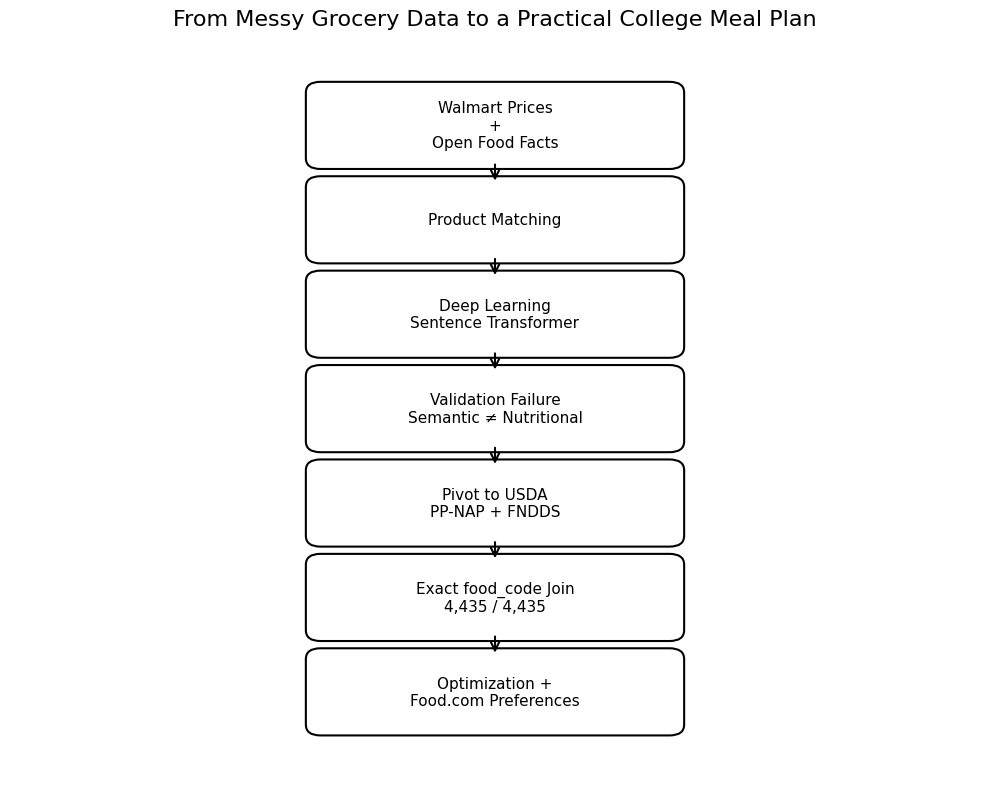

In [233]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis("off")

steps = [
    ("Walmart Prices\n+\nOpen Food Facts", 0.5, 0.90),
    ("Product Matching", 0.5, 0.77),
    ("Deep Learning\nSentence Transformer", 0.5, 0.64),
    ("Validation Failure\nSemantic ≠ Nutritional", 0.5, 0.51),
    ("Pivot to USDA\nPP-NAP + FNDDS", 0.5, 0.38),
    ("Exact food_code Join\n4,435 / 4,435", 0.5, 0.25),
    ("Optimization +\nFood.com Preferences", 0.5, 0.12)
]

for text, x, y in steps:
    box = FancyBboxPatch(
        (x - 0.18, y - 0.045),
        0.36,
        0.09,
        boxstyle="round,pad=0.015",
        linewidth=1.5,
        fill=False
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=11)

for i in range(len(steps) - 1):
    x1, y1 = steps[i][1], steps[i][2]
    x2, y2 = steps[i+1][1], steps[i+1][2]

    arrow = FancyArrowPatch(
        (x1, y1 - 0.05),
        (x2, y2 + 0.05),
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5
    )
    ax.add_patch(arrow)

ax.set_title(
    "From Messy Grocery Data to a Practical College Meal Plan",
    fontsize=16,
    pad=20
)

plt.tight_layout()
plt.savefig("project_pipeline.png", dpi=300, bbox_inches="tight")
plt.show()

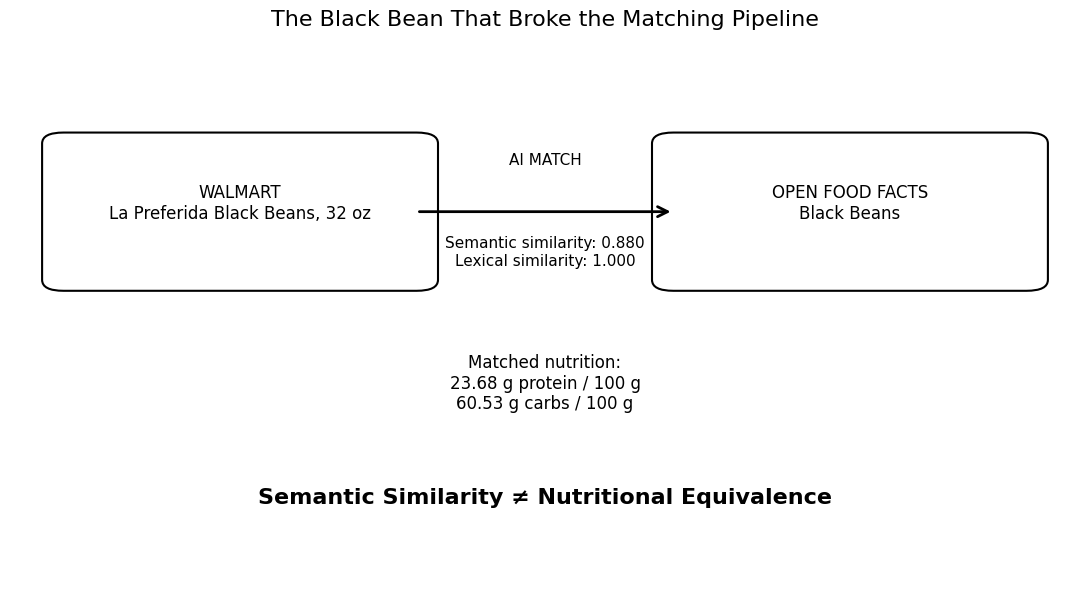

In [234]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")

left = FancyBboxPatch(
    (0.05, 0.55), 0.33, 0.25,
    boxstyle="round,pad=0.02",
    linewidth=1.5,
    fill=False
)

right = FancyBboxPatch(
    (0.62, 0.55), 0.33, 0.25,
    boxstyle="round,pad=0.02",
    linewidth=1.5,
    fill=False
)

ax.add_patch(left)
ax.add_patch(right)

ax.text(
    0.215, 0.69,
    "WALMART\nLa Preferida Black Beans, 32 oz",
    ha="center", va="center", fontsize=12
)

ax.text(
    0.785, 0.69,
    "OPEN FOOD FACTS\nBlack Beans",
    ha="center", va="center", fontsize=12
)

arrow = FancyArrowPatch(
    (0.38, 0.675),
    (0.62, 0.675),
    arrowstyle="->",
    mutation_scale=18,
    linewidth=2
)
ax.add_patch(arrow)

ax.text(
    0.50, 0.76,
    "AI MATCH",
    ha="center",
    fontsize=11
)

ax.text(
    0.50, 0.60,
    "Semantic similarity: 0.880\nLexical similarity: 1.000",
    ha="center",
    va="center",
    fontsize=11
)

ax.text(
    0.50, 0.36,
    "Matched nutrition:\n23.68 g protein / 100 g\n60.53 g carbs / 100 g",
    ha="center",
    va="center",
    fontsize=12
)

ax.text(
    0.50, 0.15,
    "Semantic Similarity ≠ Nutritional Equivalence",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "The Black Bean That Broke the Matching Pipeline",
    fontsize=16
)

plt.tight_layout()
plt.savefig("black_bean_failure.png", dpi=300, bbox_inches="tight")
plt.show()

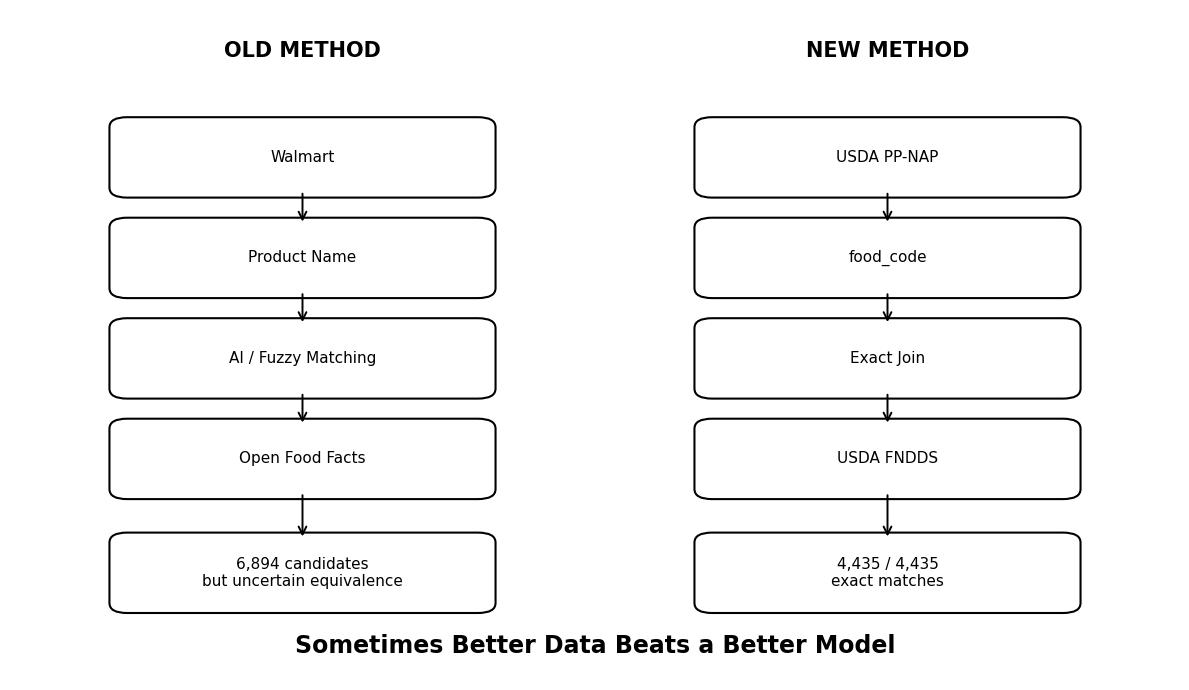

In [235]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

ax.text(0.25, 0.93, "OLD METHOD", ha="center", fontsize=15, fontweight="bold")
ax.text(0.75, 0.93, "NEW METHOD", ha="center", fontsize=15, fontweight="bold")

old_steps = [
    ("Walmart", 0.25, 0.78),
    ("Product Name", 0.25, 0.63),
    ("AI / Fuzzy Matching", 0.25, 0.48),
    ("Open Food Facts", 0.25, 0.33),
    ("6,894 candidates\nbut uncertain equivalence", 0.25, 0.16)
]

new_steps = [
    ("USDA PP-NAP", 0.75, 0.78),
    ("food_code", 0.75, 0.63),
    ("Exact Join", 0.75, 0.48),
    ("USDA FNDDS", 0.75, 0.33),
    ("4,435 / 4,435\nexact matches", 0.75, 0.16)
]

def draw_column(steps):
    for text, x, y in steps:
        box = FancyBboxPatch(
            (x - 0.15, y - 0.045),
            0.30, 0.09,
            boxstyle="round,pad=0.015",
            linewidth=1.5,
            fill=False
        )
        ax.add_patch(box)
        ax.text(x, y, text, ha="center", va="center", fontsize=11)

    for i in range(len(steps) - 1):
        x1, y1 = steps[i][1], steps[i][2]
        x2, y2 = steps[i+1][1], steps[i+1][2]
        ax.add_patch(
            FancyArrowPatch(
                (x1, y1 - 0.05),
                (x2, y2 + 0.05),
                arrowstyle="->",
                mutation_scale=14,
                linewidth=1.4
            )
        )

draw_column(old_steps)
draw_column(new_steps)

ax.text(
    0.5, 0.04,
    "Sometimes Better Data Beats a Better Model",
    ha="center",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("old_vs_usda.png", dpi=300, bbox_inches="tight")
plt.show()

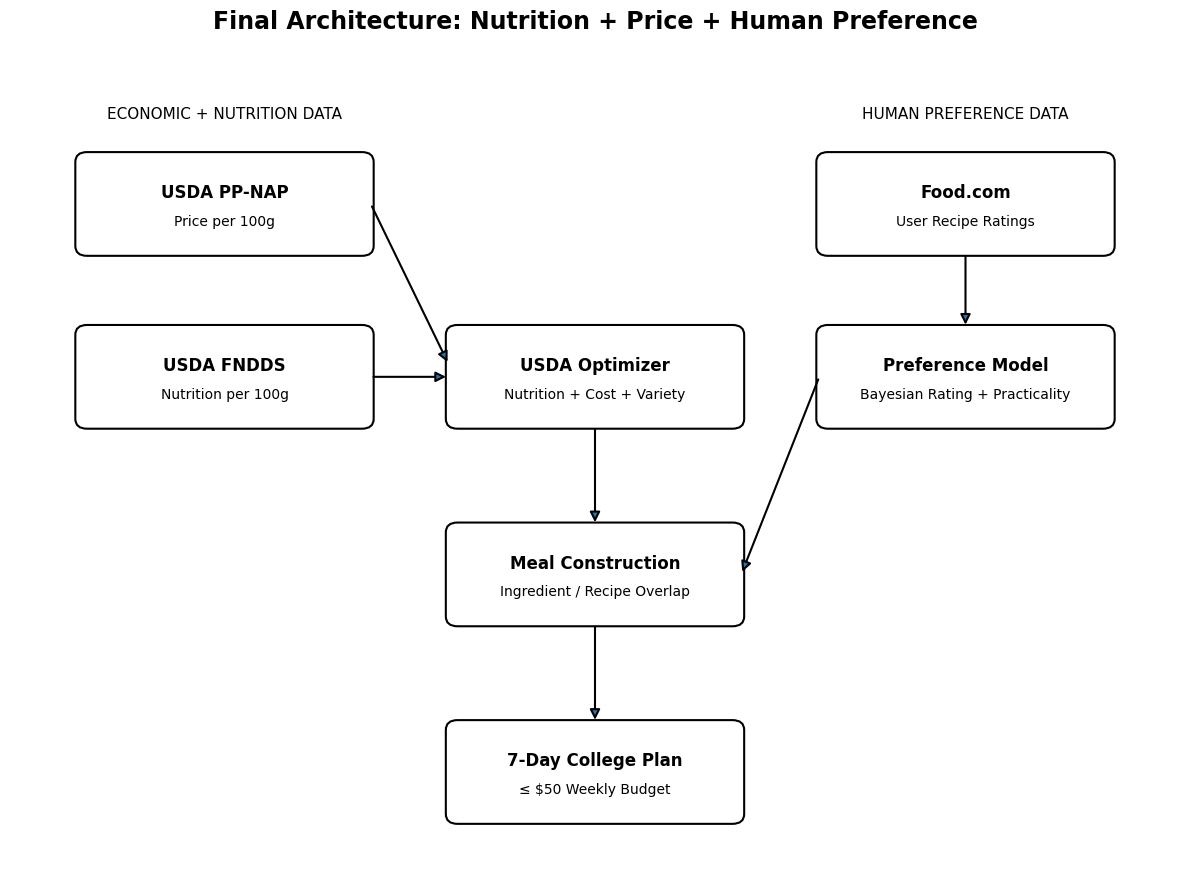

In [237]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 9))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis("off")


# -----------------------------
# Helper functions
# -----------------------------

def draw_box(x, y, w, h, title, subtitle=None):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=1.5,
        fill=False
    )

    ax.add_patch(box)

    if subtitle:
        ax.text(
            x + w/2,
            y + h*0.62,
            title,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

        ax.text(
            x + w/2,
            y + h*0.33,
            subtitle,
            ha="center",
            va="center",
            fontsize=10
        )

    else:
        ax.text(
            x + w/2,
            y + h/2,
            title,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )


def arrow(start, end):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.5,
            connectionstyle="arc3"
        )
    )


# -----------------------------
# Boxes
# -----------------------------

# USDA side
draw_box(
    0.7, 7.6, 3, 1.2,
    "USDA PP-NAP",
    "Price per 100g"
)

draw_box(
    0.7, 5.5, 3, 1.2,
    "USDA FNDDS",
    "Nutrition per 100g"
)


# Food.com side
draw_box(
    8.3, 7.6, 3, 1.2,
    "Food.com",
    "User Recipe Ratings"
)

draw_box(
    8.3, 5.5, 3, 1.2,
    "Preference Model",
    "Bayesian Rating + Practicality"
)


# Center
draw_box(
    4.5, 5.5, 3, 1.2,
    "USDA Optimizer",
    "Nutrition + Cost + Variety"
)

draw_box(
    4.5, 3.1, 3, 1.2,
    "Meal Construction",
    "Ingredient / Recipe Overlap"
)

draw_box(
    4.5, 0.7, 3, 1.2,
    "7-Day College Plan",
    "≤ $50 Weekly Budget"
)


# -----------------------------
# Arrows
# -----------------------------

# USDA price -> optimizer
arrow(
    (3.7, 8.2),
    (4.5, 6.25)
)

# USDA nutrition -> optimizer
arrow(
    (3.7, 6.1),
    (4.5, 6.1)
)

# Food.com -> preference
arrow(
    (9.8, 7.6),
    (9.8, 6.7)
)

# Preference -> meal construction
arrow(
    (8.3, 6.1),
    (7.5, 3.7)
)

# Optimizer -> meal construction
arrow(
    (6.0, 5.5),
    (6.0, 4.3)
)

# Meal construction -> final plan
arrow(
    (6.0, 3.1),
    (6.0, 1.9)
)


# -----------------------------
# Labels
# -----------------------------

ax.text(
    2.2,
    9.25,
    "ECONOMIC + NUTRITION DATA",
    ha="center",
    fontsize=11
)

ax.text(
    9.8,
    9.25,
    "HUMAN PREFERENCE DATA",
    ha="center",
    fontsize=11
)


ax.set_title(
    "Final Architecture: Nutrition + Price + Human Preference",
    fontsize=17,
    fontweight="bold",
    pad=20
)


plt.tight_layout()

plt.savefig(
    "final_architecture_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

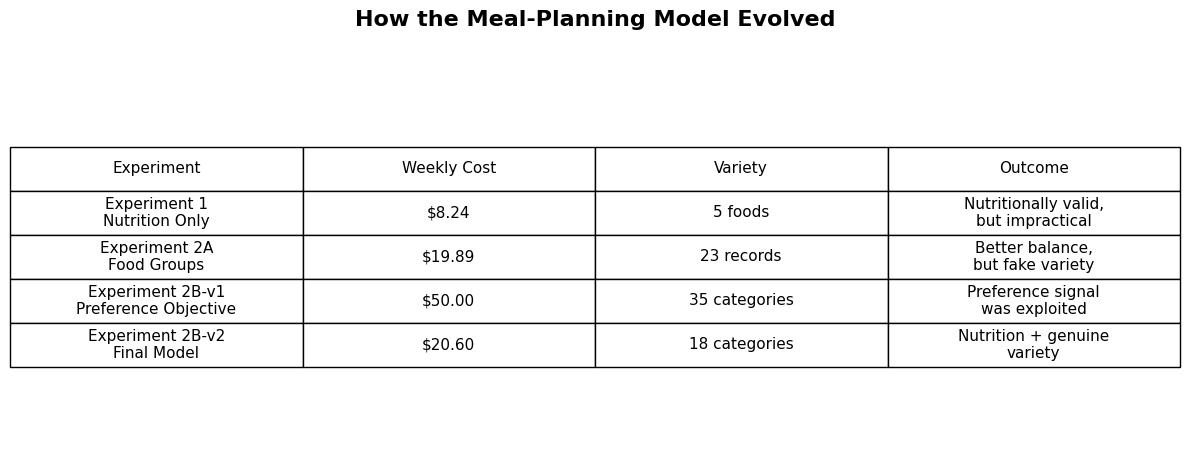

In [238]:
import matplotlib.pyplot as plt
import pandas as pd

results_table = pd.DataFrame({
    "Experiment": [
        "Experiment 1\nNutrition Only",
        "Experiment 2A\nFood Groups",
        "Experiment 2B-v1\nPreference Objective",
        "Experiment 2B-v2\nFinal Model"
    ],
    "Weekly Cost": [
        "$8.24",
        "$19.89",
        "$50.00",
        "$20.60"
    ],
    "Variety": [
        "5 foods",
        "23 records",
        "35 categories",
        "18 categories"
    ],
    "Outcome": [
        "Nutritionally valid,\nbut impractical",
        "Better balance,\nbut fake variety",
        "Preference signal\nwas exploited",
        "Nutrition + genuine\nvariety"
    ]
})

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis("off")

table = ax.table(
    cellText=results_table.values,
    colLabels=results_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.4)

ax.set_title(
    "How the Meal-Planning Model Evolved",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "experiment_results_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

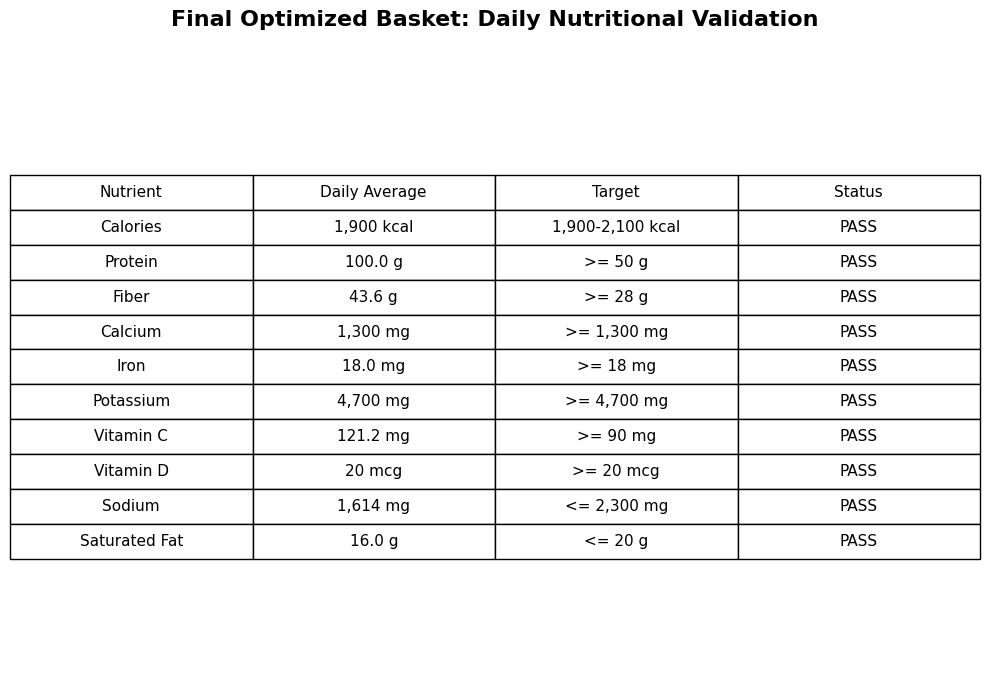

In [239]:
nutrition_results = pd.DataFrame({
    "Nutrient": [
        "Calories",
        "Protein",
        "Fiber",
        "Calcium",
        "Iron",
        "Potassium",
        "Vitamin C",
        "Vitamin D",
        "Sodium",
        "Saturated Fat"
    ],
    "Daily Average": [
        "1,900 kcal",
        "100.0 g",
        "43.6 g",
        "1,300 mg",
        "18.0 mg",
        "4,700 mg",
        "121.2 mg",
        "20 mcg",
        "1,614 mg",
        "16.0 g"
    ],
    "Target": [
        "1,900-2,100 kcal",
        ">= 50 g",
        ">= 28 g",
        ">= 1,300 mg",
        ">= 18 mg",
        ">= 4,700 mg",
        ">= 90 mg",
        ">= 20 mcg",
        "<= 2,300 mg",
        "<= 20 g"
    ],
    "Status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS",
        "PASS"
    ]
})

fig, ax = plt.subplots(figsize=(10, 7))
ax.axis("off")

table = ax.table(
    cellText=nutrition_results.values,
    colLabels=nutrition_results.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

ax.set_title(
    "Final Optimized Basket: Daily Nutritional Validation",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "nutrition_validation_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

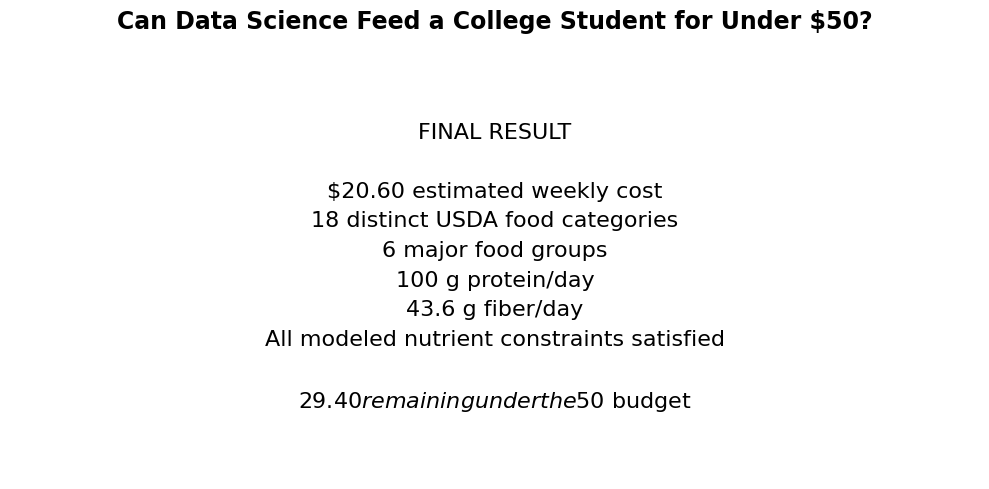

In [240]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

summary_text = (
    "FINAL RESULT\n\n"
    "$20.60 estimated weekly cost\n"
    "18 distinct USDA food categories\n"
    "6 major food groups\n"
    "100 g protein/day\n"
    "43.6 g fiber/day\n"
    "All modeled nutrient constraints satisfied\n\n"
    "$29.40 remaining under the $50 budget"
)

ax.text(
    0.5,
    0.5,
    summary_text,
    ha="center",
    va="center",
    fontsize=16,
    linespacing=1.6
)

ax.set_title(
    "Can Data Science Feed a College Student for Under $50?",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "final_result_card.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [243]:
import pandas as pd
import matplotlib.pyplot as plt

week_plan = pd.DataFrame({
    "Day": [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],

    "Breakfast": [
        "PB + banana\n+ milk",
        "Porridge + banana\n+ milk",
        "PB + banana\n+ milk",
        "Porridge + fruit\n+ milk",
        "PB + banana\n+ milk",
        "Porridge + banana\n+ milk",
        "PB + banana\n+ milk"
    ],

    "Lunch": [
        "Creamy chickpea\ncurry + rice",
        "Leftover chickpea\ncurry + rice",
        "Vegetable fried rice\nwith peas",
        "Leftover vegetable\nfried rice",
        "Peanut-soy\nnoodle bowl",
        "Leftover peanut-soy\nnoodles",
        "Bean curry\n+ rice"
    ],

    "Dinner": [
        "Fish + corn\n+ cabbage",
        "Bean + corn\nbowl",
        "Fish + squash\n+ greens",
        "Bean + corn\ntaco-style bowl",
        "Fish + rice\n+ vegetables",
        "Chickpea curry\n+ rice",
        "Vegetable rice\nbowl + beans"
    ],

    "Snack": [
        "Fruit + peanuts",
        "Yogurt + fruit",
        "Fruit + peanuts",
        "Yogurt + banana",
        "Fruit",
        "Peanuts + fruit",
        "Yogurt + fruit"
    ],

    # Allocated from the $20.60 optimized weekly basket
    "Est. Daily Cost": [
        2.94,
        2.94,
        2.94,
        2.94,
        2.94,
        2.95,
        2.95
    ]
})

week_plan["Est. Daily Cost"] = (
    "$" + week_plan["Est. Daily Cost"].map("{:.2f}".format)
)

week_plan

,Day,Breakfast,Lunch,Dinner,Snack,Est. Daily Cost
0,Monday,PB + banana\n+ milk,Creamy chickpea\ncurry + rice,Fish + corn\n+ cabbage,Fruit + peanuts,$2.94
1,Tuesday,Porridge + banana\n+ milk,Leftover chickpea\ncurry + rice,Bean + corn\nbowl,Yogurt + fruit,$2.94
2,Wednesday,PB + banana\n+ milk,Vegetable fried rice\nwith peas,Fish + squash\n+ greens,Fruit + peanuts,$2.94
3,Thursday,Porridge + fruit\n+ milk,Leftover vegetable\nfried rice,Bean + corn\ntaco-style bowl,Yogurt + banana,$2.94
4,Friday,PB + banana\n+ milk,Peanut-soy\nnoodle bowl,Fish + rice\n+ vegetables,Fruit,$2.94
5,Saturday,Porridge + banana\n+ milk,Leftover peanut-soy\nnoodles,Chickpea curry\n+ rice,Peanuts + fruit,$2.95
6,Sunday,PB + banana\n+ milk,Bean curry\n+ rice,Vegetable rice\nbowl + beans,Yogurt + fruit,$2.95


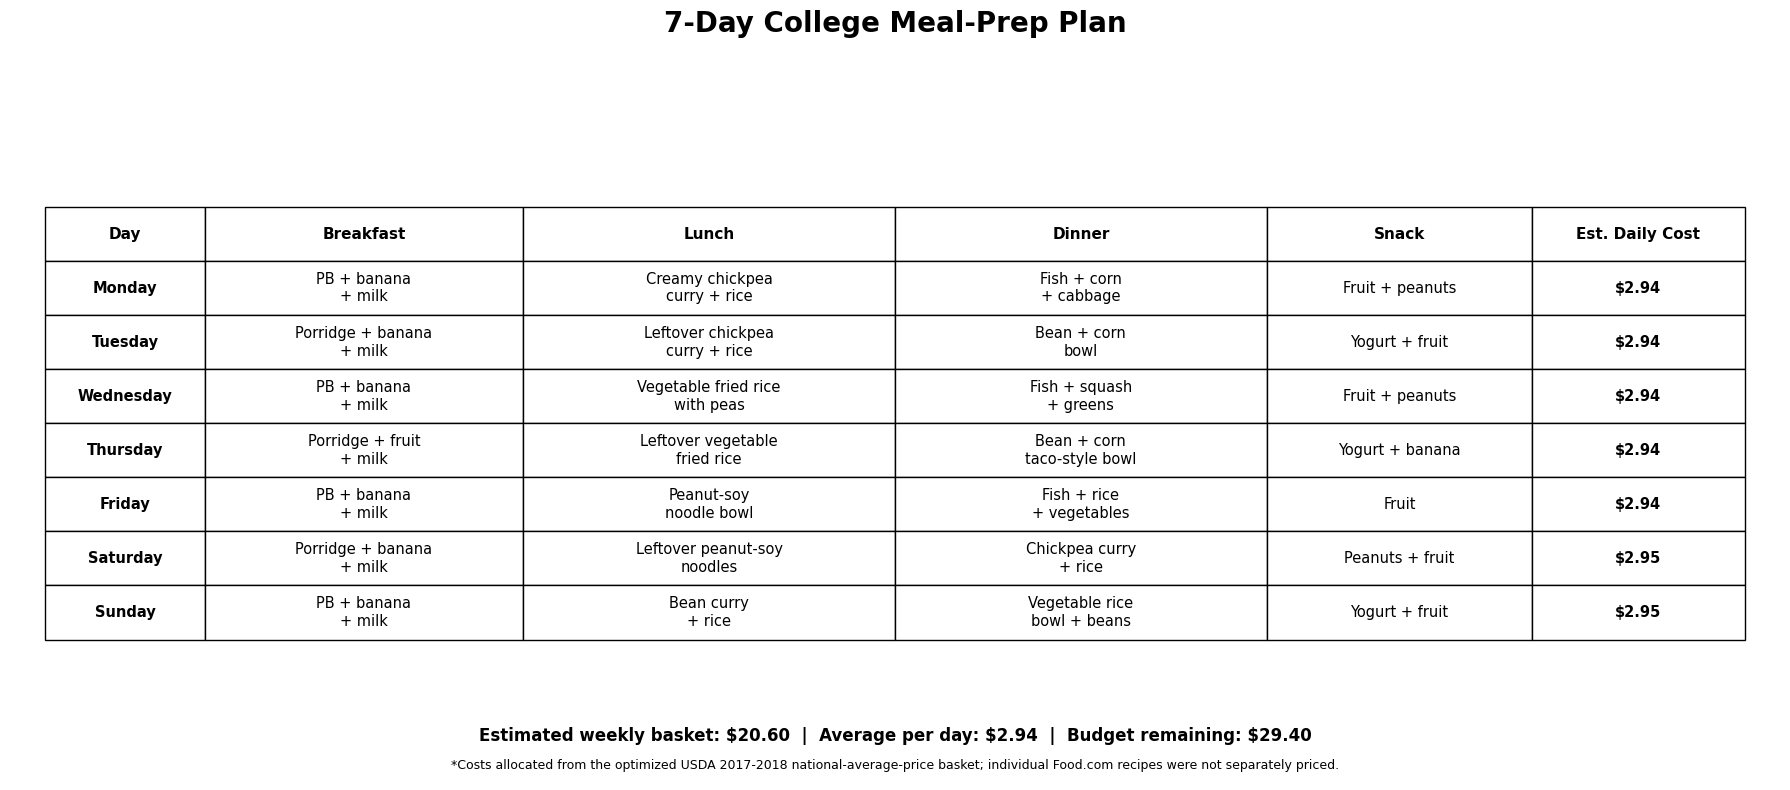

In [244]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.axis("off")

table = ax.table(
    cellText=week_plan.values,
    colLabels=week_plan.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[
        0.09,   # Day
        0.18,   # Breakfast
        0.21,   # Lunch
        0.21,   # Dinner
        0.15,   # Snack
        0.12    # Cost
    ]
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 2.8)

# Bold header
for col in range(len(week_plan.columns)):
    table[(0, col)].set_text_props(
        weight="bold",
        fontsize=11
    )

# Bold day names and daily cost
for row in range(1, len(week_plan) + 1):
    table[(row, 0)].set_text_props(weight="bold")
    table[(row, 5)].set_text_props(weight="bold")

ax.set_title(
    "7-Day College Meal-Prep Plan",
    fontsize=20,
    fontweight="bold",
    pad=25
)

# Results summary
ax.text(
    0.5,
    0.055,
    "Estimated weekly basket: $20.60  |  "
    "Average per day: $2.94  |  "
    "Budget remaining: $29.40",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    0.5,
    0.015,
    "*Costs allocated from the optimized USDA 2017-2018 "
    "national-average-price basket; individual Food.com recipes "
    "were not separately priced.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "7_day_college_meal_plan_with_cost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()